# Exploring the data from round 3

#### Load the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

In [2]:
# Load Round 3 data
prices_0 = pd.read_csv("../data/ROUND3/prices_round_3_day_0.csv", sep=";")
prices_1 = pd.read_csv("../data/ROUND3/prices_round_3_day_1.csv", sep=";")
prices_2 = pd.read_csv("../data/ROUND3/prices_round_3_day_2.csv", sep=";")

trades_0 = pd.read_csv("../data/ROUND3/trades_round_3_day_0.csv", sep=";")
trades_1 = pd.read_csv("../data/ROUND3/trades_round_3_day_1.csv", sep=";")
trades_2 = pd.read_csv("../data/ROUND3/trades_round_3_day_2.csv", sep=";")

## Data sanity + market structure

In [3]:
prices = pd.concat(
    [
        prices_0.assign(day=0),
        prices_1.assign(day=1),
        prices_2.assign(day=2),
    ],
    ignore_index=True,
)

trades = pd.concat(
    [
        trades_0.assign(day=0),
        trades_1.assign(day=1),
        trades_2.assign(day=2),
    ],
    ignore_index=True,
)

print("Prices shape:", prices.shape)
print("Trades shape:", trades.shape)

print("\nPrice columns:")
print(prices.columns.tolist())

print("\nTrade columns:")
print(trades.columns.tolist())

display(prices.head())
display(trades.head())

Prices shape: (360000, 17)
Trades shape: (4048, 8)

Price columns:
['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1', 'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3', 'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2', 'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss']

Trade columns:
['timestamp', 'buyer', 'seller', 'symbol', 'currency', 'price', 'quantity', 'day']


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,0,VEV_5400,22,25,NaN,NaN,NaN,NaN,24,25,NaN,NaN,NaN,NaN,23.0,0.0
1,0,0,VEV_6500,0,16,NaN,NaN,NaN,NaN,1,16,NaN,NaN,NaN,NaN,0.5,0.0
2,0,0,VEV_5500,8,25,NaN,NaN,NaN,NaN,9,25,NaN,NaN,NaN,NaN,8.5,0.0
3,0,0,VEV_5200,100,19,NaN,NaN,NaN,NaN,103,6,104.0,13.0,NaN,NaN,101.5,0.0
4,0,0,VEV_5300,52,6,51.0,19.0,NaN,NaN,54,25,NaN,NaN,NaN,NaN,53.0,0.0


,timestamp,buyer,seller,symbol,currency,price,quantity,day
0,2500,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5250.0,4,0
1,2900,NaN,NaN,VEV_5400,XIRECS,22.0,3,0
2,2900,NaN,NaN,VEV_5500,XIRECS,8.0,3,0
3,2900,NaN,NaN,VEV_6000,XIRECS,0.0,3,0
4,2900,NaN,NaN,VEV_6500,XIRECS,0.0,3,0


In [4]:
print("Products in prices:")
print(sorted(prices["product"].unique()))

print("\nProducts in trades:")
print(sorted(trades["symbol"].unique()))

print("\nRows per product/day in prices:")
display(
    prices.groupby(["day", "product"])
    .size()
    .unstack(fill_value=0)
)

print("\nRows per product/day in trades:")
display(
    trades.groupby(["day", "symbol"])
    .size()
    .unstack(fill_value=0)
)

print("\nTimestamp range by day:")
display(
    prices.groupby("day")["timestamp"]
    .agg(["min", "max", "nunique"])
)

Products in prices:
['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']

Products in trades:
['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']

Rows per product/day in prices:


product,HYDROGEL_PACK,VELVETFRUIT_EXTRACT,VEV_4000,VEV_4500,VEV_5000,VEV_5100,VEV_5200,VEV_5300,VEV_5400,VEV_5500,VEV_6000,VEV_6500
day,,,,,,,,,,,,
0,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000
1,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000
2,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000



Rows per product/day in trades:


symbol,HYDROGEL_PACK,VELVETFRUIT_EXTRACT,VEV_4000,VEV_4500,VEV_5000,VEV_5100,VEV_5200,VEV_5300,VEV_5400,VEV_5500,VEV_6000,VEV_6500
day,,,,,,,,,,,,
0,324,445,172,0,0,0,3,37,64,81,91,91
1,375,450,164,1,1,1,7,39,81,92,98,98
2,311,477,128,0,0,0,8,45,80,94,95,95



Timestamp range by day:


,min,max,nunique
day,,,
0,0,999900,10000
1,0,999900,10000
2,0,999900,10000


In [5]:
print("Missing values in prices:")
display(prices.isna().sum().sort_values(ascending=False))

print("\nMissing values in trades:")
display(trades.isna().sum().sort_values(ascending=False))

price_dupes = prices.duplicated(subset=["day", "timestamp", "product"]).sum()
trade_dupes = trades.duplicated().sum()

print(f"\nDuplicate price rows by day/timestamp/product: {price_dupes}")
print(f"Fully duplicate trade rows: {trade_dupes}")

Missing values in prices:


bid_price_3        358056
bid_volume_3       358056
ask_price_3        357980
ask_volume_3       357980
ask_price_2        207972
ask_volume_2       207972
bid_price_2        207786
bid_volume_2       207786
day                     0
timestamp               0
product                 0
bid_price_1             0
bid_volume_1            0
ask_price_1             0
ask_volume_1            0
mid_price               0
profit_and_loss         0
dtype: int64


Missing values in trades:


buyer        4048
seller       4048
timestamp       0
symbol          0
currency        0
price           0
quantity        0
day             0
dtype: int64


Duplicate price rows by day/timestamp/product: 0
Fully duplicate trade rows: 0


In [6]:
bid_price_cols = sorted(
    [c for c in prices.columns if c.startswith("bid_price_")],
    key=lambda x: int(x.split("_")[-1])
)

bid_volume_cols = sorted(
    [c for c in prices.columns if c.startswith("bid_volume_")],
    key=lambda x: int(x.split("_")[-1])
)

ask_price_cols = sorted(
    [c for c in prices.columns if c.startswith("ask_price_")],
    key=lambda x: int(x.split("_")[-1])
)

ask_volume_cols = sorted(
    [c for c in prices.columns if c.startswith("ask_volume_")],
    key=lambda x: int(x.split("_")[-1])
)

print("Bid price cols:", bid_price_cols)
print("Bid volume cols:", bid_volume_cols)
print("Ask price cols:", ask_price_cols)
print("Ask volume cols:", ask_volume_cols)

Bid price cols: ['bid_price_1', 'bid_price_2', 'bid_price_3']
Bid volume cols: ['bid_volume_1', 'bid_volume_2', 'bid_volume_3']
Ask price cols: ['ask_price_1', 'ask_price_2', 'ask_price_3']
Ask volume cols: ['ask_volume_1', 'ask_volume_2', 'ask_volume_3']


In [7]:
prices["best_bid"] = prices[bid_price_cols].max(axis=1)
prices["best_ask"] = prices[ask_price_cols].min(axis=1)

prices["mid"] = (prices["best_bid"] + prices["best_ask"]) / 2
prices["spread"] = prices["best_ask"] - prices["best_bid"]

prices["total_bid_volume"] = prices[bid_volume_cols].abs().sum(axis=1)
prices["total_ask_volume"] = prices[ask_volume_cols].abs().sum(axis=1)
prices["total_book_volume"] = prices["total_bid_volume"] + prices["total_ask_volume"]

prices["book_imbalance"] = (
    (prices["total_bid_volume"] - prices["total_ask_volume"])
    / prices["total_book_volume"].replace(0, np.nan)
)

display(prices[["day", "timestamp", "product", "best_bid", "best_ask", "mid", "spread"]].head())

,day,timestamp,product,best_bid,best_ask,mid,spread
0,0,0,VEV_5400,22.0,24.0,23.0,2.0
1,0,0,VEV_6500,0.0,1.0,0.5,1.0
2,0,0,VEV_5500,8.0,9.0,8.5,1.0
3,0,0,VEV_5200,100.0,103.0,101.5,3.0
4,0,0,VEV_5300,52.0,54.0,53.0,2.0


In [8]:
spread_stats = (
    prices.groupby("product")["spread"]
    .agg(["count", "mean", "median", "min", "max", "std"])
    .sort_values("mean")
)

display(spread_stats)

spread_by_day = (
    prices.groupby(["day", "product"])["spread"]
    .agg(["mean", "median", "min", "max", "std"])
)

display(spread_by_day)

,count,mean,median,min,max,std
product,,,,,,
VEV_6000,30000,1.000000,1.0,1.0,1.0,0.000000
VEV_6500,30000,1.000000,1.0,1.0,1.0,0.000000
VEV_5500,30000,1.149767,1.0,1.0,2.0,0.356849
VEV_5400,30000,1.381433,1.0,1.0,2.0,0.485747
VEV_5300,30000,2.106800,2.0,1.0,3.0,0.390383
VEV_5200,30000,2.888133,3.0,1.0,4.0,0.443199
VEV_5100,30000,4.295833,4.0,1.0,6.0,0.579535
VELVETFRUIT_EXTRACT,30000,4.988133,5.0,1.0,6.0,0.847122
VEV_5000,30000,6.043333,6.0,2.0,7.0,0.646274


mean  median  min   max       std
day product                                                  
0   HYDROGEL_PACK        15.7010    16.0  7.0  17.0  1.512491
    VELVETFRUIT_EXTRACT   4.9935     5.0  1.0   6.0  0.839004
    VEV_4000             20.7654    21.0  9.0  22.0  1.451680
    VEV_4500             15.7842    16.0  7.0  17.0  1.159899
    VEV_5000              6.0018     6.0  2.0   7.0  0.608468
    VEV_5100              4.3198     4.0  1.0   5.0  0.564411
    VEV_5200              2.9260     3.0  1.0   4.0  0.416583
    VEV_5300              2.1606     2.0  1.0   3.0  0.394745
    VEV_5400              1.4297     1.0  1.0   2.0  0.495058
    VEV_5500              1.1807     1.0  1.0   2.0  0.384789
    VEV_6000              1.0000     1.0  1.0   1.0  0.000000
    VEV_6500              1.0000     1.0  1.0   1.0  0.000000
1   HYDROGEL_PACK        15.7264    16.0  7.0  17.0  1.441232
    VELVETFRUIT_EXTRACT   4.9846     5.0  1.0   6.0  0.849844
    VEV_4000             20.7745    21.0  9.0  22.0  1.507474
    VEV_4500             15.8129    16.0  7.0  17.0  1.199682
    VEV_5000              6.0082     6.0  2.0   7.0  0.639667
    VEV_5100              4.2570     4.0  1.0   5.0  0.577741
    VEV_5200              2.8779     3.0  1.0   4.0  0.432447
    VEV_5300              2.1088     2.0  1.0   3.0  0.374134
    VEV_5400              1.3864     1.0  1.0   2.0  0.486948
    VEV_5500              1.1527     1.0  1.0   2.0  0.359716
    VEV_6000              1.0000     1.0  1.0   1.0  0.000000
    VEV_6500              1.0000     1.0  1.0   1.0  0.000000
2   HYDROGEL_PACK        15.7350    16.0  7.0  17.0  1.409388
    VELVETFRUIT_EXTRACT   4.9863     5.0  1.0   6.0  0.852517
    VEV_4000             20.9005    21.0  9.0  22.0  1.481425
    VEV_4500             15.9609    16.0  7.0  17.0  1.199298
    VEV_5000              6.1200     6.0  2.0   7.0  0.681797
    VEV_5100              4.3107     4.0  1.0   6.0  0.594139
    VEV_5200              2.8605     3.0  1.0   4.0  0.475881
    VEV_5300              2.0510     2.0  1.0   3.0  0.394227
    VEV_5400              1.3282     1.0  1.0   2.0  0.469582
    VEV_5500              1.1159     1.0  1.0   2.0  0.320121
    VEV_6000              1.0000     1.0  1.0   1.0  0.000000
    VEV_6500              1.0000     1.0  1.0   1.0  0.000000

,product,spread,count,fraction
0,HYDROGEL_PACK,7.0,275,0.009167
1,HYDROGEL_PACK,8.0,490,0.016333
2,HYDROGEL_PACK,9.0,225,0.007500
3,HYDROGEL_PACK,15.0,798,0.026600
4,HYDROGEL_PACK,16.0,27820,0.927333
5,HYDROGEL_PACK,17.0,392,0.013067
6,VELVETFRUIT_EXTRACT,1.0,178,0.005933
7,VELVETFRUIT_EXTRACT,2.0,1014,0.033800
8,VELVETFRUIT_EXTRACT,3.0,1003,0.033433
9,VELVETFRUIT_EXTRACT,4.0,71,0.002367


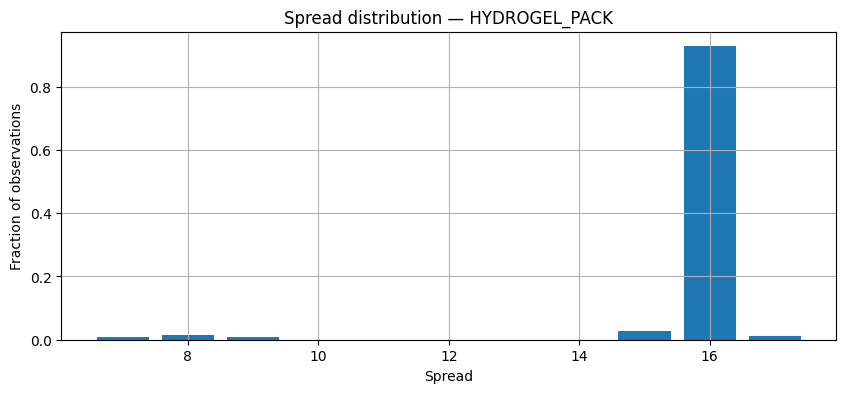

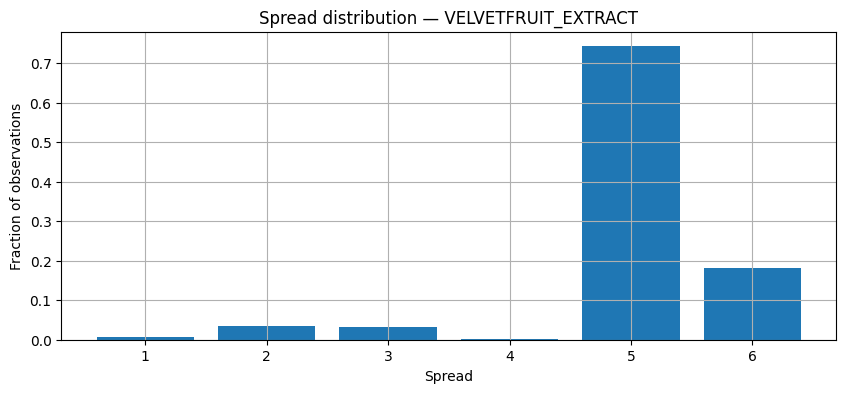

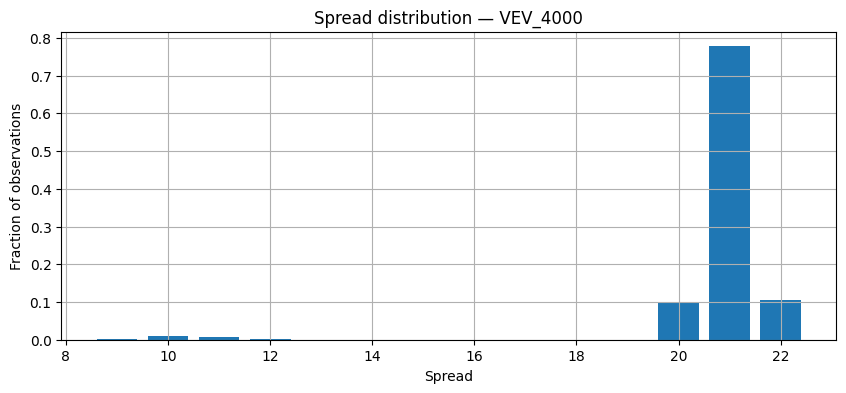

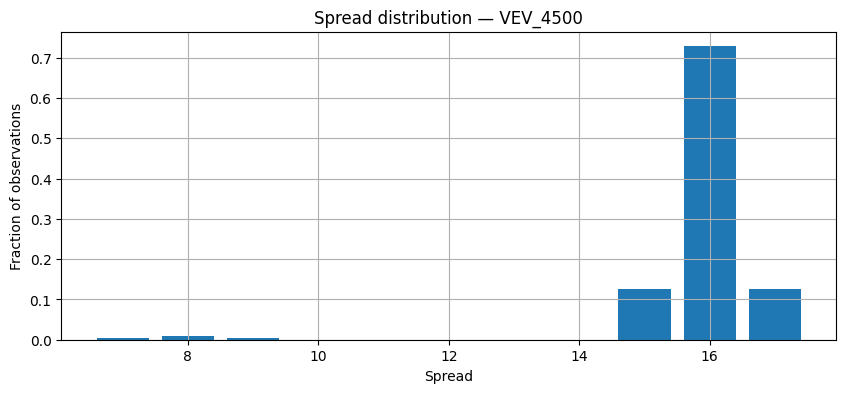

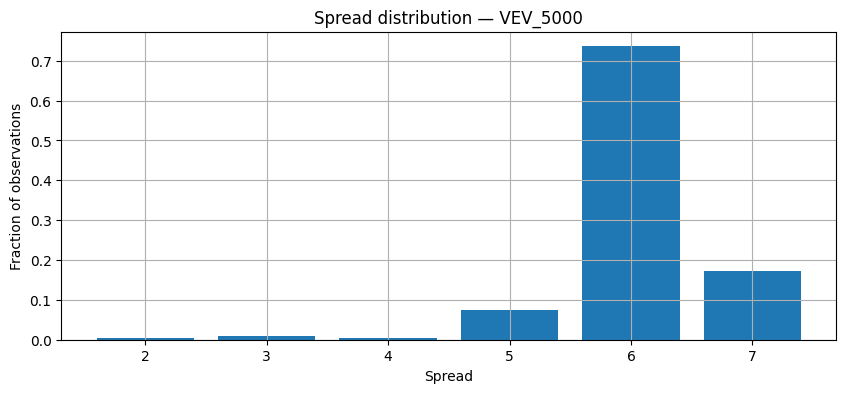

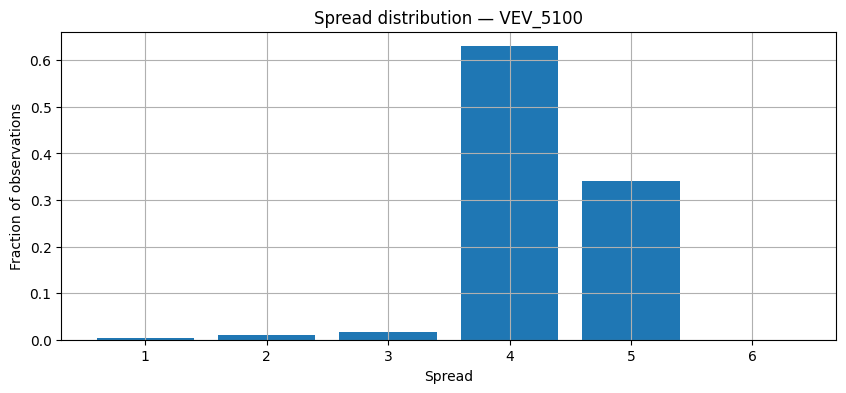

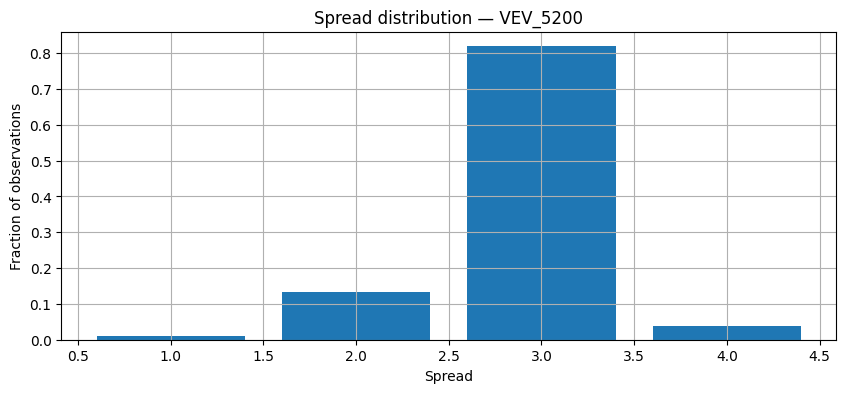

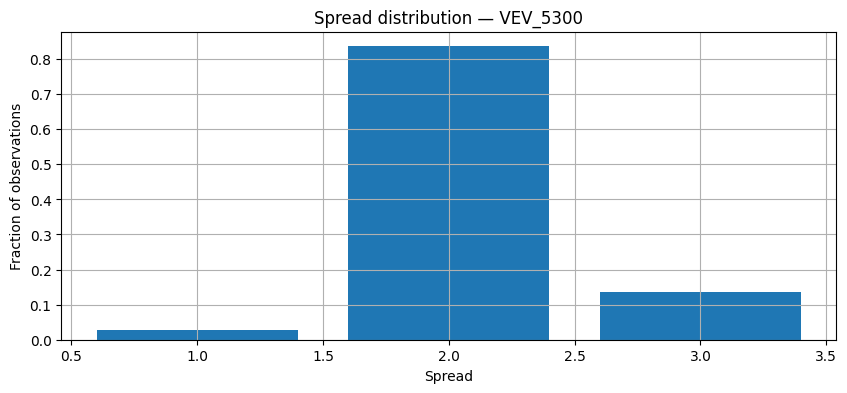

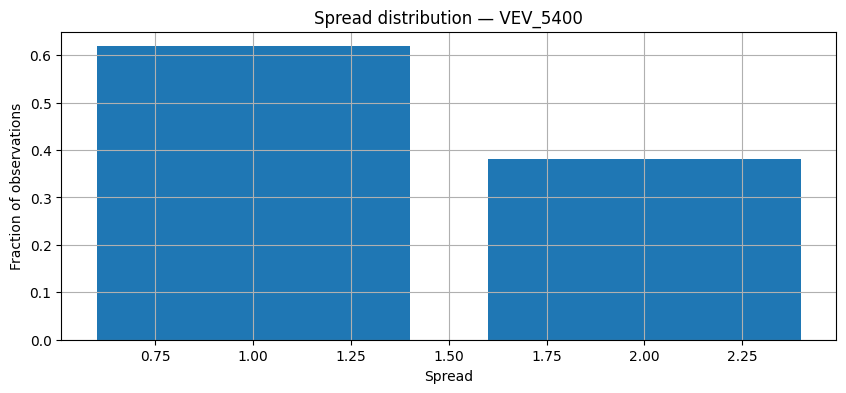

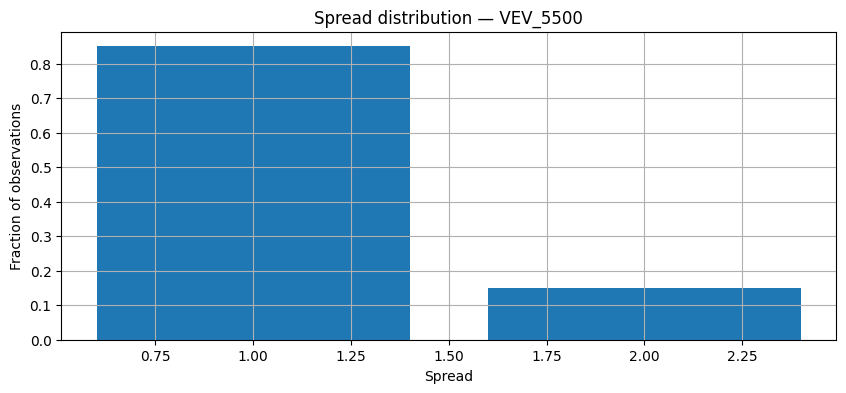

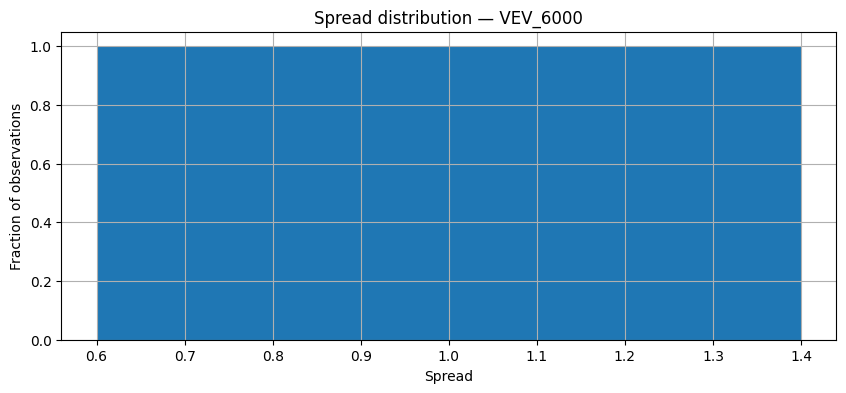

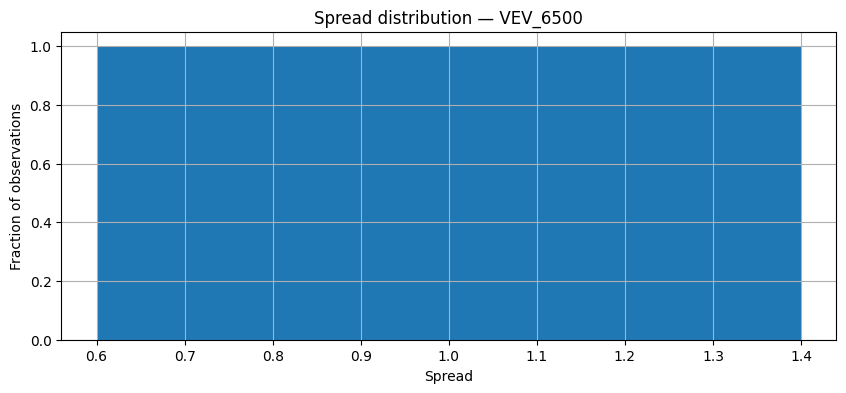

In [18]:
spread_counts = (
    prices.groupby(["product", "spread"])
    .size()
    .reset_index(name="count")
)

spread_counts["fraction"] = spread_counts.groupby("product")["count"].transform(
    lambda x: x / x.sum()
)

display(
    spread_counts.sort_values(["product", "spread"])
)

for product in sorted(prices["product"].unique()):
    df = spread_counts[spread_counts["product"] == product]

    plt.figure(figsize=(10, 4))
    plt.bar(df["spread"], df["fraction"])
    plt.title(f"Spread distribution — {product}")
    plt.xlabel("Spread")
    plt.ylabel("Fraction of observations")
    plt.show()

In [19]:
spread_regime = prices.groupby("product").agg(
    rows=("spread", "count"),
    spread_mean=("spread", "mean"),
    spread_median=("spread", "median"),
    spread_min=("spread", "min"),
    spread_max=("spread", "max"),
    spread_std=("spread", "std"),
    frac_spread_1=("spread", lambda x: (x == 1).mean()),
    frac_spread_le_2=("spread", lambda x: (x <= 2).mean()),
    frac_spread_ge_5=("spread", lambda x: (x >= 5).mean()),
    frac_spread_ge_10=("spread", lambda x: (x >= 10).mean()),
).sort_values("spread_mean")

display(spread_regime)

,rows,spread_mean,spread_median,spread_min,spread_max,spread_std,frac_spread_1,frac_spread_le_2,frac_spread_ge_5,frac_spread_ge_10
product,,,,,,,,,,
VEV_6000,30000,1.000000,1.0,1.0,1.0,0.000000,1.000000,1.000000,0.000000,0.000000
VEV_6500,30000,1.000000,1.0,1.0,1.0,0.000000,1.000000,1.000000,0.000000,0.000000
VEV_5500,30000,1.149767,1.0,1.0,2.0,0.356849,0.850233,1.000000,0.000000,0.000000
VEV_5400,30000,1.381433,1.0,1.0,2.0,0.485747,0.618567,1.000000,0.000000,0.000000
VEV_5300,30000,2.106800,2.0,1.0,3.0,0.390383,0.028500,0.864700,0.000000,0.000000
VEV_5200,30000,2.888133,3.0,1.0,4.0,0.443199,0.009267,0.141867,0.000000,0.000000
VEV_5100,30000,4.295833,4.0,1.0,6.0,0.579535,0.003033,0.012567,0.340833,0.000000
VELVETFRUIT_EXTRACT,30000,4.988133,5.0,1.0,6.0,0.847122,0.005933,0.039733,0.924467,0.000000
VEV_5000,30000,6.043333,6.0,2.0,7.0,0.646274,0.000000,0.004400,0.981700,0.000000


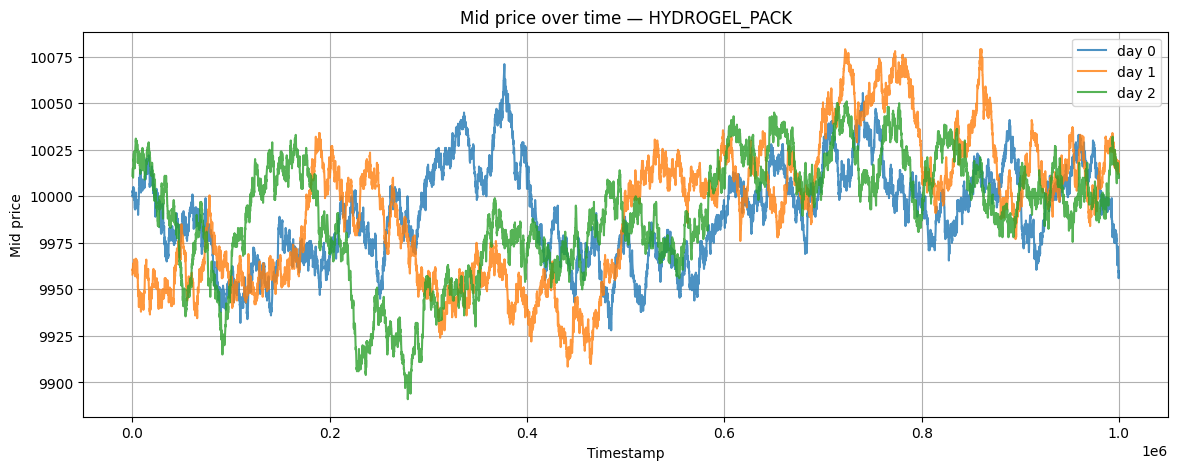

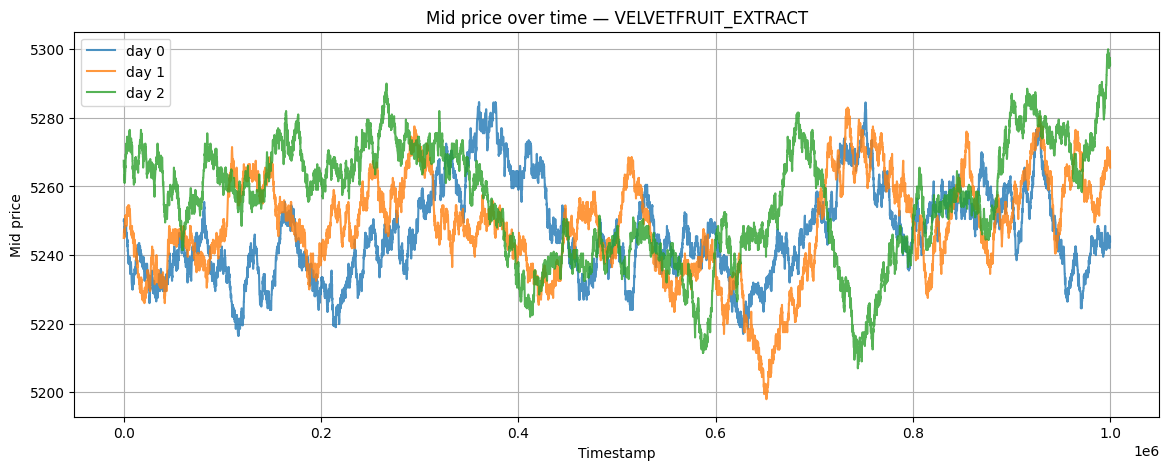

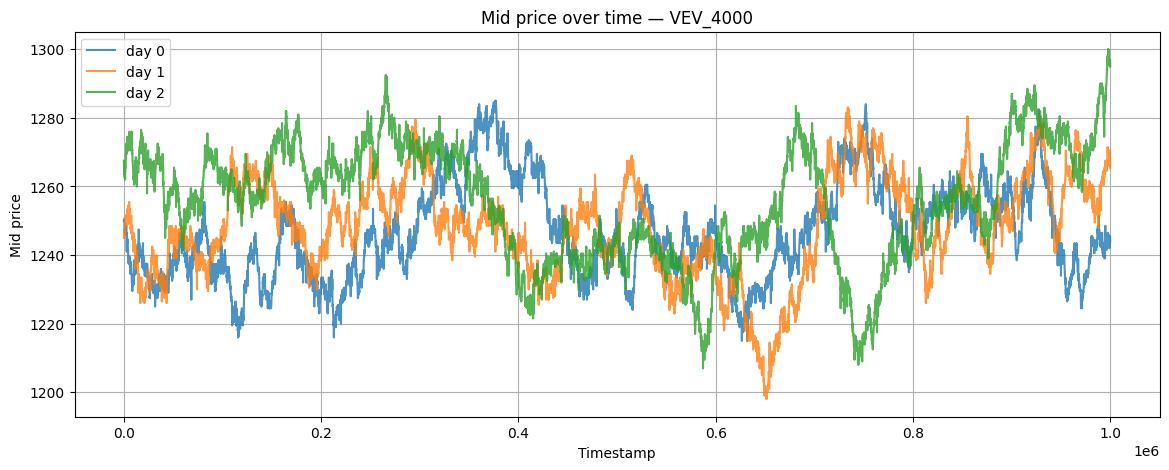

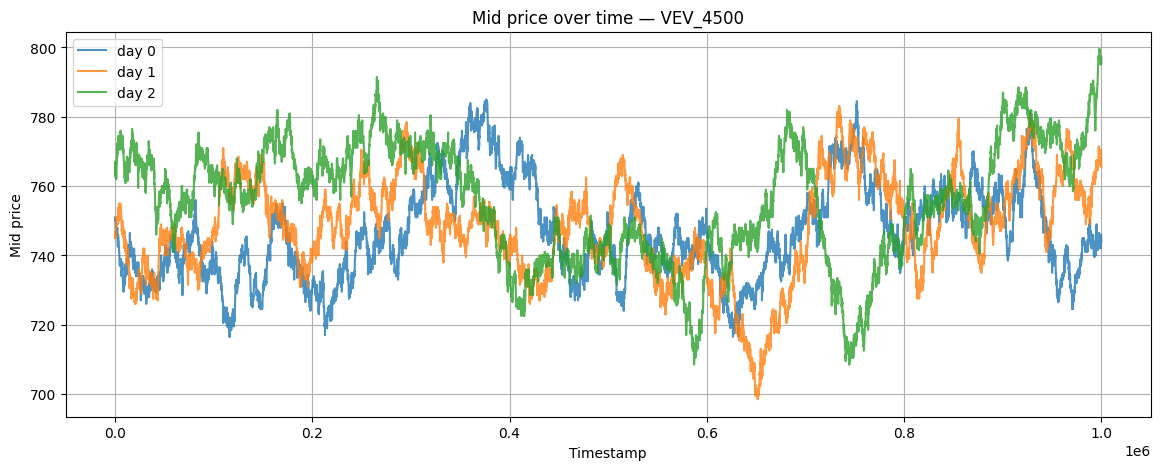

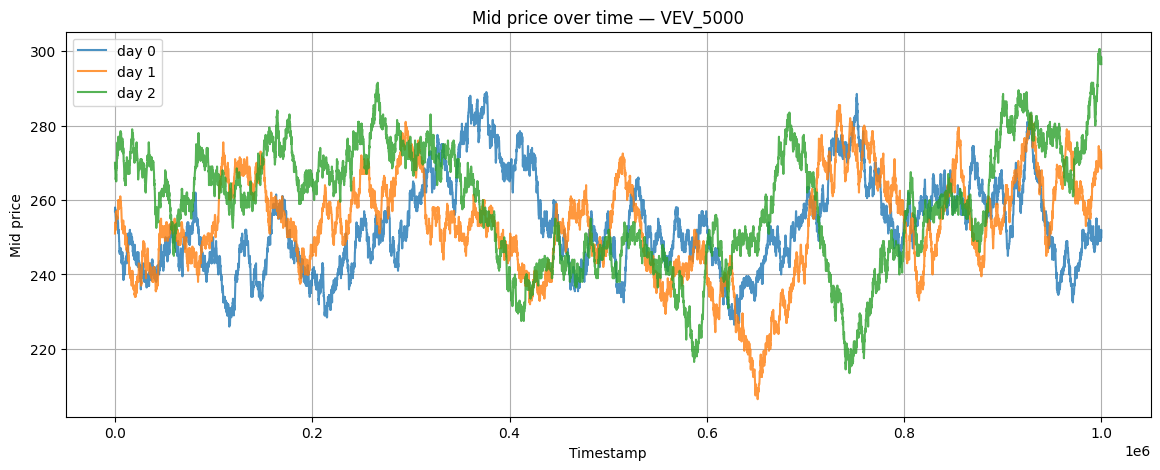

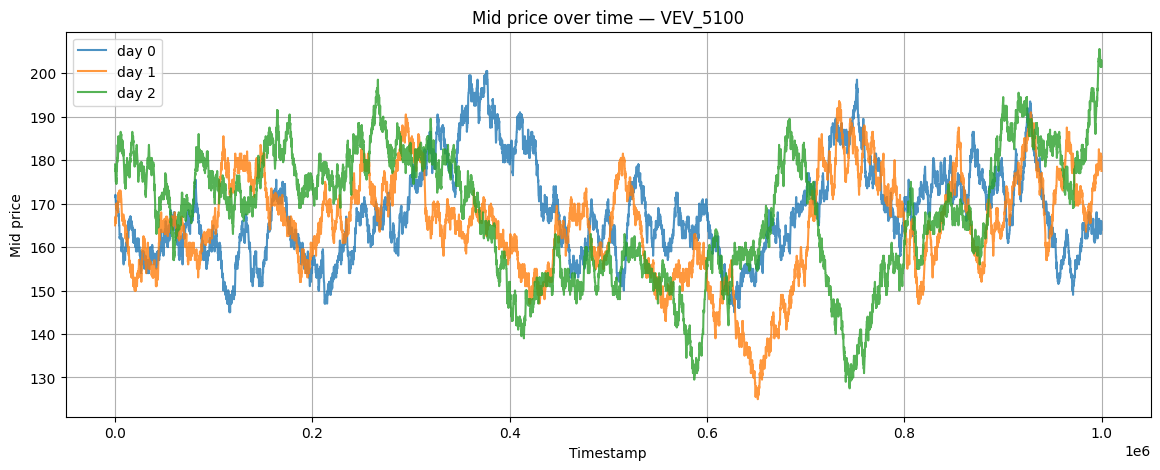

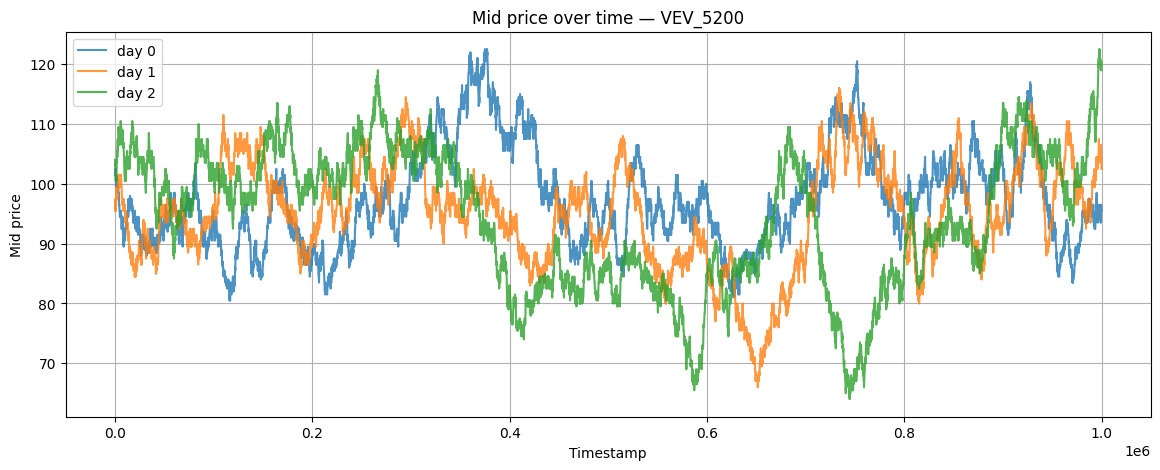

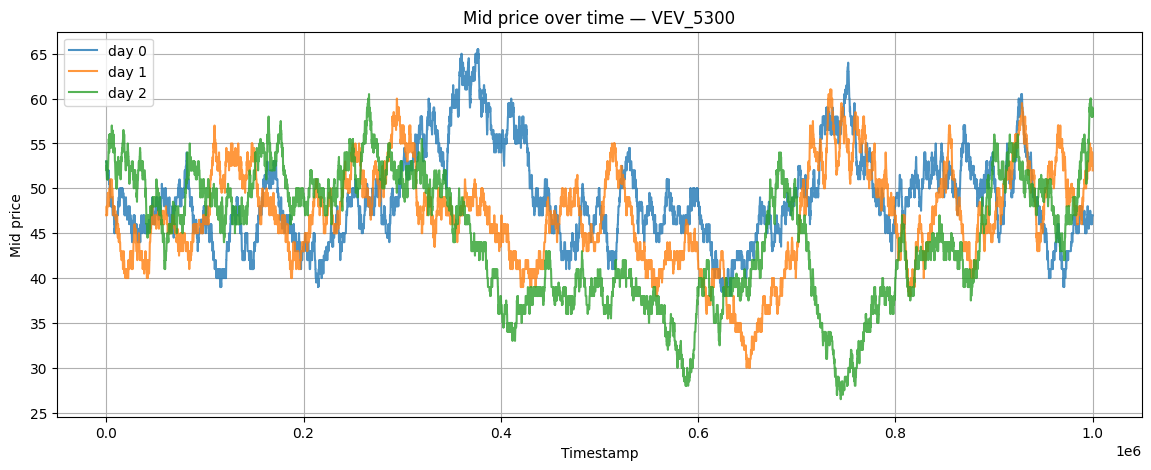

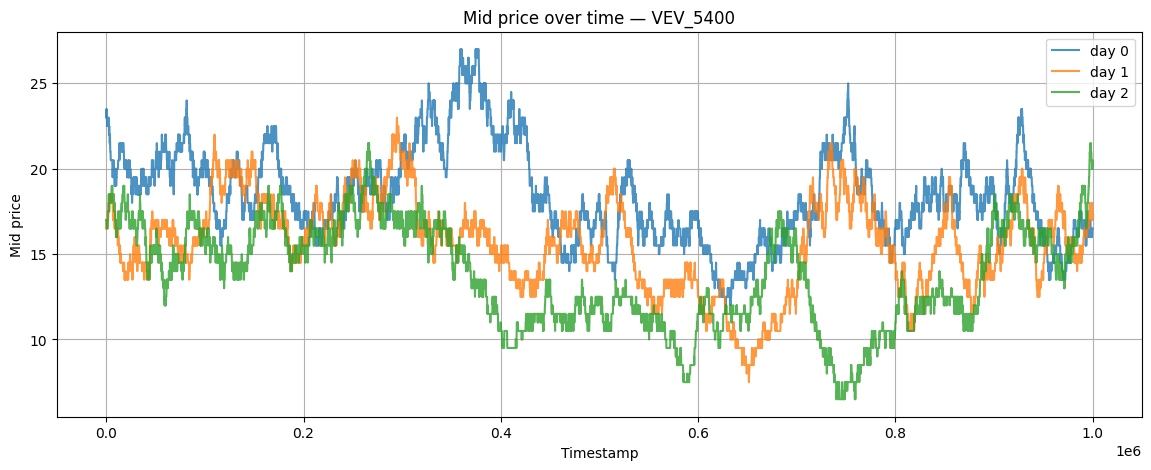

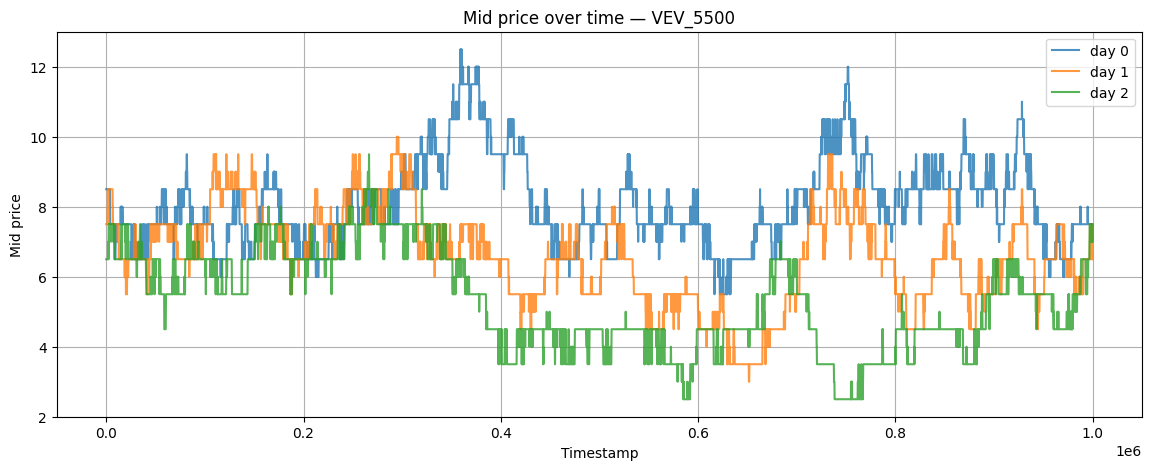

Dead / near-worthless vouchers:


,mid_min,mid_max,mid_mean,spread_mean,best_bid_min,best_bid_max,best_ask_min,best_ask_max
product,,,,,,,,
VEV_6000,0.5,0.5,0.5,1.0,0.0,0.0,1.0,1.0
VEV_6500,0.5,0.5,0.5,1.0,0.0,0.0,1.0,1.0


In [20]:
active_products = [
    "HYDROGEL_PACK",
    "VELVETFRUIT_EXTRACT",
    "VEV_4000",
    "VEV_4500",
    "VEV_5000",
    "VEV_5100",
    "VEV_5200",
    "VEV_5300",
    "VEV_5400",
    "VEV_5500",
]

dead_products = [
    "VEV_6000",
    "VEV_6500",
]

for product in active_products:
    if product not in prices["product"].unique():
        continue

    plt.figure(figsize=(14, 5))

    for day in sorted(prices["day"].unique()):
        df = prices[(prices["product"] == product) & (prices["day"] == day)]
        plt.plot(df["timestamp"], df["mid"], label=f"day {day}", alpha=0.8)

    plt.title(f"Mid price over time — {product}")
    plt.xlabel("Timestamp")
    plt.ylabel("Mid price")
    plt.legend()
    plt.show()

print("Dead / near-worthless vouchers:")
display(
    prices[prices["product"].isin(dead_products)]
    .groupby("product")
    .agg(
        mid_min=("mid", "min"),
        mid_max=("mid", "max"),
        mid_mean=("mid", "mean"),
        spread_mean=("spread", "mean"),
        best_bid_min=("best_bid", "min"),
        best_bid_max=("best_bid", "max"),
        best_ask_min=("best_ask", "min"),
        best_ask_max=("best_ask", "max"),
    )
)

In [24]:
underlying = (
    prices[prices["product"] == "VELVETFRUIT_EXTRACT"]
    [["day", "timestamp", "mid"]]
    .rename(columns={"mid": "underlying_mid"})
)

option_like = prices[prices["product"].str.startswith("VEV_")].merge(
    underlying,
    on=["day", "timestamp"],
    how="left",
)

option_like["strike"] = option_like["product"].str.split("_").str[-1].astype(int)
option_like["moneyness"] = option_like["underlying_mid"] / option_like["strike"]
option_like["intrinsic"] = np.maximum(option_like["underlying_mid"] - option_like["strike"], 0)
option_like["time_value"] = option_like["mid"] - option_like["intrinsic"]

display(option_like.head())

option_structure_summary = option_like.groupby("product").agg(
    strike=("strike", "first"),
    mid_mean=("mid", "mean"),
    mid_min=("mid", "min"),
    mid_max=("mid", "max"),
    intrinsic_mean=("intrinsic", "mean"),
    time_value_mean=("time_value", "mean"),
    time_value_min=("time_value", "min"),
    time_value_max=("time_value", "max"),
    moneyness_mean=("moneyness", "mean"),
).sort_values("strike")

display(option_structure_summary)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,total_ask_volume,total_book_volume,book_imbalance,best_bid_volume,best_ask_volume,underlying_mid,strike,moneyness,intrinsic,time_value
0,0,0,VEV_5400,22,25,NaN,NaN,NaN,NaN,24,...,25.0,50.0,0.0,25.0,25.0,5250.0,5400,0.972222,0.0,23.0
1,0,0,VEV_6500,0,16,NaN,NaN,NaN,NaN,1,...,16.0,32.0,0.0,16.0,16.0,5250.0,6500,0.807692,0.0,0.5
2,0,0,VEV_5500,8,25,NaN,NaN,NaN,NaN,9,...,25.0,50.0,0.0,25.0,25.0,5250.0,5500,0.954545,0.0,8.5
3,0,0,VEV_5200,100,19,NaN,NaN,NaN,NaN,103,...,19.0,38.0,0.0,19.0,6.0,5250.0,5200,1.009615,50.0,51.5
4,0,0,VEV_5300,52,6,51.0,19.0,NaN,NaN,54,...,25.0,50.0,0.0,6.0,25.0,5250.0,5300,0.990566,0.0,53.0


,strike,mid_mean,mid_min,mid_max,intrinsic_mean,time_value_mean,time_value_min,time_value_max,moneyness_mean
product,,,,,,,,,
VEV_4000,4000,1250.109800,1198.0,1300.0,1250.098100,0.011700,-7.0,7.0,1.312525
VEV_4500,4500,750.109567,698.5,799.5,750.098100,0.011467,-6.0,5.5,1.166688
VEV_5000,5000,255.022400,206.5,300.5,250.098100,4.924300,-0.5,11.5,1.050020
VEV_5100,5100,166.805450,125.0,205.5,150.098100,16.707350,4.5,29.5,1.029431
VEV_5200,5200,95.548767,64.0,122.5,50.098383,45.450383,21.5,67.5,1.009634
VEV_5300,5300,46.759933,26.5,65.5,0.000000,46.759933,26.5,65.5,0.990585
VEV_5400,5400,15.951917,6.5,27.0,0.000000,15.951917,6.5,27.0,0.972240
VEV_5500,5500,6.641350,2.5,12.5,0.000000,6.641350,2.5,12.5,0.954563
VEV_6000,6000,0.500000,0.5,0.5,0.000000,0.500000,0.5,0.5,0.875016


In [25]:
option_corrs = []

for product, df in option_like.groupby("product"):
    corr = df[["mid", "underlying_mid"]].corr().iloc[0, 1]
    beta = np.polyfit(df["underlying_mid"], df["mid"], 1)[0]

    option_corrs.append({
        "product": product,
        "strike": df["strike"].iloc[0],
        "corr_with_underlying": corr,
        "linear_beta_to_underlying": beta,
        "mid_mean": df["mid"].mean(),
        "mid_std": df["mid"].std(),
    })

option_corrs = pd.DataFrame(option_corrs).sort_values("strike")
display(option_corrs)

,product,strike,corr_with_underlying,linear_beta_to_underlying,mid_mean,mid_std
0,VEV_4000,4000,0.998597,9.996718e-01,1250.109800,15.647243
1,VEV_4500,4500,0.998822,9.994302e-01,750.109567,15.639930
2,VEV_5000,5000,0.995217,9.153195e-01,255.022400,14.375586
3,VEV_5100,5100,0.962068,7.843212e-01,166.805450,12.742624
4,VEV_5200,5200,0.913988,5.651147e-01,95.548767,9.664218
5,VEV_5300,5300,0.837224,3.336026e-01,46.759933,6.228141
6,VEV_5400,5400,0.573168,1.257482e-01,15.951917,3.429182
7,VEV_5500,5500,0.493266,5.487480e-02,6.641350,1.738849
8,VEV_6000,6000,NaN,5.590461e-19,0.500000,0.000000
9,VEV_6500,6500,NaN,5.590461e-19,0.500000,0.000000


In [11]:
prices["best_bid_volume"] = np.nan
prices["best_ask_volume"] = np.nan

for i in range(1, len(bid_price_cols) + 1):
    bp = f"bid_price_{i}"
    bv = f"bid_volume_{i}"
    ap = f"ask_price_{i}"
    av = f"ask_volume_{i}"

    prices.loc[prices[bp] == prices["best_bid"], "best_bid_volume"] = prices[bv].abs()
    prices.loc[prices[ap] == prices["best_ask"], "best_ask_volume"] = prices[av].abs()

liquidity_stats = prices.groupby("product")[
    ["best_bid_volume", "best_ask_volume", "total_bid_volume", "total_ask_volume", "total_book_volume"]
].agg(["mean", "median", "min", "max", "std"])

display(liquidity_stats)

best_bid_volume                                \
                               mean median   min   max        std   
product                                                             
HYDROGEL_PACK             12.404233   12.0   4.0  15.0   1.838389   
VELVETFRUIT_EXTRACT       37.825300   25.0   1.0  75.0  21.016731   
VEV_4000                  10.921533   11.0   2.0  15.0   2.667136   
VEV_4500                   8.951033    9.0   2.0  12.0   2.054680   
VEV_5000                  15.326100   11.0   2.0  36.0   9.125963   
VEV_5100                  19.248367   22.0   2.0  36.0   9.656051   
VEV_5200                  22.563433   25.0   1.0  36.0   8.717127   
VEV_5300                  20.283800   22.0   1.0  34.0   6.321191   
VEV_5400                  21.763033   22.0   1.0  35.0   4.799866   
VEV_5500                  22.178067   22.0   2.0  35.0   4.170157   
VEV_6000                  22.476167   22.0  10.0  35.0   3.619217   
VEV_6500                  15.479433   15.0   5.0  26.0   2.731073   

                    best_ask_volume                                ...  \
                               mean median   min   max        std  ...   
product                                                            ...   
HYDROGEL_PACK             12.395033   12.0   4.0  15.0   1.854822  ...   
VELVETFRUIT_EXTRACT       37.801133   25.0   1.0  75.0  21.054918  ...   
VEV_4000                  10.919900   11.0   2.0  15.0   2.670766  ...   
VEV_4500                   8.948767    9.0   2.0  12.0   2.057251  ...   
VEV_5000                  15.484267   11.0   2.0  36.0   9.223574  ...   
VEV_5100                  19.347933   22.0   2.0  36.0   9.628030  ...   
VEV_5200                  22.508733   25.0   2.0  36.0   8.756039  ...   
VEV_5300                  20.242867   22.0   2.0  30.0   6.341968  ...   
VEV_5400                  21.719133   22.0   2.0  30.0   4.826892  ...   
VEV_5500                  22.171667   22.0   2.0  30.0   4.152177  ...   
VEV_6000                  22.478867   22.0  15.0  30.0   3.587513  ...   
VEV_6500                  15.482133   15.0  10.0  21.0   2.687673  ...   

                    total_ask_volume                               \
                                mean median   min   max       std   
product                                                             
HYDROGEL_PACK              37.635933   38.0  30.0  55.0  3.701609   
VELVETFRUIT_EXTRACT        60.367100   60.0  42.0  91.0  7.008731   
VEV_4000                   33.518067   33.0  22.0  50.0  5.305212   
VEV_4500                   27.013967   27.0  18.0  41.0  4.270181   
VEV_5000                   27.013967   27.0  18.0  41.0  4.270181   
VEV_5100                   27.013967   27.0  18.0  41.0  4.270181   
VEV_5200                   27.011900   27.0  18.0  41.0  4.270179   
VEV_5300                   22.498300   22.0  15.0  35.0  3.597077   
VEV_5400                   22.486033   22.0  15.0  35.0  3.592033   
VEV_5500                   22.481033   22.0  15.0  33.0  3.589457   
VEV_6000                   22.478867   22.0  15.0  30.0  3.587513   
VEV_6500                   15.482133   15.0  10.0  21.0  2.687673   

                    total_book_volume                                 
                                 mean median   min    max        std  
product                                                               
HYDROGEL_PACK               75.263667   76.0  60.0  100.0   7.270253  
VELVETFRUIT_EXTRACT        120.732267  120.0  90.0  167.0  13.800841  
VEV_4000                    67.033433   66.0  44.0   95.0  10.595049  
VEV_4500                    54.025233   54.0  36.0   77.0   8.525633  
VEV_5000                    54.025233   54.0  36.0   77.0   8.525633  
VEV_5100                    54.025233   54.0  36.0   77.0   8.525633  
VEV_5200                    54.021100   54.0  33.0   77.0   8.527599  
VEV_5300                    44.993900   44.0  25.0   65.0   7.187377  
VEV_5400                    44.969367   44.0  25.0   65.

,imbalance_mean,imbalance_median,imbalance_std,imbalance_min,imbalance_max,frac_exact_zero,frac_abs_gt_001,frac_abs_gt_005,frac_abs_gt_010
product,,,,,,,,,
VELVETFRUIT_EXTRACT,-0.000028,0.0,0.019914,-0.181818,0.222222,0.924467,0.075433,0.059933,0.007533
VEV_6500,-0.000360,0.0,0.017454,-0.333333,0.200000,0.981700,0.018300,0.017667,0.010867
HYDROGEL_PACK,-0.000097,0.0,0.016210,-0.142857,0.142857,0.967000,0.033000,0.030867,0.009900
VEV_6000,-0.000191,0.0,0.011943,-0.200000,0.142857,0.981700,0.018300,0.014533,0.005067
VEV_5500,-0.000183,0.0,0.011869,-0.200000,0.142857,0.981700,0.018300,0.014533,0.004967
VEV_5400,-0.000160,0.0,0.011668,-0.200000,0.142857,0.981700,0.018300,0.014367,0.004700
VEV_5300,-0.000106,0.0,0.011170,-0.200000,0.142857,0.981700,0.018300,0.014267,0.004167
VEV_5200,-0.000057,0.0,0.009022,-0.151515,0.116279,0.981700,0.018300,0.012133,0.000967
VEV_5000,-0.000049,0.0,0.008939,-0.121951,0.116279,0.981700,0.018300,0.012100,0.000833


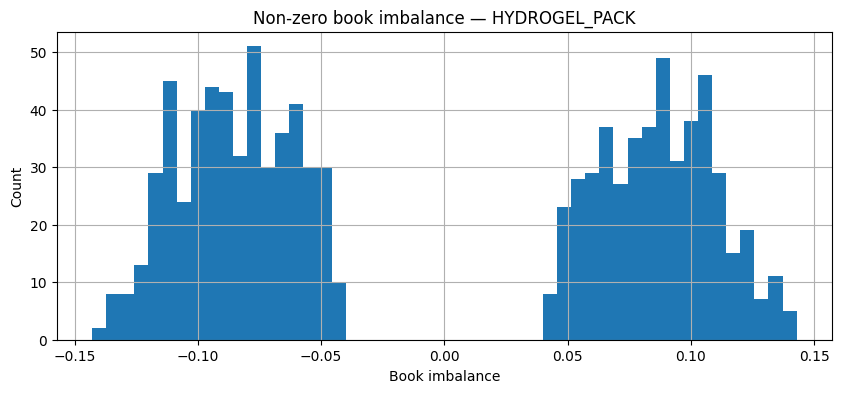

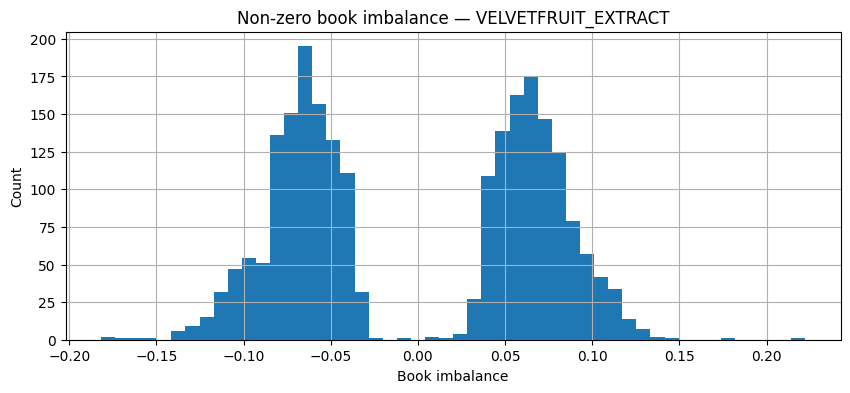

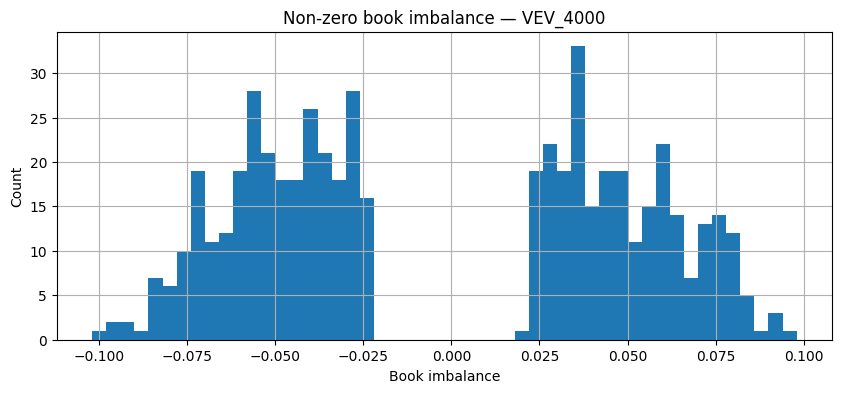

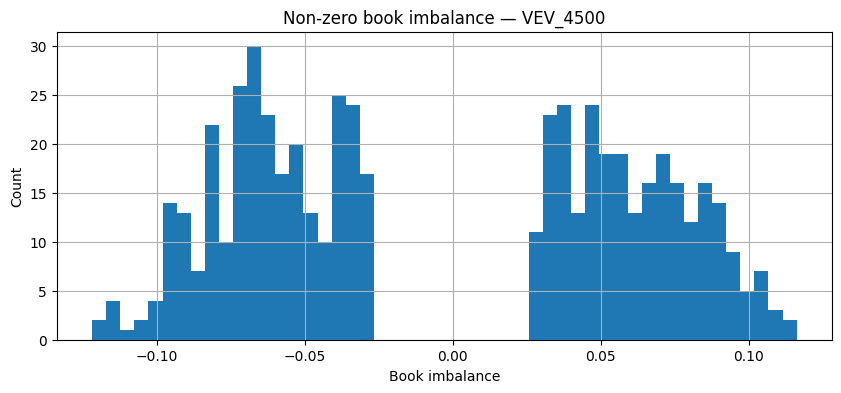

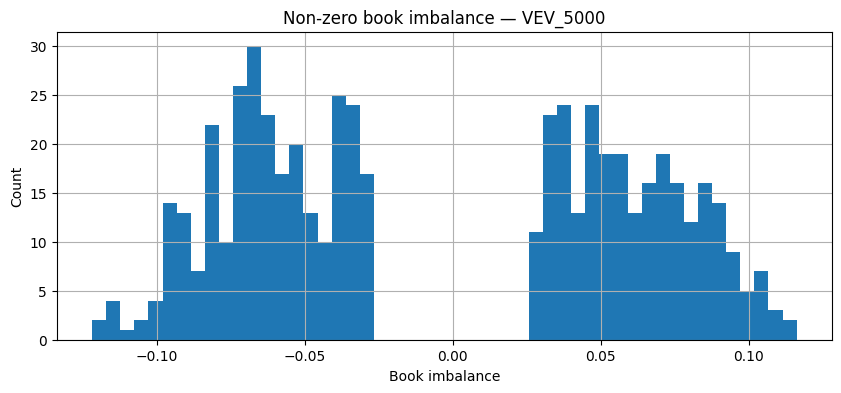

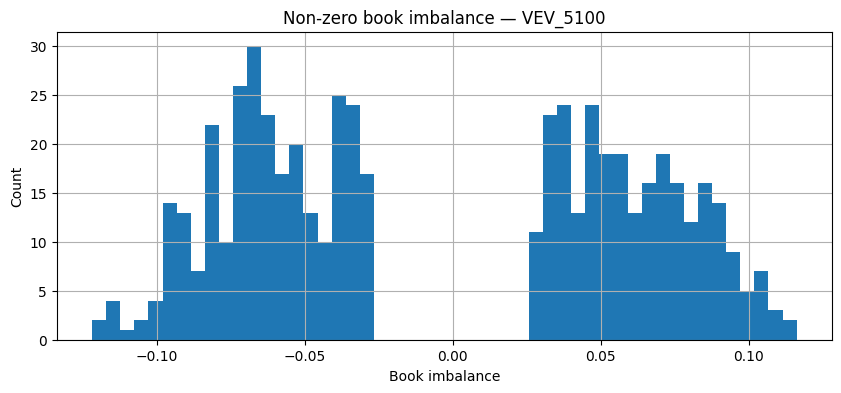

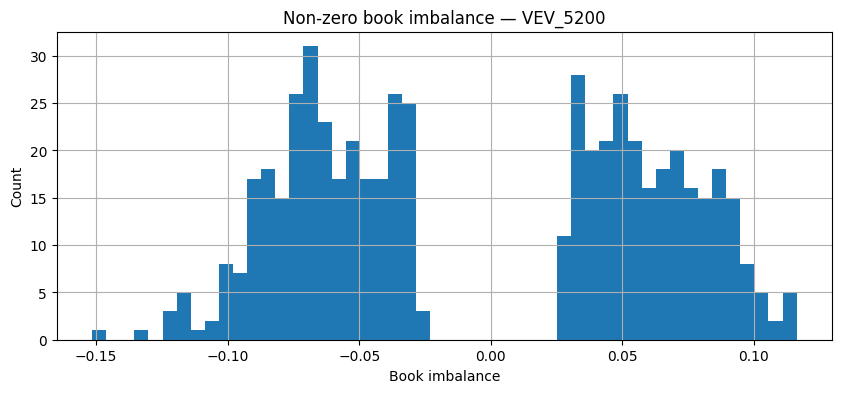

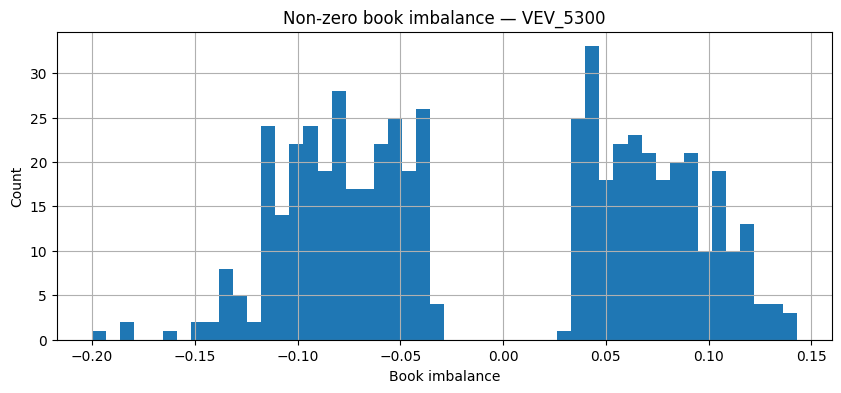

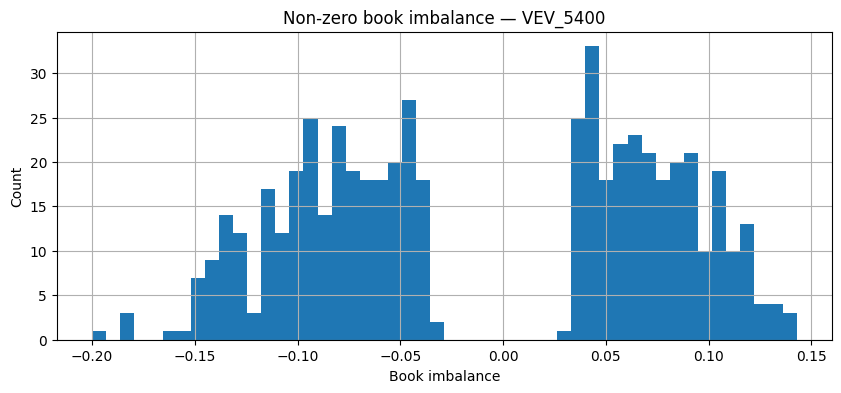

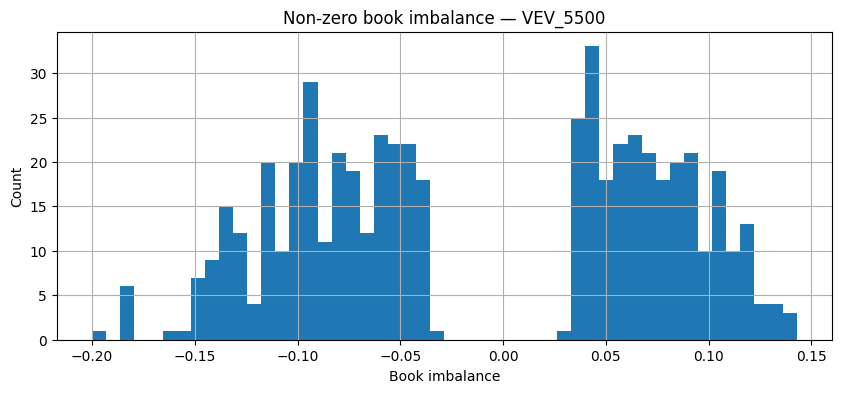

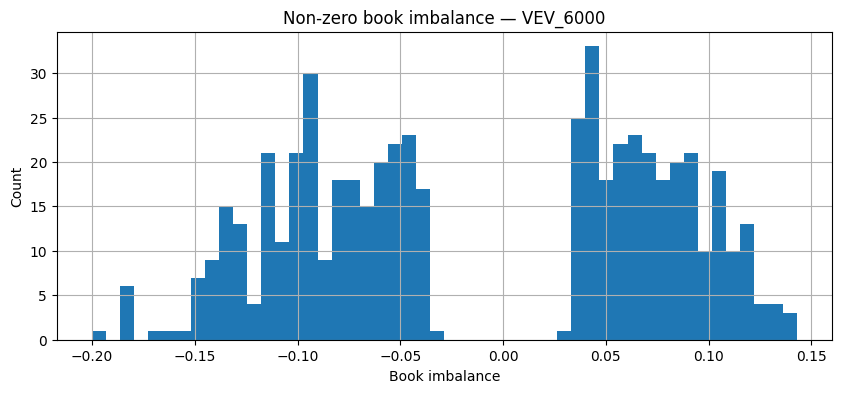

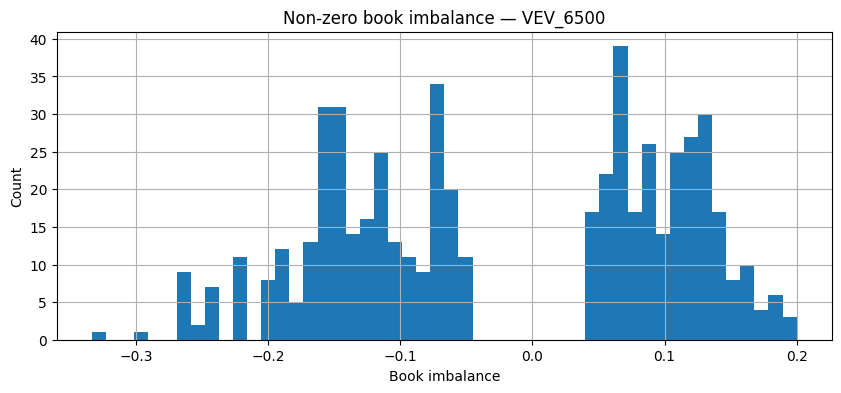

In [ ]:
imbalance_report = prices.groupby("product").agg(
    imbalance_mean=("book_imbalance", "mean"),
    imbalance_median=("book_imbalance", "median"),
    imbalance_std=("book_imbalance", "std"),
    imbalance_min=("book_imbalance", "min"),
    imbalance_max=("book_imbalance", "max"),
    frac_exact_zero=("book_imbalance", lambda x: (x == 0).mean()),
    frac_abs_gt_001=("book_imbalance", lambda x: (x.abs() > 0.01).mean()),
    frac_abs_gt_005=("book_imbalance", lambda x: (x.abs() > 0.05).mean()),
    frac_abs_gt_010=("book_imbalance", lambda x: (x.abs() > 0.10).mean()),
).sort_values("imbalance_std", ascending=False)

display(imbalance_report)

for product in sorted(prices["product"].unique()):
    df = prices[
        (prices["product"] == product)
        & (prices["book_imbalance"].abs() > 0.001)
    ]

    if len(df) < 50:
        print(f"{product}: too few non-zero imbalance points ({len(df)})")
        continue

    plt.figure(figsize=(10, 4))
    plt.hist(df["book_imbalance"], bins=50)
    plt.title(f"Non-zero book imbalance — {product}")
    plt.xlabel("Book imbalance")
    plt.ylabel("Count")
    plt.show()

In [23]:
tmp = prices.sort_values(["product", "day", "timestamp"]).copy()

tmp["next_mid"] = tmp.groupby(["product", "day"])["mid"].shift(-1)
tmp["next_return"] = tmp["next_mid"] - tmp["mid"]

imbalance_predictiveness = tmp.groupby("product").apply(
    lambda df: pd.Series({
        "corr_imbalance_next_return": df[["book_imbalance", "next_return"]].corr().iloc[0, 1],
        "avg_next_return_pos_imb": df.loc[df["book_imbalance"] > 0.01, "next_return"].mean(),
        "avg_next_return_neg_imb": df.loc[df["book_imbalance"] < -0.01, "next_return"].mean(),
        "count_pos_imb": (df["book_imbalance"] > 0.01).sum(),
        "count_neg_imb": (df["book_imbalance"] < -0.01).sum(),
    })
).sort_values("corr_imbalance_next_return", ascending=False)

display(imbalance_predictiveness)

,corr_imbalance_next_return,avg_next_return_pos_imb,avg_next_return_neg_imb,count_pos_imb,count_neg_imb
product,,,,,
VEV_5500,-0.010459,-0.028302,0.017606,265.0,284.0
VEV_5400,-0.036293,-0.088679,0.084507,265.0,284.0
VEV_5300,-0.079946,-0.294340,0.353873,265.0,284.0
VEV_5200,-0.128207,-0.515094,0.878521,265.0,284.0
VEV_5100,-0.161273,-0.839623,1.299296,265.0,284.0
VEV_5000,-0.199075,-1.279245,1.739437,265.0,284.0
VELVETFRUIT_EXTRACT,-0.320854,-1.127660,1.614978,1128.0,1135.0
HYDROGEL_PACK,-0.326800,-3.901899,4.149225,474.0,516.0
VEV_4500,-0.408931,-3.796226,4.202465,265.0,284.0


In [13]:
trade_summary = trades.groupby("symbol").agg(
    num_trades=("price", "count"),
    total_volume=("quantity", lambda x: x.abs().sum()),
    avg_trade_size=("quantity", lambda x: x.abs().mean()),
    median_trade_size=("quantity", lambda x: x.abs().median()),
    min_price=("price", "min"),
    max_price=("price", "max"),
    avg_price=("price", "mean"),
)

display(trade_summary.sort_values("num_trades", ascending=False))

trade_summary_day = trades.groupby(["day", "symbol"]).agg(
    num_trades=("price", "count"),
    total_volume=("quantity", lambda x: x.abs().sum()),
    avg_trade_size=("quantity", lambda x: x.abs().mean()),
)

display(trade_summary_day)

,num_trades,total_volume,avg_trade_size,median_trade_size,min_price,max_price,avg_price
symbol,,,,,,,
VELVETFRUIT_EXTRACT,1372,8269,6.026968,6.0,5198.0,5291.0,5250.476676
HYDROGEL_PACK,1010,4078,4.037624,4.0,9890.0,10086.0,9990.486139
VEV_4000,464,940,2.025862,2.0,1196.0,1307.0,1249.814655
VEV_6000,284,1002,3.528169,4.0,0.0,0.0,0.000000
VEV_6500,284,1002,3.528169,4.0,0.0,0.0,0.000000
VEV_5500,267,937,3.509363,4.0,2.0,10.0,5.951311
VEV_5400,225,787,3.497778,4.0,7.0,22.0,14.884444
VEV_5300,121,420,3.471074,4.0,28.0,58.0,44.157025
VEV_5200,18,63,3.500000,4.0,74.0,98.0,85.277778


num_trades  total_volume  avg_trade_size
day symbol                                                       
0   HYDROGEL_PACK               324          1349        4.163580
    VELVETFRUIT_EXTRACT         445          2689        6.042697
    VEV_4000                    172           351        2.040698
    VEV_5200                      3            15        5.000000
    VEV_5300                     37           128        3.459459
    VEV_5400                     64           218        3.406250
    VEV_5500                     81           281        3.469136
    VEV_6000                     91           320        3.516484
    VEV_6500                     91           320        3.516484
1   HYDROGEL_PACK               375          1485        3.960000
    VELVETFRUIT_EXTRACT         450          2685        5.966667
    VEV_4000                    164           333        2.030488
    VEV_4500                      1             1        1.000000
    VEV_5000                      1             1        1.000000
    VEV_5100                      1             1        1.000000
    VEV_5200                      7            22        3.142857
    VEV_5300                     39           130        3.333333
    VEV_5400                     81           286        3.530864
    VEV_5500                     92           321        3.489130
    VEV_6000                     98           345        3.520408
    VEV_6500                     98           345        3.520408
2   HYDROGEL_PACK               311          1244        4.000000
    VELVETFRUIT_EXTRACT         477          2895        6.069182
    VEV_4000                    128           256        2.000000
    VEV_5200                      8            26        3.250000
    VEV_5300                     45           162        3.600000
    VEV_5400                     80           283        3.537500
    VEV_5500                     94           335        3.563830
    VEV_6000                     95           337        3.547368
    VEV_6500                     95           337        3.547368

In [14]:
trade_mid = trades.merge(
    prices[["day", "timestamp", "product", "mid", "best_bid", "best_ask", "spread"]],
    left_on=["day", "timestamp", "symbol"],
    right_on=["day", "timestamp", "product"],
    how="left",
)

trade_mid["trade_vs_mid"] = trade_mid["price"] - trade_mid["mid"]
trade_mid["inside_book"] = (
    (trade_mid["price"] >= trade_mid["best_bid"])
    & (trade_mid["price"] <= trade_mid["best_ask"])
)

display(trade_mid.head())

trade_mid_summary = trade_mid.groupby("symbol").agg(
    num_trades=("price", "count"),
    matched_mid=("mid", lambda x: x.notna().mean()),
    avg_trade_vs_mid=("trade_vs_mid", "mean"),
    median_trade_vs_mid=("trade_vs_mid", "median"),
    std_trade_vs_mid=("trade_vs_mid", "std"),
    inside_book_frac=("inside_book", "mean"),
)

display(trade_mid_summary.sort_values("num_trades", ascending=False))

,timestamp,buyer,seller,symbol,currency,price,quantity,day,product,mid,best_bid,best_ask,spread,trade_vs_mid,inside_book
0,2500,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5250.0,4,0,VELVETFRUIT_EXTRACT,5247.5,5245.0,5250.0,5.0,2.5,True
1,2900,NaN,NaN,VEV_5400,XIRECS,22.0,3,0,VEV_5400,22.5,22.0,23.0,1.0,-0.5,True
2,2900,NaN,NaN,VEV_5500,XIRECS,8.0,3,0,VEV_5500,8.5,8.0,9.0,1.0,-0.5,True
3,2900,NaN,NaN,VEV_6000,XIRECS,0.0,3,0,VEV_6000,0.5,0.0,1.0,1.0,-0.5,True
4,2900,NaN,NaN,VEV_6500,XIRECS,0.0,3,0,VEV_6500,0.5,0.0,1.0,1.0,-0.5,True


,num_trades,matched_mid,avg_trade_vs_mid,median_trade_vs_mid,std_trade_vs_mid,inside_book_frac
symbol,,,,,,
VELVETFRUIT_EXTRACT,1372,1.0,0.142493,1.0,2.358527,0.995627
HYDROGEL_PACK,1010,1.0,0.254455,4.5,7.899618,1.000000
VEV_4000,464,1.0,-0.304957,-10.0,10.455821,1.000000
VEV_6000,284,1.0,-0.500000,-0.5,0.000000,1.000000
VEV_6500,284,1.0,-0.500000,-0.5,0.000000,1.000000
VEV_5500,267,1.0,-0.546816,-0.5,0.145932,1.000000
VEV_5400,225,1.0,-0.628889,-0.5,0.219193,1.000000
VEV_5300,121,1.0,-0.962810,-1.0,0.184451,1.000000
VEV_5200,18,1.0,-0.916667,-1.0,0.353553,1.000000


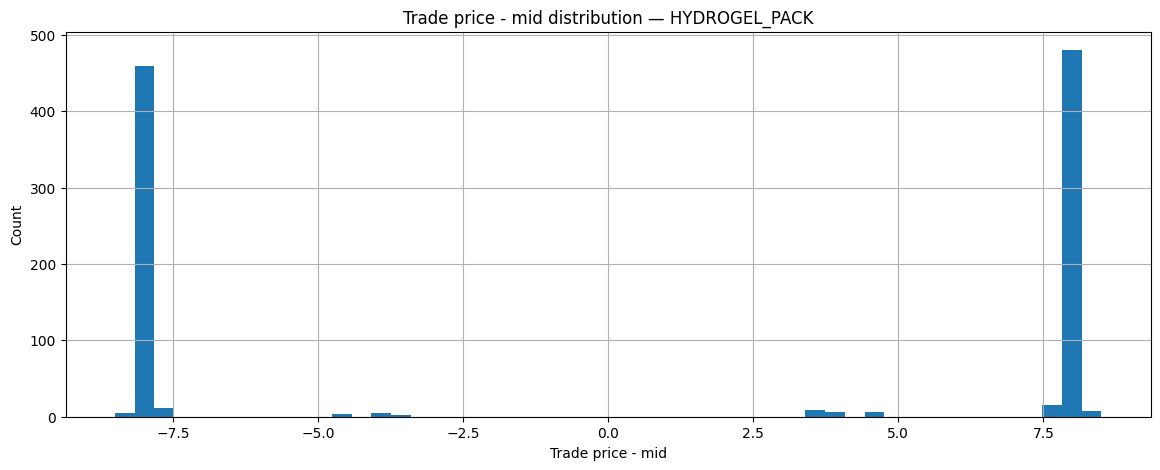

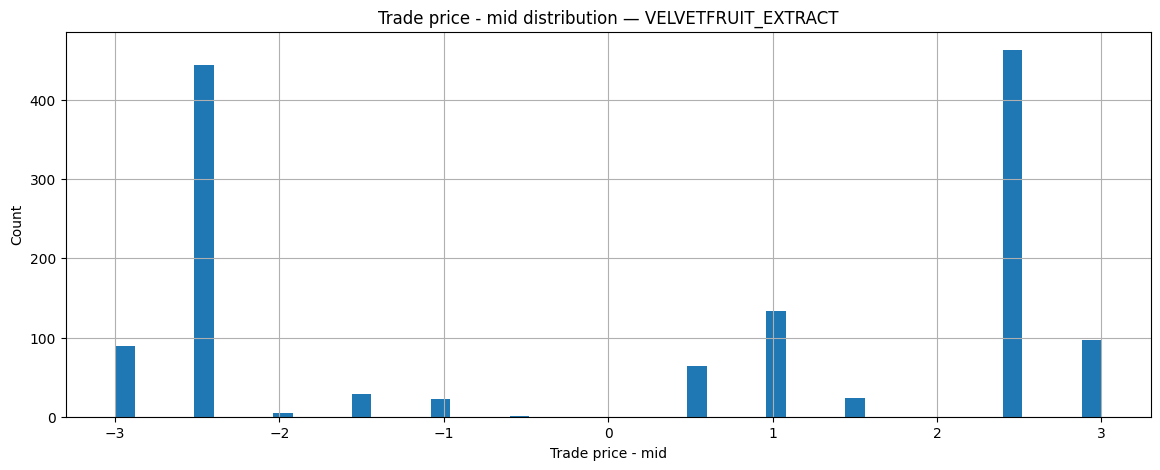

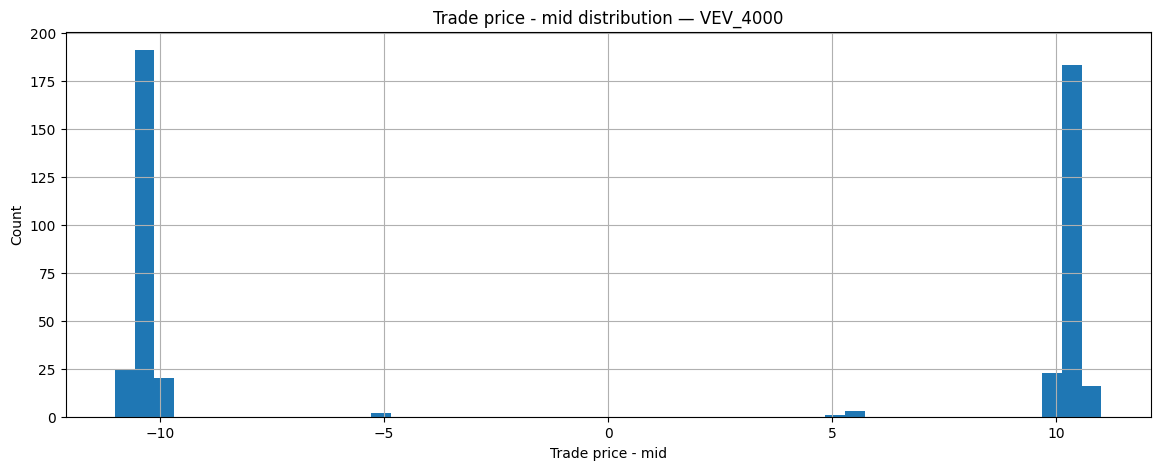

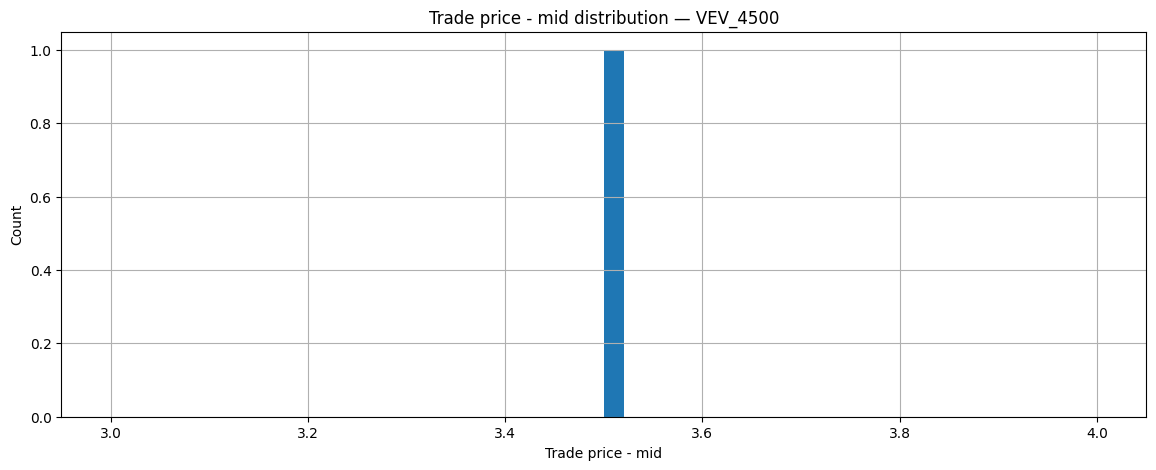

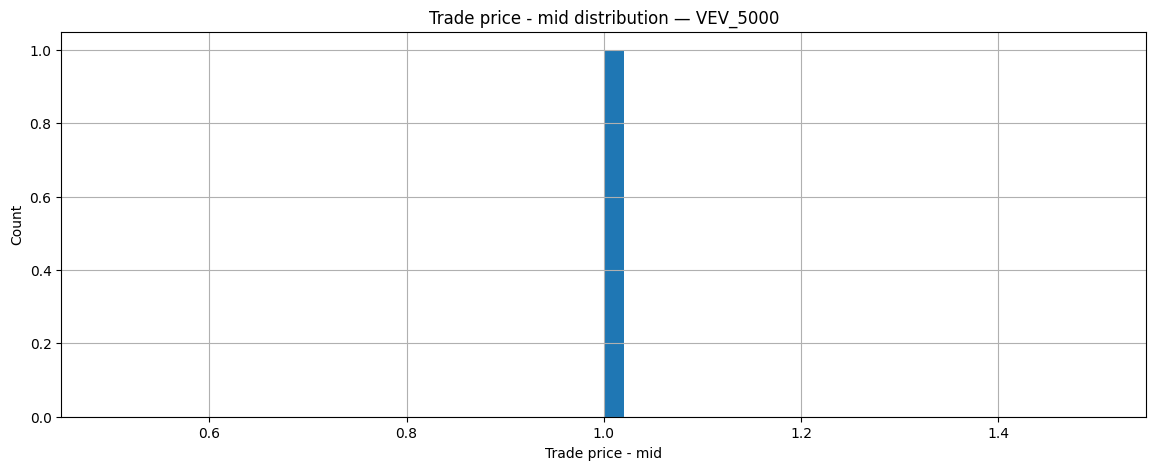

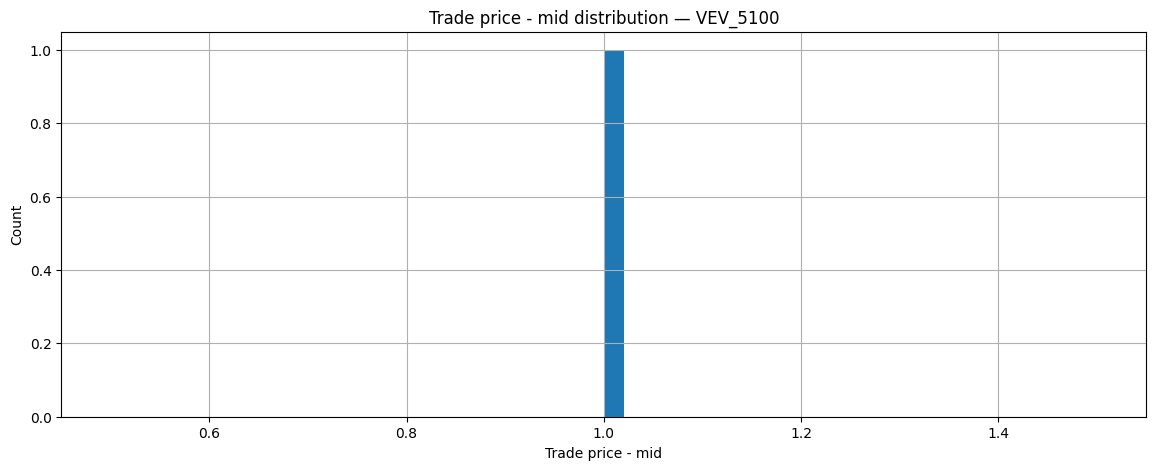

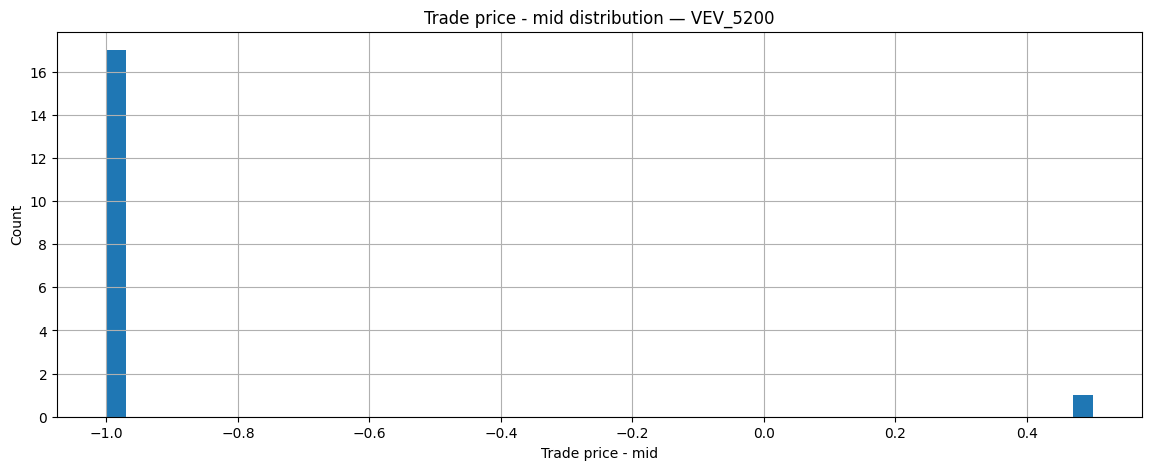

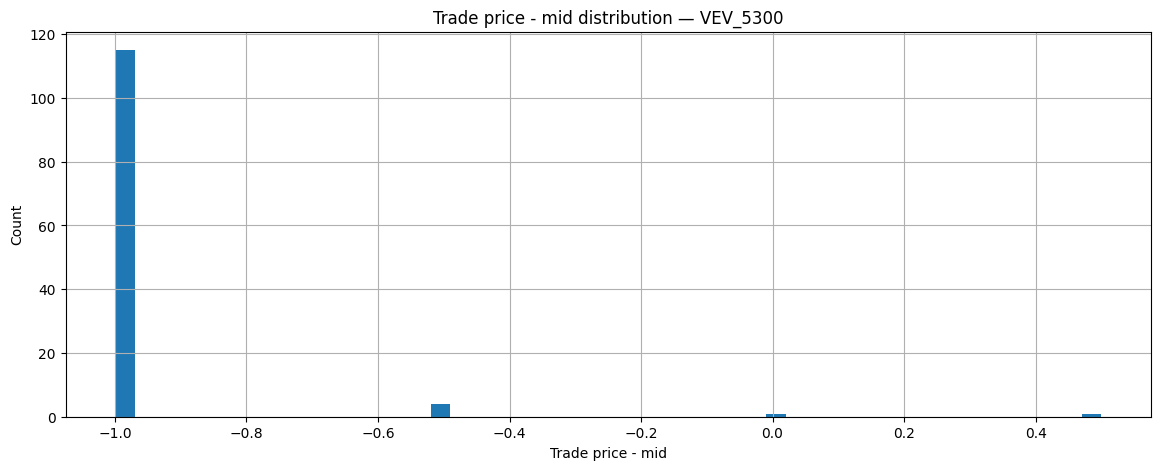

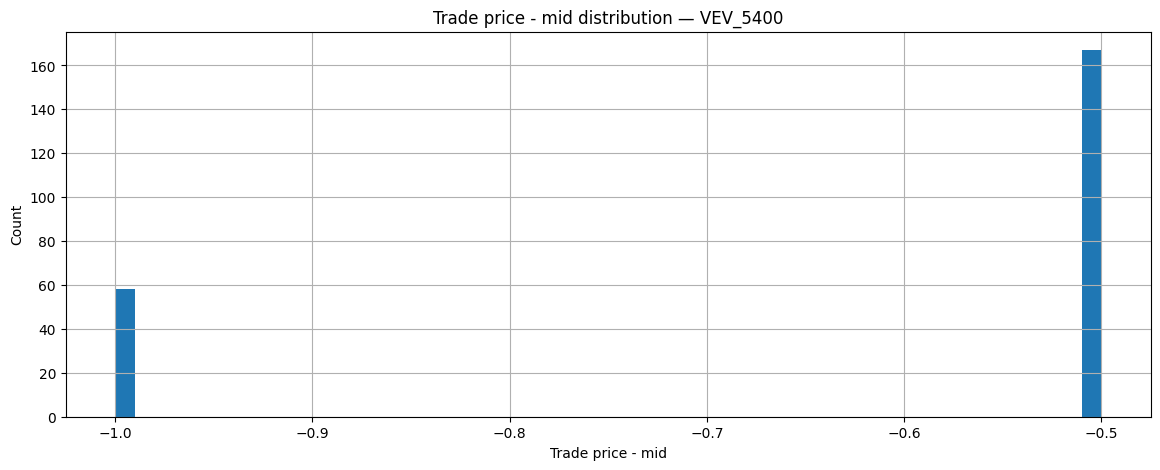

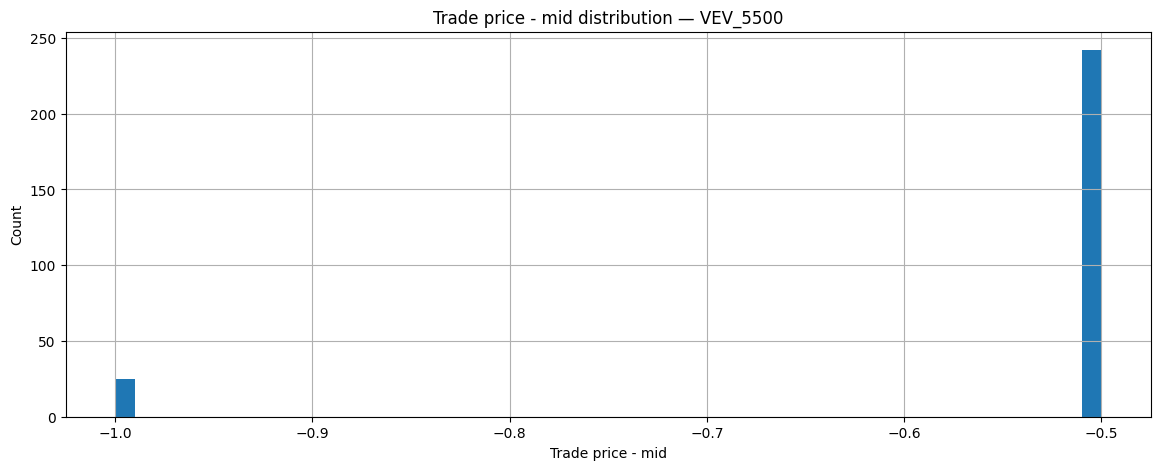

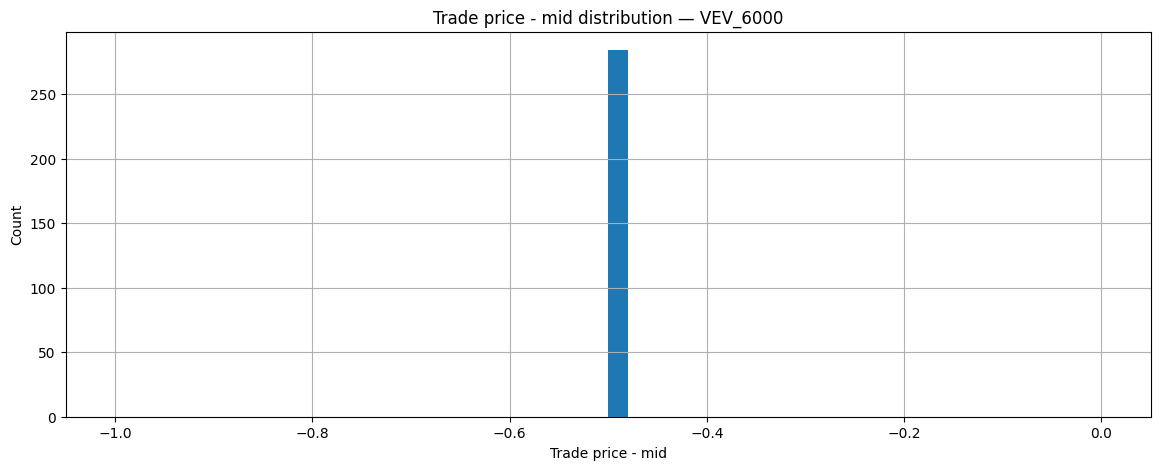

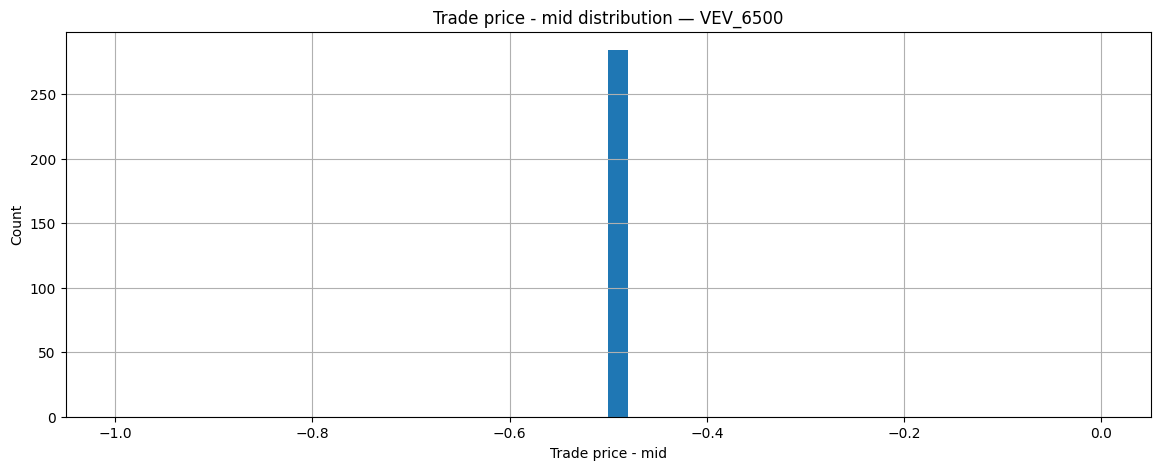

In [15]:
for product in sorted(trade_mid["symbol"].unique()):
    df = trade_mid[trade_mid["symbol"] == product]

    plt.figure()
    plt.hist(df["trade_vs_mid"].dropna(), bins=50)
    plt.title(f"Trade price - mid distribution — {product}")
    plt.xlabel("Trade price - mid")
    plt.ylabel("Count")
    plt.show()

In [16]:
products = sorted(prices["product"].unique())

underlyings = [
    "HYDROGEL_PACK",
    "VELVETFRUIT_EXTRACT",
]

vouchers = [p for p in products if "VEV" in p or "VOUCHER" in p]

print("Underlyings:")
print(underlyings)

print("\nVouchers:")
print(vouchers)

def extract_strike(product):
    try:
        return int(product.split("_")[-1])
    except:
        return np.nan

voucher_info = pd.DataFrame({
    "product": vouchers,
    "strike": [extract_strike(p) for p in vouchers],
}).sort_values("strike")

display(voucher_info)

Underlyings:
['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT']

Vouchers:
['VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']


,product,strike
0,VEV_4000,4000
1,VEV_4500,4500
2,VEV_5000,5000
3,VEV_5100,5100
4,VEV_5200,5200
5,VEV_5300,5300
6,VEV_5400,5400
7,VEV_5500,5500
8,VEV_6000,6000
9,VEV_6500,6500


In [17]:
sanity_report = []

for product, df in prices.groupby("product"):
    sanity_report.append({
        "product": product,
        "rows": len(df),
        "days_present": df["day"].nunique(),
        "timestamp_min": df["timestamp"].min(),
        "timestamp_max": df["timestamp"].max(),
        "mid_min": df["mid"].min(),
        "mid_max": df["mid"].max(),
        "mid_std": df["mid"].std(),
        "spread_mean": df["spread"].mean(),
        "spread_median": df["spread"].median(),
        "spread_min": df["spread"].min(),
        "spread_max": df["spread"].max(),
        "avg_book_volume": df["total_book_volume"].mean(),
    })

sanity_report = pd.DataFrame(sanity_report).sort_values("product")
display(sanity_report)

,product,rows,days_present,timestamp_min,timestamp_max,mid_min,mid_max,mid_std,spread_mean,spread_median,spread_min,spread_max,avg_book_volume
0,HYDROGEL_PACK,30000,3,0,999900,9891.0,10079.0,31.935214,15.720800,16.0,7.0,17.0,75.263667
1,VELVETFRUIT_EXTRACT,30000,3,0,999900,5198.0,5300.0,15.630415,4.988133,5.0,1.0,6.0,120.732267
2,VEV_4000,30000,3,0,999900,1198.0,1300.0,15.647243,20.813467,21.0,9.0,22.0,67.033433
3,VEV_4500,30000,3,0,999900,698.5,799.5,15.639930,15.852667,16.0,7.0,17.0,54.025233
4,VEV_5000,30000,3,0,999900,206.5,300.5,14.375586,6.043333,6.0,2.0,7.0,54.025233
5,VEV_5100,30000,3,0,999900,125.0,205.5,12.742624,4.295833,4.0,1.0,6.0,54.025233
6,VEV_5200,30000,3,0,999900,64.0,122.5,9.664218,2.888133,3.0,1.0,4.0,54.021100
7,VEV_5300,30000,3,0,999900,26.5,65.5,6.228141,2.106800,2.0,1.0,3.0,44.993900
8,VEV_5400,30000,3,0,999900,6.5,27.0,3.429182,1.381433,1.0,1.0,2.0,44.969367
9,VEV_5500,30000,3,0,999900,2.5,12.5,1.738849,1.149767,1.0,1.0,2.0,44.959367


## Fair-value proxy for delta-1 products

In [26]:
delta_products = ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"]

delta = prices[prices["product"].isin(delta_products)].copy()
delta = delta.sort_values(["product", "day", "timestamp"])

display(delta.head())

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,best_bid,best_ask,mid,spread,total_bid_volume,total_ask_volume,total_book_volume,book_imbalance,best_bid_volume,best_ask_volume
7,0,0,HYDROGEL_PACK,9992,15,9990.0,30.0,NaN,NaN,10008,...,9992.0,10008.0,10000.0,16.0,45.0,45.0,90.0,0.0,15.0,15.0
19,0,100,HYDROGEL_PACK,9992,13,9990.0,30.0,NaN,NaN,10008,...,9992.0,10008.0,10000.0,16.0,43.0,43.0,86.0,0.0,13.0,13.0
24,0,200,HYDROGEL_PACK,9995,13,9992.0,21.0,NaN,NaN,10011,...,9995.0,10011.0,10003.0,16.0,34.0,34.0,68.0,0.0,13.0,13.0
41,0,300,HYDROGEL_PACK,9994,11,9992.0,23.0,NaN,NaN,10010,...,9994.0,10010.0,10002.0,16.0,34.0,34.0,68.0,0.0,11.0,11.0
54,0,400,HYDROGEL_PACK,9995,13,9993.0,23.0,NaN,NaN,10011,...,9995.0,10011.0,10003.0,16.0,36.0,36.0,72.0,0.0,13.0,13.0


In [27]:
def first_valid(row, cols):
    for c in cols:
        if pd.notna(row[c]):
            return row[c]
    return np.nan

def last_valid(row, cols):
    vals = [row[c] for c in cols if pd.notna(row[c])]
    return vals[-1] if vals else np.nan

# Best-level midpoint
delta["mid"] = (delta["best_bid"] + delta["best_ask"]) / 2

# Filtered mid: first bid/ask level with volume >= 10
delta["filtered_bid"] = np.nan
delta["filtered_ask"] = np.nan

for i in [1, 2, 3]:
    bp, bv = f"bid_price_{i}", f"bid_volume_{i}"
    ap, av = f"ask_price_{i}", f"ask_volume_{i}"

    if bp in delta.columns:
        mask = delta["filtered_bid"].isna() & delta[bv].abs().ge(10)
        delta.loc[mask, "filtered_bid"] = delta.loc[mask, bp]

    if ap in delta.columns:
        mask = delta["filtered_ask"].isna() & delta[av].abs().ge(10)
        delta.loc[mask, "filtered_ask"] = delta.loc[mask, ap]

delta["filtered_mid"] = (delta["filtered_bid"] + delta["filtered_ask"]) / 2

# Wall mid: outermost visible bid/ask level
delta["wall_bid"] = delta.apply(lambda r: last_valid(r, bid_price_cols), axis=1)
delta["wall_ask"] = delta.apply(lambda r: last_valid(r, ask_price_cols), axis=1)
delta["wall_mid"] = (delta["wall_bid"] + delta["wall_ask"]) / 2

# Microprice using best bid/ask and best volumes
delta["microprice"] = (
    delta["best_bid"] * delta["best_ask_volume"]
    + delta["best_ask"] * delta["best_bid_volume"]
) / (delta["best_bid_volume"] + delta["best_ask_volume"])

proxy_cols = ["mid", "filtered_mid", "wall_mid", "microprice"]

display(delta[["day", "timestamp", "product"] + proxy_cols].head())

,day,timestamp,product,mid,filtered_mid,wall_mid,microprice
7,0,0,HYDROGEL_PACK,10000.0,10000.0,10000.0,10000.0
19,0,100,HYDROGEL_PACK,10000.0,10000.0,10000.5,10000.0
24,0,200,HYDROGEL_PACK,10003.0,10003.0,10002.5,10003.0
41,0,300,HYDROGEL_PACK,10002.0,10002.0,10002.5,10002.0
54,0,400,HYDROGEL_PACK,10003.0,10003.0,10003.5,10003.0


In [28]:
proxy_coverage = delta.groupby("product")[proxy_cols].apply(
    lambda df: df.notna().mean()
)

display(proxy_coverage)

,mid,filtered_mid,wall_mid,microprice
product,,,,
HYDROGEL_PACK,1.0,1.0,1.0,1.0
VELVETFRUIT_EXTRACT,1.0,1.0,1.0,1.0


In [29]:
for col in proxy_cols:
    delta[f"{col}_diff"] = delta.groupby(["product", "day"])[col].diff()

stability = []

for product in delta_products:
    df = delta[delta["product"] == product]

    for col in proxy_cols:
        d = df[f"{col}_diff"].dropna()

        stability.append({
            "product": product,
            "proxy": col,
            "mean_abs_diff": d.abs().mean(),
            "std_diff": d.std(),
            "median_abs_diff": d.abs().median(),
            "max_abs_diff": d.abs().max(),
        })

stability = pd.DataFrame(stability).sort_values(
    ["product", "mean_abs_diff"]
)

display(stability)

,product,proxy,mean_abs_diff,std_diff,median_abs_diff,max_abs_diff
2,HYDROGEL_PACK,wall_mid,1.501433,1.919101,1.0,8.000000
1,HYDROGEL_PACK,filtered_mid,1.523419,1.955661,1.0,9.500000
3,HYDROGEL_PACK,microprice,1.598291,2.057265,1.0,10.928571
0,HYDROGEL_PACK,mid,1.664366,2.169826,1.0,11.500000
6,VELVETFRUIT_EXTRACT,wall_mid,0.752792,0.981581,0.5,4.000000
5,VELVETFRUIT_EXTRACT,filtered_mid,0.797096,1.050454,1.0,5.500000
4,VELVETFRUIT_EXTRACT,mid,0.857702,1.131176,1.0,5.500000
7,VELVETFRUIT_EXTRACT,microprice,1.136424,1.423599,1.0,6.038386


In [30]:
disagreement = []

for product in delta_products:
    df = delta[delta["product"] == product]

    for col in proxy_cols:
        if col == "mid":
            continue

        diff = df[col] - df["mid"]

        disagreement.append({
            "product": product,
            "proxy": col,
            "mean_diff_vs_mid": diff.mean(),
            "mean_abs_diff_vs_mid": diff.abs().mean(),
            "std_diff_vs_mid": diff.std(),
            "max_abs_diff_vs_mid": diff.abs().max(),
        })

disagreement = pd.DataFrame(disagreement).sort_values(
    ["product", "mean_abs_diff_vs_mid"]
)

display(disagreement)

,product,proxy,mean_diff_vs_mid,mean_abs_diff_vs_mid,std_diff_vs_mid,max_abs_diff_vs_mid
2,HYDROGEL_PACK,microprice,-0.000338,0.037164,0.230453,2.605263
0,HYDROGEL_PACK,filtered_mid,0.012500,0.114633,0.681940,4.500000
1,HYDROGEL_PACK,wall_mid,0.012317,0.569650,0.865890,4.500000
3,VELVETFRUIT_EXTRACT,filtered_mid,0.012900,0.065167,0.302550,2.000000
4,VELVETFRUIT_EXTRACT,wall_mid,0.019267,0.359367,0.534514,2.000000
5,VELVETFRUIT_EXTRACT,microprice,-0.008365,0.691429,0.924338,1.743590


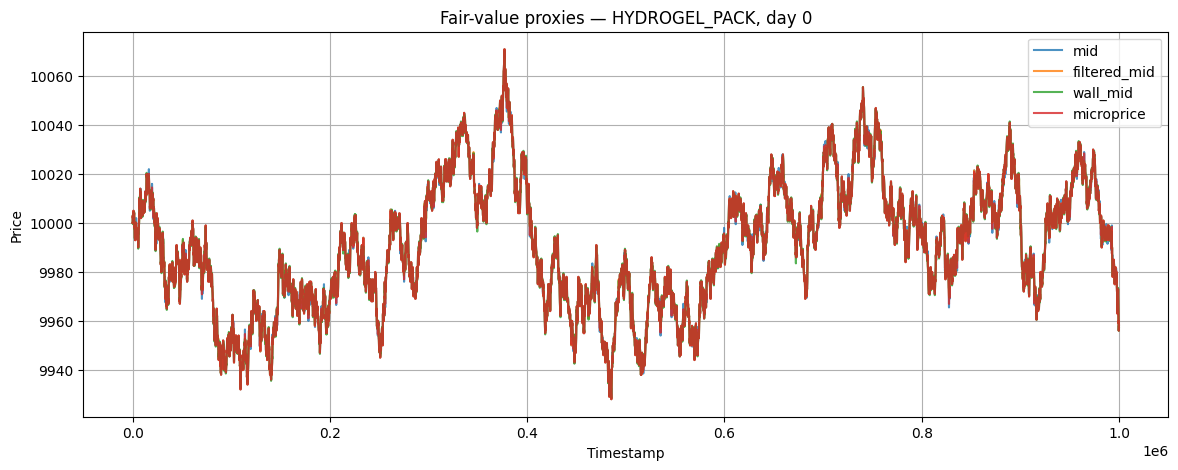

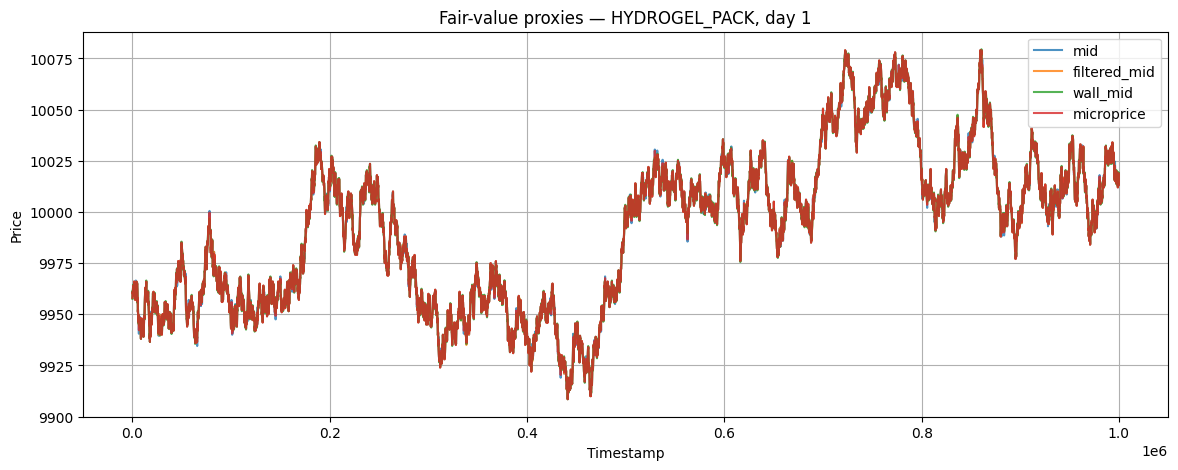

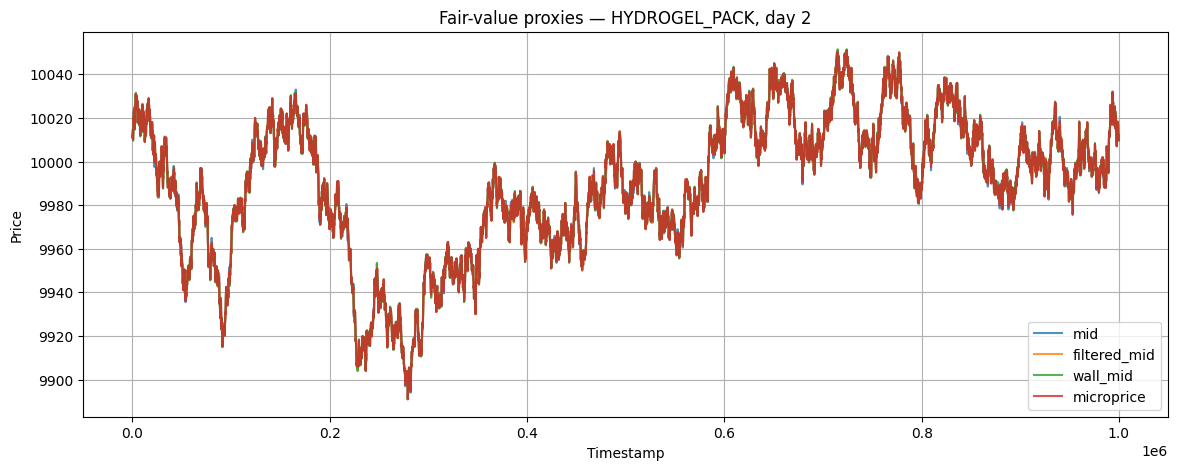

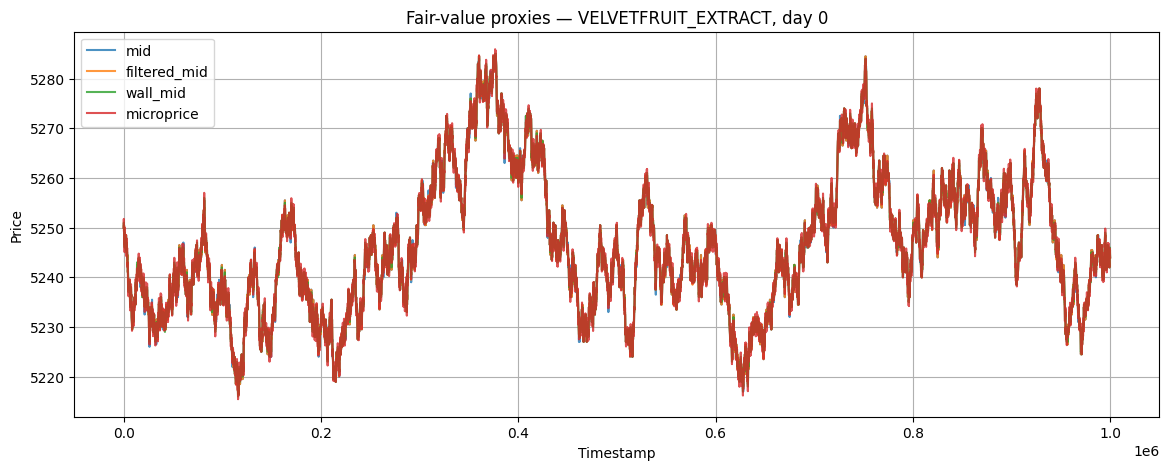

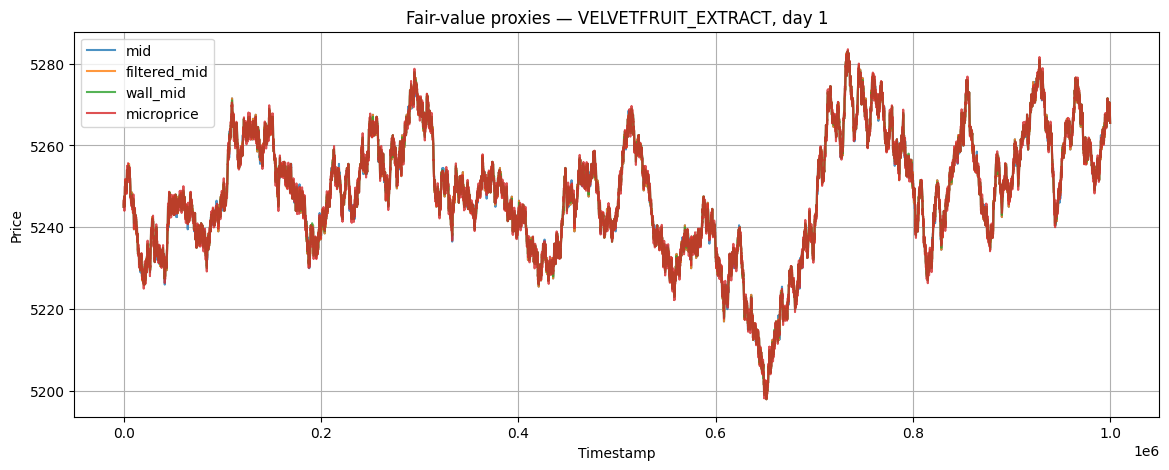

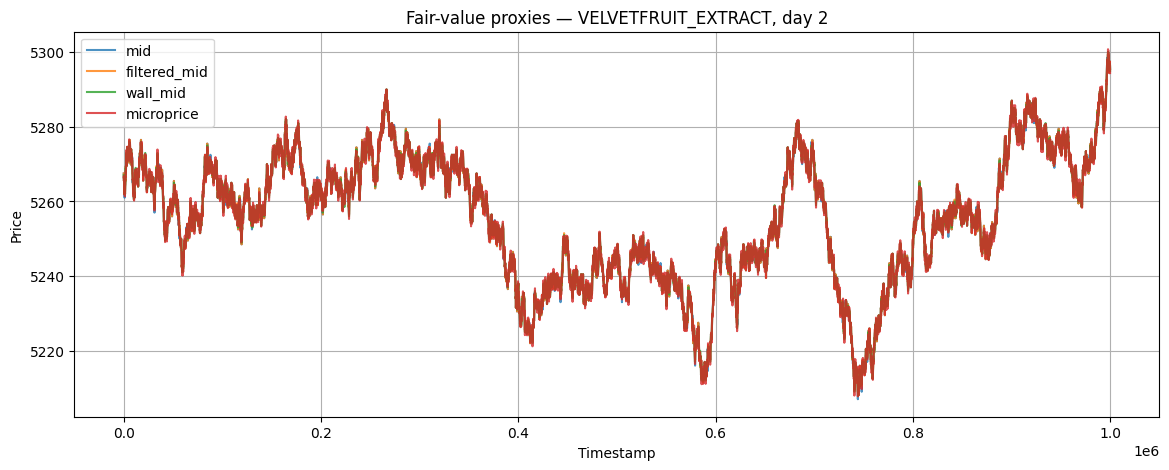

In [31]:
for product in delta_products:
    for day in sorted(delta["day"].unique()):
        df = delta[(delta["product"] == product) & (delta["day"] == day)]

        plt.figure(figsize=(14, 5))
        for col in proxy_cols:
            plt.plot(df["timestamp"], df[col], label=col, alpha=0.8)

        plt.title(f"Fair-value proxies — {product}, day {day}")
        plt.xlabel("Timestamp")
        plt.ylabel("Price")
        plt.legend()
        plt.show()

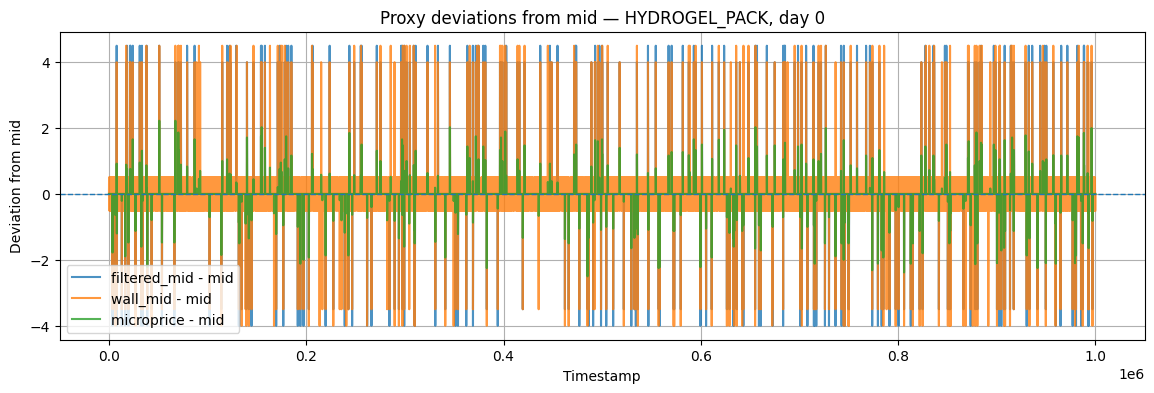

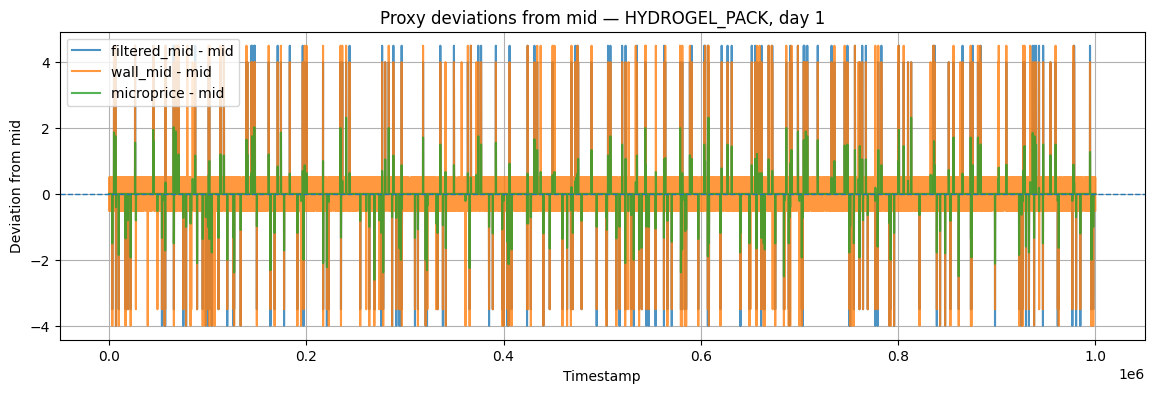

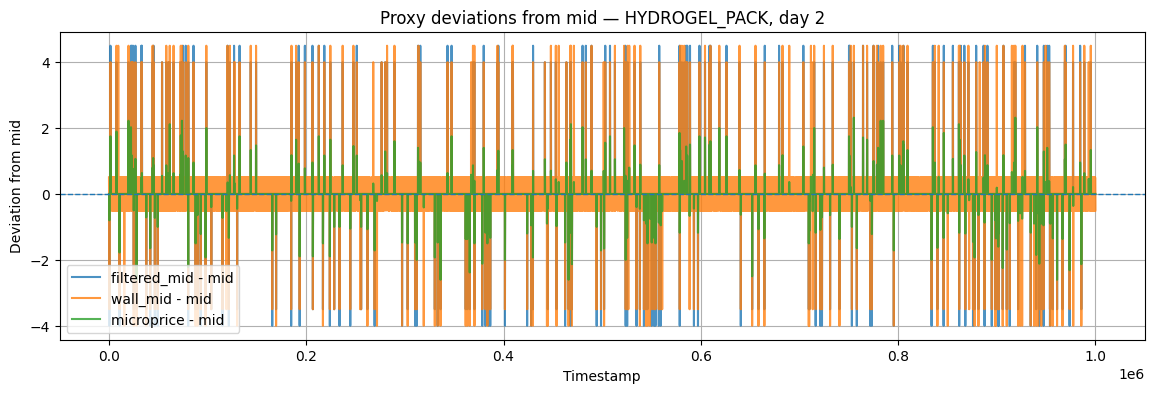

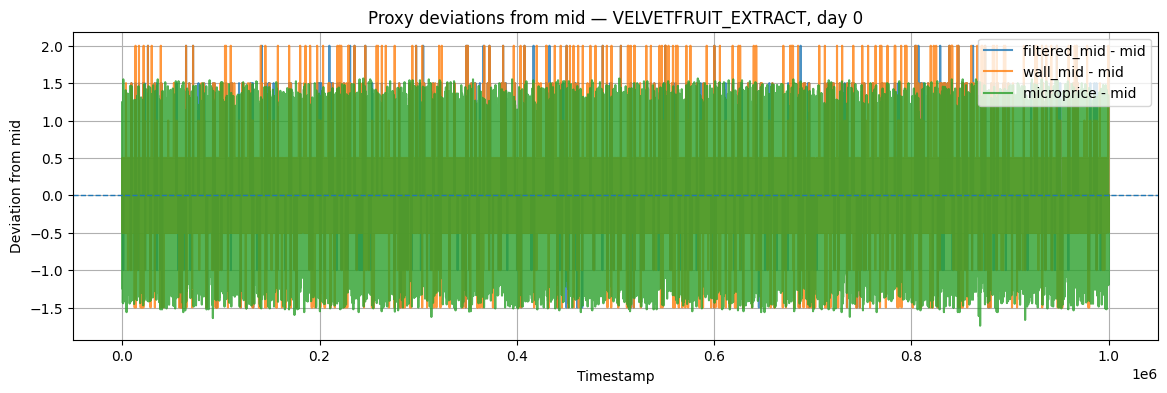

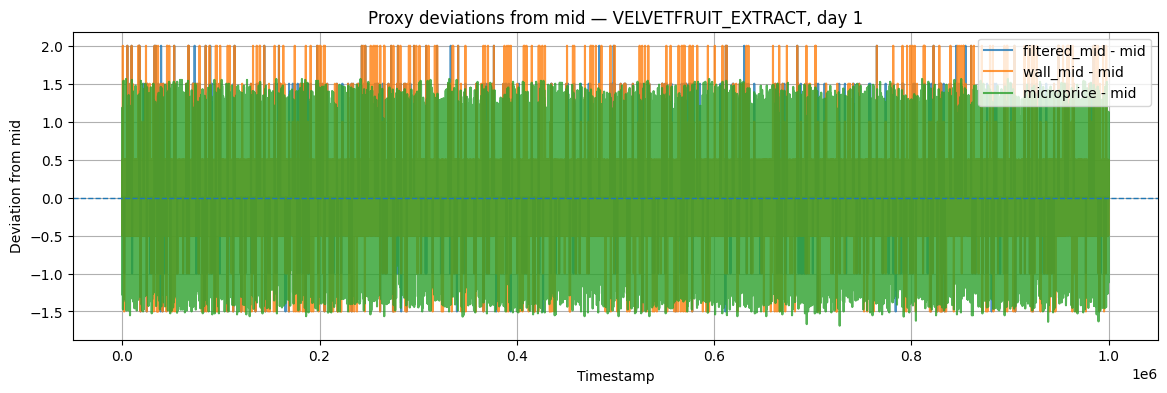

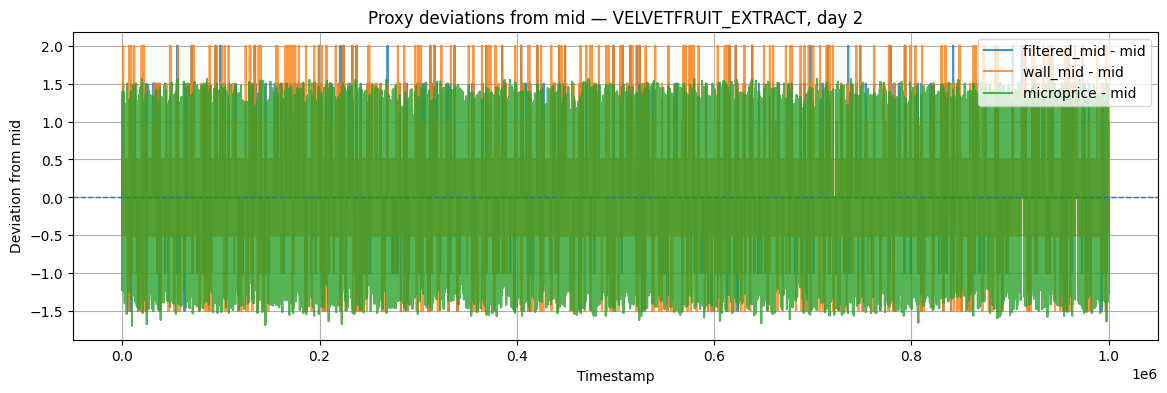

In [32]:
for product in delta_products:
    for day in sorted(delta["day"].unique()):
        df = delta[(delta["product"] == product) & (delta["day"] == day)]

        plt.figure(figsize=(14, 4))

        for col in ["filtered_mid", "wall_mid", "microprice"]:
            plt.plot(df["timestamp"], df[col] - df["mid"], label=f"{col} - mid", alpha=0.8)

        plt.axhline(0, linestyle="--", linewidth=1)
        plt.title(f"Proxy deviations from mid — {product}, day {day}")
        plt.xlabel("Timestamp")
        plt.ylabel("Deviation from mid")
        plt.legend()
        plt.show()

In [33]:
proxy_prediction = []

tmp = delta.sort_values(["product", "day", "timestamp"]).copy()
tmp["next_mid"] = tmp.groupby(["product", "day"])["mid"].shift(-1)
tmp["next_return"] = tmp["next_mid"] - tmp["mid"]

for product in delta_products:
    df = tmp[tmp["product"] == product]

    for col in ["filtered_mid", "wall_mid", "microprice"]:
        signal = df[col] - df["mid"]

        valid = pd.DataFrame({
            "signal": signal,
            "next_return": df["next_return"],
        }).dropna()

        proxy_prediction.append({
            "product": product,
            "proxy_signal": f"{col} - mid",
            "corr_signal_next_return": valid["signal"].corr(valid["next_return"]),
            "avg_next_return_signal_pos": valid.loc[valid["signal"] > 0, "next_return"].mean(),
            "avg_next_return_signal_neg": valid.loc[valid["signal"] < 0, "next_return"].mean(),
            "count_signal_pos": (valid["signal"] > 0).sum(),
            "count_signal_neg": (valid["signal"] < 0).sum(),
        })

proxy_prediction = pd.DataFrame(proxy_prediction).sort_values(
    ["product", "corr_signal_next_return"],
    ascending=[True, False]
)

display(proxy_prediction)

,product,proxy_signal,corr_signal_next_return,avg_next_return_signal_pos,avg_next_return_signal_neg,count_signal_pos,count_signal_neg
1,HYDROGEL_PACK,wall_mid - mid,0.339684,0.379694,-0.379974,13607,13647
0,HYDROGEL_PACK,filtered_mid - mid,0.313505,4.157718,-3.894349,447,407
2,HYDROGEL_PACK,microprice - mid,0.296998,4.156687,-3.904348,501,460
4,VELVETFRUIT_EXTRACT,wall_mid - mid,0.366180,0.427423,-0.378912,8832,8754
3,VELVETFRUIT_EXTRACT,filtered_mid - mid,0.267010,1.576248,-1.075380,741,723
5,VELVETFRUIT_EXTRACT,microprice - mid,0.226971,0.426241,-0.378442,8826,8753


In [34]:
smoothness = []

for product in delta_products:
    df = delta[delta["product"] == product]

    for col in proxy_cols:
        smoothness.append({
            "product": product,
            "proxy": col,
            "num_unique_values": df[col].nunique(),
            "std_price": df[col].std(),
            "mean_abs_diff": df[f"{col}_diff"].abs().mean(),
            "zero_diff_fraction": (df[f"{col}_diff"] == 0).mean(),
        })

smoothness = pd.DataFrame(smoothness).sort_values(
    ["product", "mean_abs_diff"]
)

display(smoothness)

,product,proxy,num_unique_values,std_price,mean_abs_diff,zero_diff_fraction
2,HYDROGEL_PACK,wall_mid,368,31.934120,1.501433,0.187700
1,HYDROGEL_PACK,filtered_mid,365,31.937117,1.523419,0.190800
3,HYDROGEL_PACK,microprice,1143,31.934968,1.598291,0.180067
0,HYDROGEL_PACK,mid,368,31.935214,1.664366,0.180167
6,VELVETFRUIT_EXTRACT,wall_mid,196,15.627583,0.752792,0.255433
5,VELVETFRUIT_EXTRACT,filtered_mid,198,15.627777,0.797096,0.262633
4,VELVETFRUIT_EXTRACT,mid,199,15.630415,0.857702,0.246667
7,VELVETFRUIT_EXTRACT,microprice,12370,15.642608,1.136424,0.039867


In [35]:
decision_table = stability.merge(
    disagreement,
    on=["product", "proxy"],
    how="left"
).merge(
    smoothness[["product", "proxy", "num_unique_values", "zero_diff_fraction"]],
    on=["product", "proxy"],
    how="left"
)

decision_table = decision_table.sort_values(["product", "mean_abs_diff"])

display(decision_table)

,product,proxy,mean_abs_diff,std_diff,median_abs_diff,max_abs_diff,mean_diff_vs_mid,mean_abs_diff_vs_mid,std_diff_vs_mid,max_abs_diff_vs_mid,num_unique_values,zero_diff_fraction
0,HYDROGEL_PACK,wall_mid,1.501433,1.919101,1.0,8.000000,0.012317,0.569650,0.865890,4.500000,368,0.187700
1,HYDROGEL_PACK,filtered_mid,1.523419,1.955661,1.0,9.500000,0.012500,0.114633,0.681940,4.500000,365,0.190800
2,HYDROGEL_PACK,microprice,1.598291,2.057265,1.0,10.928571,-0.000338,0.037164,0.230453,2.605263,1143,0.180067
3,HYDROGEL_PACK,mid,1.664366,2.169826,1.0,11.500000,NaN,NaN,NaN,NaN,368,0.180167
4,VELVETFRUIT_EXTRACT,wall_mid,0.752792,0.981581,0.5,4.000000,0.019267,0.359367,0.534514,2.000000,196,0.255433
5,VELVETFRUIT_EXTRACT,filtered_mid,0.797096,1.050454,1.0,5.500000,0.012900,0.065167,0.302550,2.000000,198,0.262633
6,VELVETFRUIT_EXTRACT,mid,0.857702,1.131176,1.0,5.500000,NaN,NaN,NaN,NaN,199,0.246667
7,VELVETFRUIT_EXTRACT,microprice,1.136424,1.423599,1.0,6.038386,-0.008365,0.691429,0.924338,1.743590,12370,0.039867


## Underlying dynamics

In [36]:
underlying = prices[prices["product"] == "VELVETFRUIT_EXTRACT"].copy()
underlying = underlying.sort_values(["day", "timestamp"])

underlying["mid"] = (underlying["best_bid"] + underlying["best_ask"]) / 2

display(underlying.head())

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,best_bid,best_ask,mid,spread,total_bid_volume,total_ask_volume,total_book_volume,book_imbalance,best_bid_volume,best_ask_volume
5,0,0,VELVETFRUIT_EXTRACT,5247,67,NaN,NaN,NaN,NaN,5253,...,5247.0,5253.0,5250.0,6.0,67.0,67.0,134.0,0.0,67.0,67.0
13,0,100,VELVETFRUIT_EXTRACT,5248,69,NaN,NaN,NaN,NaN,5253,...,5248.0,5253.0,5250.5,5.0,69.0,69.0,138.0,0.0,69.0,23.0
25,0,200,VELVETFRUIT_EXTRACT,5248,20,5247.0,40.0,NaN,NaN,5253,...,5248.0,5253.0,5250.5,5.0,60.0,60.0,120.0,0.0,20.0,60.0
47,0,300,VELVETFRUIT_EXTRACT,5248,24,5247.0,40.0,NaN,NaN,5253,...,5248.0,5253.0,5250.5,5.0,64.0,64.0,128.0,0.0,24.0,64.0
55,0,400,VELVETFRUIT_EXTRACT,5248,25,5247.0,37.0,NaN,NaN,5253,...,5248.0,5253.0,5250.5,5.0,62.0,62.0,124.0,0.0,25.0,62.0


In [37]:
underlying["ret_1"] = underlying.groupby("day")["mid"].diff()
underlying["ret_5"] = underlying.groupby("day")["mid"].diff(5)
underlying["ret_10"] = underlying.groupby("day")["mid"].diff(10)

ret_stats = underlying[["ret_1", "ret_5", "ret_10"]].describe()

display(ret_stats)

,ret_1,ret_5,ret_10
count,29997.000000,29985.000000,29970.000000
mean,0.001417,0.007704,0.016266
std,1.131176,2.187364,3.024748
min,-5.500000,-8.000000,-11.500000
25%,-1.000000,-1.500000,-2.000000
50%,0.000000,0.000000,0.000000
75%,1.000000,1.500000,2.000000
max,5.000000,10.000000,11.500000


In [38]:
drift = underlying.groupby("day")["ret_1"].agg([
    "mean",
    "median",
    "std"
]).rename(columns={
    "mean": "mean_return",
    "median": "median_return",
    "std": "volatility"
})

display(drift)

,mean_return,median_return,volatility
day,,,
0,-0.00060,0.0,1.120581
1,0.00205,0.0,1.134869
2,0.00280,0.0,1.138113


In [39]:
from statsmodels.tsa.stattools import acf

acf_results = []

for day in underlying["day"].unique():
    series = underlying[underlying["day"] == day]["ret_1"].dropna()

    acf_vals = acf(series, nlags=10)

    for lag in range(1, 6):
        acf_results.append({
            "day": day,
            "lag": lag,
            "acf": acf_vals[lag]
        })

acf_df = pd.DataFrame(acf_results)

display(acf_df.pivot(index="lag", columns="day", values="acf"))

day,0,1,2
lag,,,
1,-0.150962,-0.169282,-0.155117
2,0.015572,-0.002741,0.002232
3,-0.008583,0.003394,-0.011724
4,0.002011,0.001064,-0.001570
5,0.006352,-0.005712,0.003796


In [42]:
import statsmodels.api as sm

reversion_results = []

for day in underlying["day"].unique():
    df = underlying[underlying["day"] == day].copy()

    df["ret_lag"] = df["ret_1"].shift(1)

    valid = df[["ret_1", "ret_lag"]].dropna()

    # Need at least 2 observations for OLS with intercept + slope
    if len(valid) < 2:
        continue

    X = sm.add_constant(valid["ret_lag"])
    y = valid["ret_1"]

    model = sm.OLS(y, X).fit()

    reversion_results.append({
        "day": day,
        "beta_lag1": model.params["ret_lag"],
        "r2": model.rsquared,
        "n_obs": len(valid)
    })

reversion_df = pd.DataFrame(reversion_results)

display(reversion_df)

,day,beta_lag1,r2,n_obs
0,0,-0.150989,0.022794,9998
1,1,-0.169295,0.028659,9998
2,2,-0.155130,0.024071,9998


In [43]:
underlying["abs_ret"] = underlying["ret_1"].abs()

vol_cluster = []

for day in underlying["day"].unique():
    df = underlying[underlying["day"] == day]

    corr = df["abs_ret"].autocorr(lag=1)

    vol_cluster.append({
        "day": day,
        "abs_ret_autocorr_lag1": corr
    })

vol_cluster = pd.DataFrame(vol_cluster)

display(vol_cluster)

,day,abs_ret_autocorr_lag1
0,0,0.082264
1,1,0.088599
2,2,0.092611


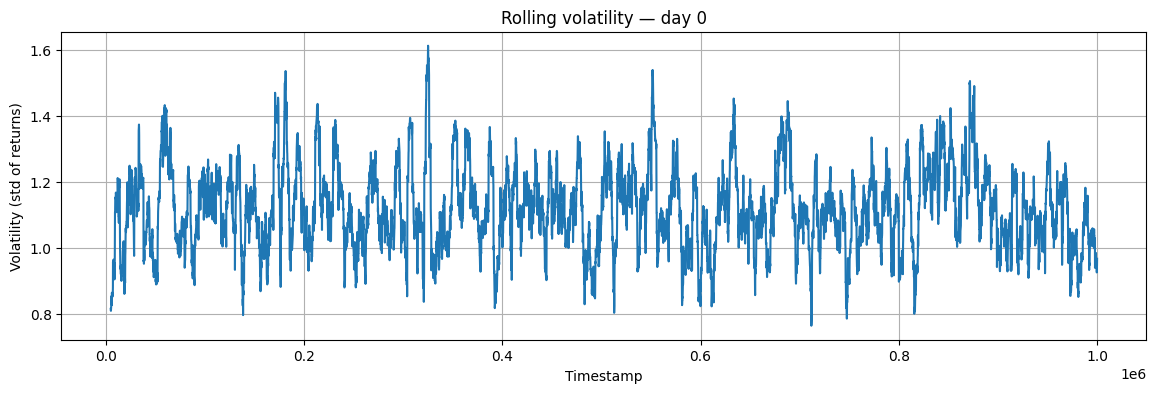

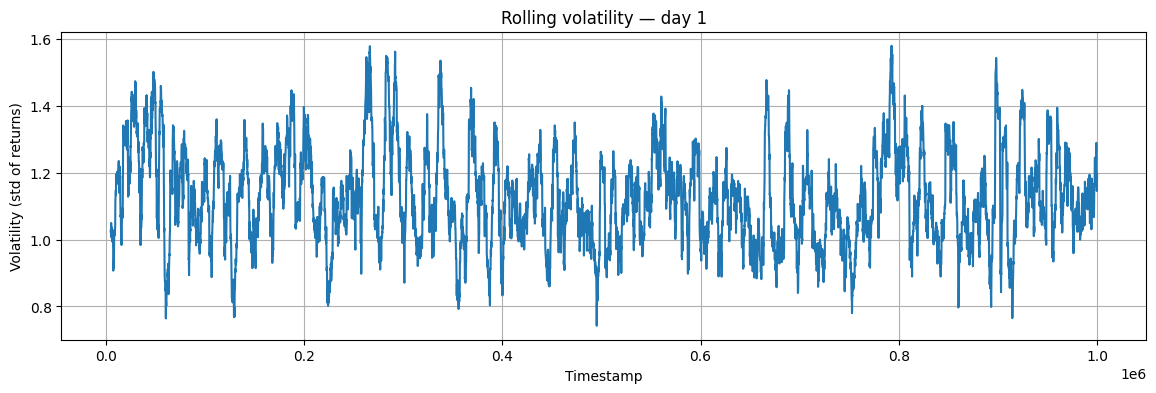

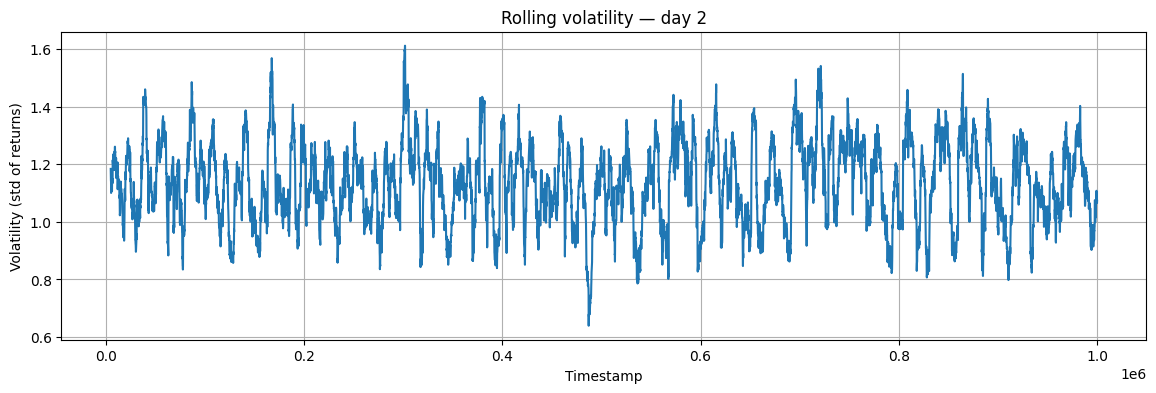

In [44]:
underlying["rolling_vol"] = underlying.groupby("day")["ret_1"].rolling(50).std().reset_index(level=0, drop=True)

for day in underlying["day"].unique():
    df = underlying[underlying["day"] == day]

    plt.figure(figsize=(14, 4))
    plt.plot(df["timestamp"], df["rolling_vol"])
    plt.title(f"Rolling volatility — day {day}")
    plt.xlabel("Timestamp")
    plt.ylabel("Volatility (std of returns)")
    plt.show()

In [45]:
# normalize timestamp within each day
underlying["time_bucket"] = pd.qcut(
    underlying["timestamp"],
    q=20,
    labels=False,
    duplicates="drop"
)

intraday = underlying.groupby("time_bucket")["ret_1"].agg([
    "mean",
    "std",
    "count"
])

display(intraday)

,mean,std,count
time_bucket,,,
0,-0.010688,1.149817,1497
1,0.002333,1.152554,1500
2,0.009667,1.113508,1500
3,-0.022333,1.171573,1500
4,0.040333,1.110118,1500
5,0.004333,1.157169,1500
6,-0.010667,1.149101,1500
7,-0.029000,1.118851,1500
8,0.000000,1.116018,1500


In [46]:
thresholds = [1, 2, 3]

large_moves = []

for t in thresholds:
    frac = (underlying["ret_1"].abs() >= t).mean()

    large_moves.append({
        "threshold": t,
        "fraction": frac
    })

large_moves = pd.DataFrame(large_moves)

display(large_moves)

,threshold,fraction
0,1,0.537833
1,2,0.129067
2,3,0.019300


In [47]:
underlying["direction"] = np.sign(underlying["ret_1"])

underlying["same_direction"] = (
    underlying["direction"] == underlying["direction"].shift(1)
)

persistence = underlying["same_direction"].mean()

print("Directional persistence:", persistence)

Directional persistence: 0.3239666666666667


## Hydrogel structure

In [48]:
hydrogel = prices[prices["product"] == "HYDROGEL_PACK"].copy()
velvet = prices[prices["product"] == "VELVETFRUIT_EXTRACT"].copy()

hydrogel = hydrogel.sort_values(["day", "timestamp"])
velvet = velvet.sort_values(["day", "timestamp"])

hydrogel["mid"] = (hydrogel["best_bid"] + hydrogel["best_ask"]) / 2
velvet["mid"] = (velvet["best_bid"] + velvet["best_ask"]) / 2

pair = hydrogel[
    ["day", "timestamp", "mid", "spread", "book_imbalance"]
].rename(columns={
    "mid": "hydro_mid",
    "spread": "hydro_spread",
    "book_imbalance": "hydro_imbalance",
}).merge(
    velvet[
        ["day", "timestamp", "mid", "spread", "book_imbalance"]
    ].rename(columns={
        "mid": "velvet_mid",
        "spread": "velvet_spread",
        "book_imbalance": "velvet_imbalance",
    }),
    on=["day", "timestamp"],
    how="inner",
)

pair = pair.sort_values(["day", "timestamp"])

display(pair.head())

,day,timestamp,hydro_mid,hydro_spread,hydro_imbalance,velvet_mid,velvet_spread,velvet_imbalance
0,0,0,10000.0,16.0,0.0,5250.0,6.0,0.0
1,0,100,10000.0,16.0,0.0,5250.5,5.0,0.0
2,0,200,10003.0,16.0,0.0,5250.5,5.0,0.0
3,0,300,10002.0,16.0,0.0,5250.5,5.0,0.0
4,0,400,10003.0,16.0,0.0,5250.5,5.0,0.0


In [49]:
pair["hydro_ret_1"] = pair.groupby("day")["hydro_mid"].diff()
pair["hydro_ret_5"] = pair.groupby("day")["hydro_mid"].diff(5)
pair["hydro_ret_10"] = pair.groupby("day")["hydro_mid"].diff(10)

hydro_ret_stats = pair[["hydro_ret_1", "hydro_ret_5", "hydro_ret_10"]].describe()

display(hydro_ret_stats)

,hydro_ret_1,hydro_ret_5,hydro_ret_10
count,29997.000000,29985.000000,29970.000000
mean,0.000467,0.001901,0.004938
std,2.169826,4.334667,6.007975
min,-11.500000,-17.000000,-24.000000
25%,-1.000000,-3.000000,-4.000000
50%,0.000000,0.000000,0.000000
75%,1.000000,3.000000,4.000000
max,11.500000,17.000000,25.000000


In [50]:
hydro_drift = pair.groupby("day")["hydro_ret_1"].agg(
    mean_return="mean",
    median_return="median",
    volatility="std",
    min_return="min",
    max_return="max",
)

display(hydro_drift)

,mean_return,median_return,volatility,min_return,max_return
day,,,,,
0,-0.004200,0.0,2.191219,-11.5,9.5
1,0.005701,0.0,2.148323,-10.5,11.5
2,-0.000100,0.0,2.169929,-8.0,11.0


In [51]:
from statsmodels.tsa.stattools import acf

hydro_acf_results = []

for day in sorted(pair["day"].unique()):
    series = pair[pair["day"] == day]["hydro_ret_1"].dropna()
    acf_vals = acf(series, nlags=10)

    for lag in range(1, 6):
        hydro_acf_results.append({
            "day": day,
            "lag": lag,
            "acf": acf_vals[lag],
        })

hydro_acf_df = pd.DataFrame(hydro_acf_results)

display(hydro_acf_df.pivot(index="lag", columns="day", values="acf"))

day,0,1,2
lag,,,
1,-0.137860,-0.123972,-0.125349
2,-0.008529,0.011327,0.021481
3,0.002543,-0.005593,-0.010244
4,-0.002092,-0.005539,-0.002878
5,-0.003847,0.004377,0.004546


In [52]:
import statsmodels.api as sm

hydro_reversion_results = []

for day in sorted(pair["day"].unique()):
    df = pair[pair["day"] == day].copy()
    df["hydro_ret_lag"] = df["hydro_ret_1"].shift(1)

    valid = df.dropna(subset=["hydro_ret_1", "hydro_ret_lag"])

    X = sm.add_constant(valid["hydro_ret_lag"])
    y = valid["hydro_ret_1"]

    model = sm.OLS(y, X).fit()

    hydro_reversion_results.append({
        "day": day,
        "beta_lag1": model.params["hydro_ret_lag"],
        "r2": model.rsquared,
        "n_obs": len(valid),
    })

hydro_reversion_df = pd.DataFrame(hydro_reversion_results)

display(hydro_reversion_df)

,day,beta_lag1,r2,n_obs
0,0,-0.137860,0.019005,9998
1,1,-0.123983,0.015373,9998
2,2,-0.125352,0.015713,9998


In [53]:
thresholds = [1, 2, 3, 5]

hydro_large_moves = []

for t in thresholds:
    hydro_large_moves.append({
        "threshold": t,
        "fraction": (pair["hydro_ret_1"].abs() >= t).mean(),
    })

hydro_large_moves = pd.DataFrame(hydro_large_moves)

display(hydro_large_moves)

,threshold,fraction
0,1,0.789100
1,2,0.451733
2,3,0.217667
3,5,0.037833


In [54]:
pair["hydro_direction"] = np.sign(pair["hydro_ret_1"])

pair["hydro_same_direction"] = (
    pair["hydro_direction"]
    == pair.groupby("day")["hydro_direction"].shift(1)
)

hydro_persistence = pair["hydro_same_direction"].mean()

print("Hydrogel directional persistence:", hydro_persistence)

Hydrogel directional persistence: 0.35223333333333334


In [55]:
pair["velvet_ret_1"] = pair.groupby("day")["velvet_mid"].diff()
pair["velvet_ret_5"] = pair.groupby("day")["velvet_mid"].diff(5)
pair["velvet_ret_10"] = pair.groupby("day")["velvet_mid"].diff(10)

corr_levels = pair[["hydro_mid", "velvet_mid"]].corr().iloc[0, 1]
corr_ret_1 = pair[["hydro_ret_1", "velvet_ret_1"]].corr().iloc[0, 1]
corr_ret_5 = pair[["hydro_ret_5", "velvet_ret_5"]].corr().iloc[0, 1]
corr_ret_10 = pair[["hydro_ret_10", "velvet_ret_10"]].corr().iloc[0, 1]

hydro_velvet_corr = pd.DataFrame([
    {
        "metric": "level_corr",
        "correlation": corr_levels,
    },
    {
        "metric": "ret_1_corr",
        "correlation": corr_ret_1,
    },
    {
        "metric": "ret_5_corr",
        "correlation": corr_ret_5,
    },
    {
        "metric": "ret_10_corr",
        "correlation": corr_ret_10,
    },
])

display(hydro_velvet_corr)

,metric,correlation
0,level_corr,0.096727
1,ret_1_corr,0.006013
2,ret_5_corr,0.009769
3,ret_10_corr,0.019548


,lag,corr_hydro_ret_vs_shifted_velvet_ret
0,-10,0.002154
1,-9,-0.000850
2,-8,0.011995
3,-7,-0.002134
4,-6,-0.000554
5,-5,0.008377
6,-4,0.003566
7,-3,0.010892
8,-2,-0.006436
9,-1,0.000852


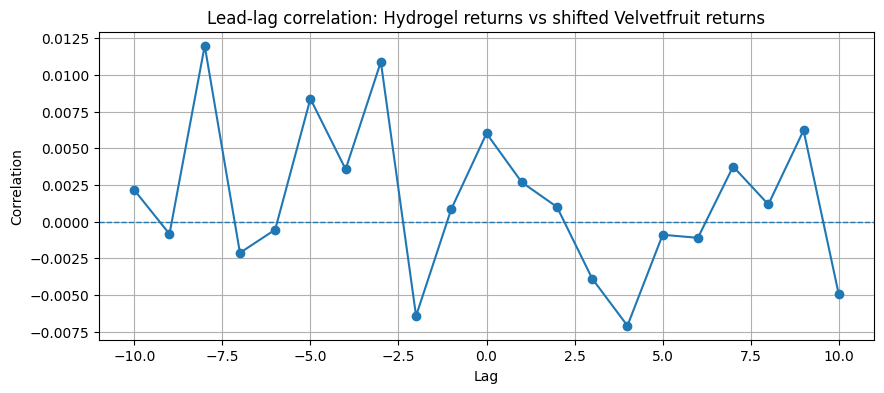

In [56]:
lead_lag_results = []

for lag in range(-10, 11):
    # lag > 0 means velvet return is shifted forward:
    # hydro_ret_t compared with velvet_ret_{t-lag}
    df = pair.copy()
    df["velvet_ret_shifted"] = df.groupby("day")["velvet_ret_1"].shift(lag)

    valid = df.dropna(subset=["hydro_ret_1", "velvet_ret_shifted"])

    corr = valid["hydro_ret_1"].corr(valid["velvet_ret_shifted"])

    lead_lag_results.append({
        "lag": lag,
        "corr_hydro_ret_vs_shifted_velvet_ret": corr,
    })

lead_lag_df = pd.DataFrame(lead_lag_results)

display(lead_lag_df)

plt.figure(figsize=(10, 4))
plt.plot(
    lead_lag_df["lag"],
    lead_lag_df["corr_hydro_ret_vs_shifted_velvet_ret"],
    marker="o",
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Lead-lag correlation: Hydrogel returns vs shifted Velvetfruit returns")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.show()

In [57]:
hydro_cross_results = []

for horizon in [1, 5, 10]:
    h_col = f"hydro_ret_{horizon}"
    v_col = f"velvet_ret_{horizon}"

    valid = pair.dropna(subset=[h_col, v_col])

    X = sm.add_constant(valid[v_col])
    y = valid[h_col]

    model = sm.OLS(y, X).fit()

    hydro_cross_results.append({
        "horizon": horizon,
        "beta_to_velvet": model.params[v_col],
        "r2": model.rsquared,
        "corr": valid[h_col].corr(valid[v_col]),
    })

hydro_cross_df = pd.DataFrame(hydro_cross_results)

display(hydro_cross_df)

,horizon,beta_to_velvet,r2,corr
0,1,0.011535,0.000036,0.006013
1,5,0.019359,0.000095,0.009769
2,10,0.038828,0.000382,0.019548


In [58]:
hydro_market_structure = hydrogel.groupby("product").agg(
    spread_mean=("spread", "mean"),
    spread_median=("spread", "median"),
    spread_min=("spread", "min"),
    spread_max=("spread", "max"),
    spread_std=("spread", "std"),
    best_bid_volume_mean=("best_bid_volume", "mean"),
    best_ask_volume_mean=("best_ask_volume", "mean"),
    total_book_volume_mean=("total_book_volume", "mean"),
)

display(hydro_market_structure)

,spread_mean,spread_median,spread_min,spread_max,spread_std,best_bid_volume_mean,best_ask_volume_mean,total_book_volume_mean
product,,,,,,,,
HYDROGEL_PACK,15.7208,16.0,7.0,17.0,1.455032,12.404233,12.395033,75.263667


In [59]:
hydro_imbalance_pred = []

tmp = pair.copy()
tmp["hydro_next_mid"] = tmp.groupby("day")["hydro_mid"].shift(-1)
tmp["hydro_next_return"] = tmp["hydro_next_mid"] - tmp["hydro_mid"]

valid = tmp.dropna(subset=["hydro_imbalance", "hydro_next_return"])

hydro_imbalance_pred.append({
    "corr_imbalance_next_return": valid["hydro_imbalance"].corr(valid["hydro_next_return"]),
    "avg_next_return_pos_imb": valid.loc[valid["hydro_imbalance"] > 0.01, "hydro_next_return"].mean(),
    "avg_next_return_neg_imb": valid.loc[valid["hydro_imbalance"] < -0.01, "hydro_next_return"].mean(),
    "count_pos_imb": (valid["hydro_imbalance"] > 0.01).sum(),
    "count_neg_imb": (valid["hydro_imbalance"] < -0.01).sum(),
})

hydro_imbalance_pred = pd.DataFrame(hydro_imbalance_pred)

display(hydro_imbalance_pred)

,corr_imbalance_next_return,avg_next_return_pos_imb,avg_next_return_neg_imb,count_pos_imb,count_neg_imb
0,-0.3268,-3.901899,4.149225,474,516


In [60]:
spread_dynamics = pair.copy()
spread_dynamics["hydro_abs_next_return"] = spread_dynamics.groupby("day")["hydro_mid"].shift(-1) - spread_dynamics["hydro_mid"]
spread_dynamics["hydro_abs_next_return"] = spread_dynamics["hydro_abs_next_return"].abs()

hydro_spread_relation = spread_dynamics.groupby("hydro_spread").agg(
    count=("hydro_spread", "count"),
    avg_next_abs_return=("hydro_abs_next_return", "mean"),
    avg_imbalance=("hydro_imbalance", "mean"),
)

display(hydro_spread_relation)

,count,avg_next_abs_return,avg_imbalance
hydro_spread,,,
7.0,275,4.272727,-0.084457
8.0,490,4.005102,0.001250
9.0,225,3.942222,0.087595
15.0,798,1.709273,0.000000
16.0,27820,1.576626,0.000000
17.0,392,1.735969,0.000000


In [61]:
hydro_summary = pd.DataFrame([
    {
        "metric": "mean_spread",
        "value": pair["hydro_spread"].mean(),
    },
    {
        "metric": "median_spread",
        "value": pair["hydro_spread"].median(),
    },
    {
        "metric": "ret_1_std",
        "value": pair["hydro_ret_1"].std(),
    },
    {
        "metric": "ret_1_mean",
        "value": pair["hydro_ret_1"].mean(),
    },
    {
        "metric": "directional_persistence",
        "value": hydro_persistence,
    },
    {
        "metric": "corr_with_velvet_level",
        "value": corr_levels,
    },
    {
        "metric": "corr_with_velvet_ret_1",
        "value": corr_ret_1,
    },
    {
        "metric": "corr_imbalance_next_return",
        "value": hydro_imbalance_pred["corr_imbalance_next_return"].iloc[0],
    },
])

display(hydro_summary)

,metric,value
0,mean_spread,15.720800
1,median_spread,16.000000
2,ret_1_std,2.169826
3,ret_1_mean,0.000467
4,directional_persistence,0.352233
5,corr_with_velvet_level,0.096727
6,corr_with_velvet_ret_1,0.006013
7,corr_imbalance_next_return,-0.326800


## Option basics sanity check

In [62]:
vouchers = [
    "VEV_4000", "VEV_4500", "VEV_5000", "VEV_5100", "VEV_5200",
    "VEV_5300", "VEV_5400", "VEV_5500", "VEV_6000", "VEV_6500"
]

underlying_name = "VELVETFRUIT_EXTRACT"

underlying = (
    prices[prices["product"] == underlying_name]
    [["day", "timestamp", "mid", "best_bid", "best_ask", "spread"]]
    .rename(columns={
        "mid": "underlying_mid",
        "best_bid": "underlying_bid",
        "best_ask": "underlying_ask",
        "spread": "underlying_spread",
    })
)

options = (
    prices[prices["product"].isin(vouchers)]
    .copy()
    .merge(underlying, on=["day", "timestamp"], how="left")
)

options["strike"] = options["product"].str.split("_").str[-1].astype(int)

options = options.sort_values(["day", "timestamp", "strike"])

options["intrinsic"] = np.maximum(options["underlying_mid"] - options["strike"], 0)
options["time_value"] = options["mid"] - options["intrinsic"]
options["moneyness"] = options["underlying_mid"] / options["strike"]
options["log_moneyness"] = np.log(options["underlying_mid"] / options["strike"])

display(options.head())

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,best_ask_volume,underlying_mid,underlying_bid,underlying_ask,underlying_spread,strike,intrinsic,time_value,moneyness,log_moneyness
7,0,0,VEV_4000,1240,7,1237.0,24.0,NaN,NaN,1260,...,7.0,5250.0,5247.0,5253.0,6.0,4000,1250.0,0.0,1.312500,0.271934
5,0,0,VEV_4500,742,6,740.0,13.0,NaN,NaN,758,...,6.0,5250.0,5247.0,5253.0,6.0,4500,750.0,0.0,1.166667,0.154151
6,0,0,VEV_5000,254,19,NaN,NaN,NaN,NaN,260,...,6.0,5250.0,5247.0,5253.0,6.0,5000,250.0,7.0,1.050000,0.048790
8,0,0,VEV_5100,169,19,NaN,NaN,NaN,NaN,174,...,19.0,5250.0,5247.0,5253.0,6.0,5100,150.0,21.5,1.029412,0.028988
3,0,0,VEV_5200,100,19,NaN,NaN,NaN,NaN,103,...,6.0,5250.0,5247.0,5253.0,6.0,5200,50.0,51.5,1.009615,0.009569


In [63]:
option_basic_summary = options.groupby(["product", "strike"]).agg(
    mid_mean=("mid", "mean"),
    mid_median=("mid", "median"),
    mid_min=("mid", "min"),
    mid_max=("mid", "max"),
    mid_std=("mid", "std"),
    spread_mean=("spread", "mean"),
    spread_median=("spread", "median"),
    intrinsic_mean=("intrinsic", "mean"),
    intrinsic_min=("intrinsic", "min"),
    intrinsic_max=("intrinsic", "max"),
    time_value_mean=("time_value", "mean"),
    time_value_min=("time_value", "min"),
    time_value_max=("time_value", "max"),
    moneyness_mean=("moneyness", "mean"),
).reset_index().sort_values("strike")

display(option_basic_summary)

,product,strike,mid_mean,mid_median,mid_min,mid_max,mid_std,spread_mean,spread_median,intrinsic_mean,intrinsic_min,intrinsic_max,time_value_mean,time_value_min,time_value_max,moneyness_mean
0,VEV_4000,4000,1250.109800,1249.5,1198.0,1300.0,15.647243,20.813467,21.0,1250.098100,1198.0,1300.0,0.011700,-7.0,7.0,1.312525
1,VEV_4500,4500,750.109567,749.0,698.5,799.5,15.639930,15.852667,16.0,750.098100,698.0,800.0,0.011467,-6.0,5.5,1.166688
2,VEV_5000,5000,255.022400,254.0,206.5,300.5,14.375586,6.043333,6.0,250.098100,198.0,300.0,4.924300,-0.5,11.5,1.050020
3,VEV_5100,5100,166.805450,166.5,125.0,205.5,12.742624,4.295833,4.0,150.098100,98.0,200.0,16.707350,4.5,29.5,1.029431
4,VEV_5200,5200,95.548767,96.0,64.0,122.5,9.664218,2.888133,3.0,50.098383,0.0,100.0,45.450383,21.5,67.5,1.009634
5,VEV_5300,5300,46.759933,47.0,26.5,65.5,6.228141,2.106800,2.0,0.000000,0.0,0.0,46.759933,26.5,65.5,0.990585
6,VEV_5400,5400,15.951917,16.5,6.5,27.0,3.429182,1.381433,1.0,0.000000,0.0,0.0,15.951917,6.5,27.0,0.972240
7,VEV_5500,5500,6.641350,6.5,2.5,12.5,1.738849,1.149767,1.0,0.000000,0.0,0.0,6.641350,2.5,12.5,0.954563
8,VEV_6000,6000,0.500000,0.5,0.5,0.5,0.000000,1.000000,1.0,0.000000,0.0,0.0,0.500000,0.5,0.5,0.875016
9,VEV_6500,6500,0.500000,0.5,0.5,0.5,0.000000,1.000000,1.0,0.000000,0.0,0.0,0.500000,0.5,0.5,0.807707


In [64]:
option_value_sanity = options.groupby(["product", "strike"]).agg(
    frac_intrinsic_positive=("intrinsic", lambda x: (x > 0).mean()),
    frac_time_value_negative=("time_value", lambda x: (x < 0).mean()),
    avg_negative_time_value=("time_value", lambda x: x[x < 0].mean() if (x < 0).any() else np.nan),
    min_time_value=("time_value", "min"),
    max_time_value=("time_value", "max"),
).reset_index().sort_values("strike")

display(option_value_sanity)

,product,strike,frac_intrinsic_positive,frac_time_value_negative,avg_negative_time_value,min_time_value,max_time_value
0,VEV_4000,4000,1.000000,0.099533,-1.208305,-7.0,7.0
1,VEV_4500,4500,1.000000,0.293733,-0.700522,-6.0,5.5
2,VEV_5000,5000,1.000000,0.000100,-0.500000,-0.5,11.5
3,VEV_5100,5100,1.000000,0.000000,NaN,4.5,29.5
4,VEV_5200,5200,0.999567,0.000000,NaN,21.5,67.5
5,VEV_5300,5300,0.000000,0.000000,NaN,26.5,65.5
6,VEV_5400,5400,0.000000,0.000000,NaN,6.5,27.0
7,VEV_5500,5500,0.000000,0.000000,NaN,2.5,12.5
8,VEV_6000,6000,0.000000,0.000000,NaN,0.5,0.5
9,VEV_6500,6500,0.000000,0.000000,NaN,0.5,0.5


In [65]:
option_ladder = options.pivot_table(
    index=["day", "timestamp"],
    columns="strike",
    values="mid"
).sort_index()

display(option_ladder.head())

strike           4000   4500   5000   5100   5200  5300  5400  5500  6000  \
day timestamp                                                               
0   0          1250.0  750.0  257.0  171.5  101.5  53.0  23.0   8.5   0.5   
    100        1250.5  751.0  258.0  172.0  102.5  53.0  23.5   8.5   0.5   
    200        1250.5  750.0  257.0  172.0  102.5  53.0  23.5   8.5   0.5   
    300        1250.5  750.0  257.5  172.0  102.5  53.0  23.5   8.5   0.5   
    400        1250.5  750.0  257.0  172.0  102.5  53.0  23.5   8.5   0.5   

strike         6500  
day timestamp        
0   0           0.5  
    100         0.5  
    200         0.5  
    300         0.5  
    400         0.5

In [66]:
strikes = sorted(options["strike"].unique())

monotonicity_rows = []

for i in range(len(strikes) - 1):
    k_low = strikes[i]
    k_high = strikes[i + 1]

    diff = option_ladder[k_low] - option_ladder[k_high]

    monotonicity_rows.append({
        "lower_strike": k_low,
        "higher_strike": k_high,
        "mean_price_diff": diff.mean(),
        "min_price_diff": diff.min(),
        "max_price_diff": diff.max(),
        "frac_violation": (diff < 0).mean(),
        "num_violation": int((diff < 0).sum()),
    })

monotonicity_check = pd.DataFrame(monotonicity_rows)

display(monotonicity_check)

,lower_strike,higher_strike,mean_price_diff,min_price_diff,max_price_diff,frac_violation,num_violation
0,4000,4500,500.000233,498.5,501.5,0.0,0
1,4500,5000,495.087167,488.0,501.0,0.0,0
2,5000,5100,88.216950,81.0,96.0,0.0,0
3,5100,5200,71.256683,58.5,83.5,0.0,0
4,5200,5300,48.788833,36.0,62.5,0.0,0
5,5300,5400,30.808017,20.0,39.5,0.0,0
6,5400,5500,9.310567,4.0,15.5,0.0,0
7,5500,6000,6.141350,2.0,12.0,0.0,0
8,6000,6500,0.000000,0.0,0.0,0.0,0


In [67]:
call_spread_rows = []

for i in range(len(strikes) - 1):
    k_low = strikes[i]
    k_high = strikes[i + 1]

    price_diff = option_ladder[k_low] - option_ladder[k_high]
    strike_diff = k_high - k_low

    violation = price_diff > strike_diff

    call_spread_rows.append({
        "lower_strike": k_low,
        "higher_strike": k_high,
        "strike_diff": strike_diff,
        "mean_price_diff": price_diff.mean(),
        "max_price_diff": price_diff.max(),
        "frac_upper_bound_violation": violation.mean(),
        "num_upper_bound_violation": int(violation.sum()),
        "mean_excess_when_violated": (price_diff[violation] - strike_diff).mean() if violation.any() else np.nan,
    })

call_spread_check = pd.DataFrame(call_spread_rows)

display(call_spread_check)

,lower_strike,higher_strike,strike_diff,mean_price_diff,max_price_diff,frac_upper_bound_violation,num_upper_bound_violation,mean_excess_when_violated
0,4000,4500,500,500.000233,501.5,0.2850,8550,0.523626
1,4500,5000,500,495.087167,501.0,0.0004,12,0.583333
2,5000,5100,100,88.216950,96.0,0.0000,0,NaN
3,5100,5200,100,71.256683,83.5,0.0000,0,NaN
4,5200,5300,100,48.788833,62.5,0.0000,0,NaN
5,5300,5400,100,30.808017,39.5,0.0000,0,NaN
6,5400,5500,100,9.310567,15.5,0.0000,0,NaN
7,5500,6000,500,6.141350,12.0,0.0000,0,NaN
8,6000,6500,500,0.000000,0.0,0.0000,0,NaN


In [68]:
intrinsic_violation = options.copy()
intrinsic_violation["below_intrinsic"] = intrinsic_violation["mid"] < intrinsic_violation["intrinsic"]
intrinsic_violation["intrinsic_gap"] = intrinsic_violation["intrinsic"] - intrinsic_violation["mid"]

intrinsic_violation_summary = intrinsic_violation.groupby(["product", "strike"]).agg(
    frac_below_intrinsic=("below_intrinsic", "mean"),
    max_intrinsic_gap=("intrinsic_gap", "max"),
    mean_intrinsic_gap_when_below=(
        "intrinsic_gap",
        lambda x: x[x > 0].mean() if (x > 0).any() else np.nan
    ),
).reset_index().sort_values("strike")

display(intrinsic_violation_summary)

,product,strike,frac_below_intrinsic,max_intrinsic_gap,mean_intrinsic_gap_when_below
0,VEV_4000,4000,0.099533,7.0,1.208305
1,VEV_4500,4500,0.293733,6.0,0.700522
2,VEV_5000,5000,0.000100,0.5,0.500000
3,VEV_5100,5100,0.000000,-4.5,NaN
4,VEV_5200,5200,0.000000,-21.5,NaN
5,VEV_5300,5300,0.000000,-26.5,NaN
6,VEV_5400,5400,0.000000,-6.5,NaN
7,VEV_5500,5500,0.000000,-2.5,NaN
8,VEV_6000,6000,0.000000,-0.5,NaN
9,VEV_6500,6500,0.000000,-0.5,NaN


In [69]:
time_value_by_day = options.groupby(["day", "product", "strike"]).agg(
    time_value_mean=("time_value", "mean"),
    time_value_median=("time_value", "median"),
    time_value_min=("time_value", "min"),
    time_value_max=("time_value", "max"),
).reset_index().sort_values(["day", "strike"])

display(time_value_by_day)

,day,product,strike,time_value_mean,time_value_median,time_value_min,time_value_max
0,0,VEV_4000,4000,0.01385,0.0,-6.5,6.5
1,0,VEV_4500,4500,0.01135,0.0,-5.5,5.5
2,0,VEV_5000,5000,6.74925,6.5,2.5,11.5
3,0,VEV_5100,5100,21.59745,21.5,13.0,29.5
4,0,VEV_5200,5200,50.96065,51.5,36.0,64.5
5,0,VEV_5300,5300,48.89250,48.0,38.0,65.5
6,0,VEV_5400,5400,18.46725,18.0,11.5,27.0
7,0,VEV_5500,5500,8.05895,7.5,5.5,12.5
8,0,VEV_6000,6000,0.50000,0.5,0.5,0.5
9,0,VEV_6500,6500,0.50000,0.5,0.5,0.5


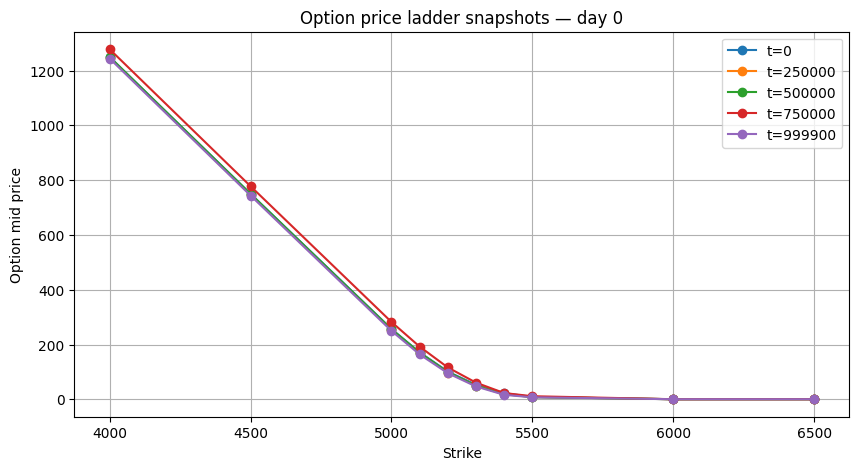

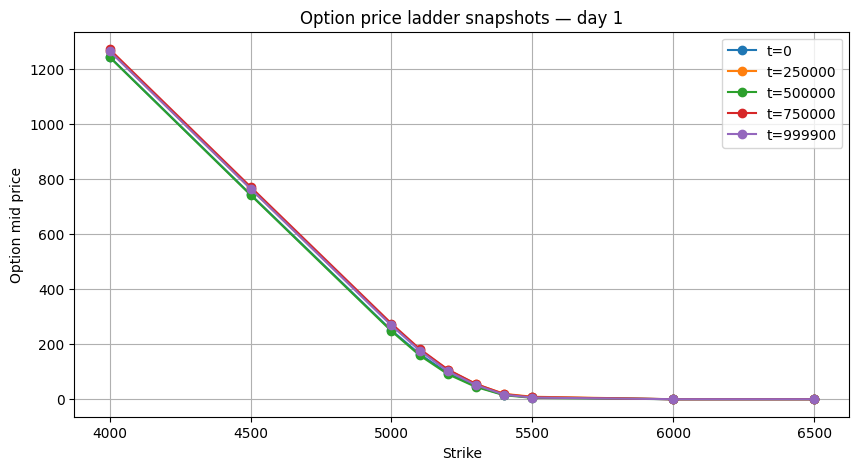

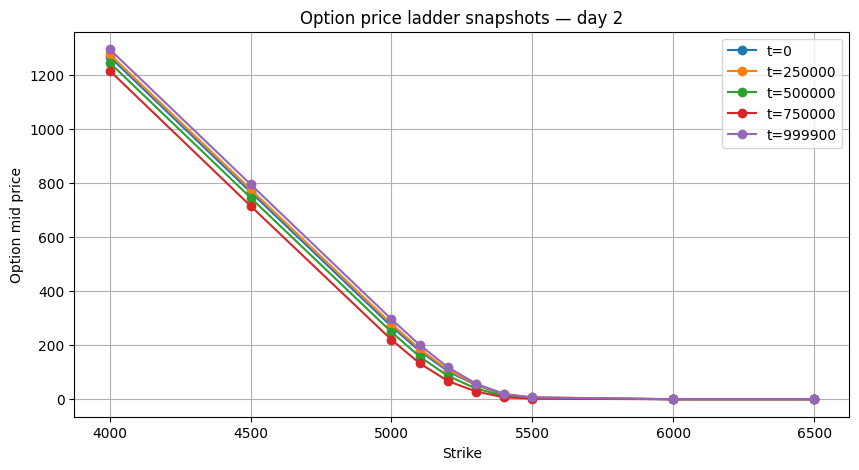

In [70]:
sample_times = [0, 250000, 500000, 750000, 999900]

for day in sorted(options["day"].unique()):
    plt.figure(figsize=(10, 5))

    for ts in sample_times:
        df = options[(options["day"] == day) & (options["timestamp"] == ts)]
        if df.empty:
            continue

        plt.plot(df["strike"], df["mid"], marker="o", label=f"t={ts}")

    plt.title(f"Option price ladder snapshots — day {day}")
    plt.xlabel("Strike")
    plt.ylabel("Option mid price")
    plt.legend()
    plt.show()

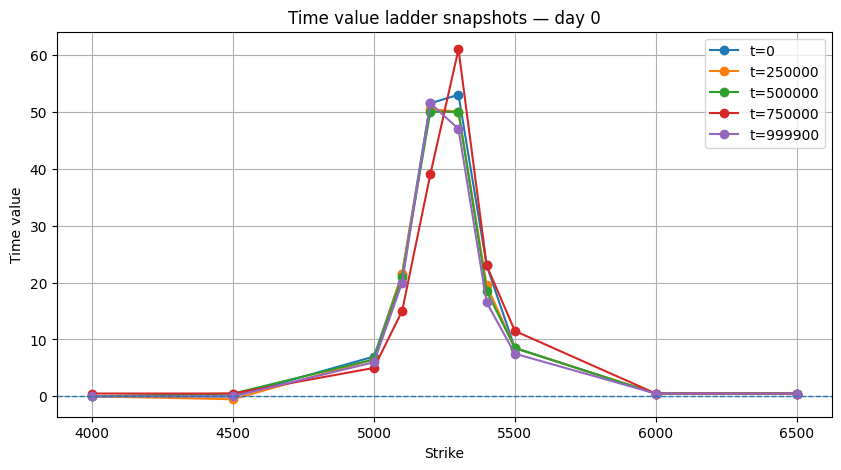

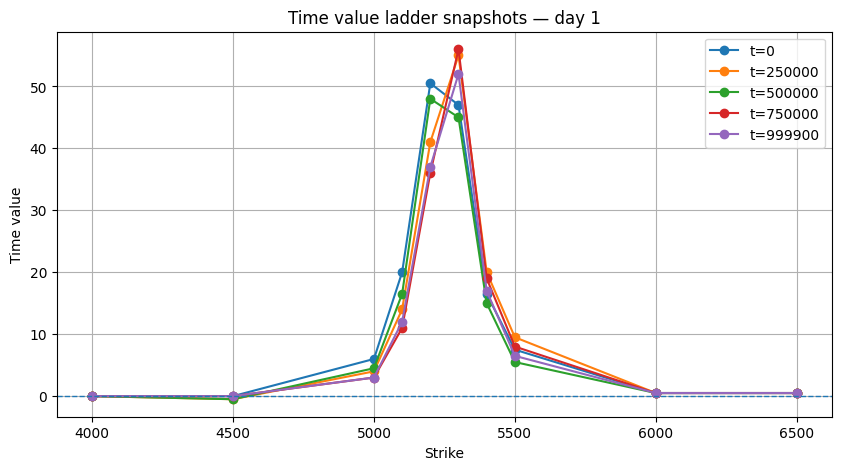

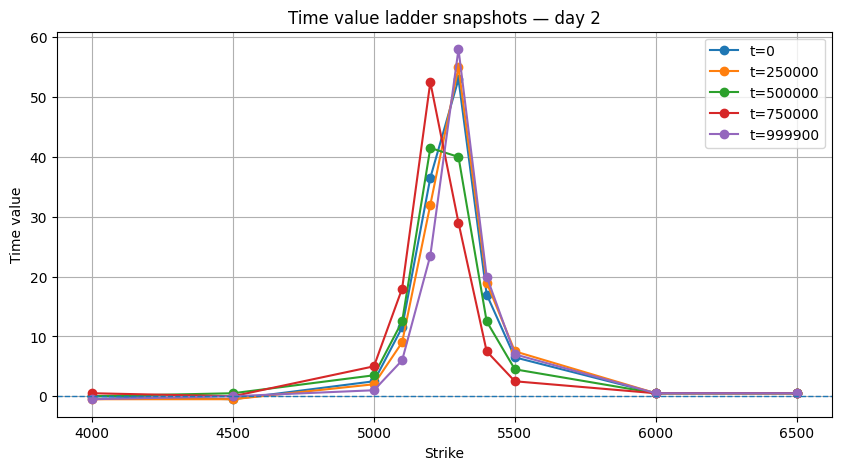

In [71]:
for day in sorted(options["day"].unique()):
    plt.figure(figsize=(10, 5))

    for ts in sample_times:
        df = options[(options["day"] == day) & (options["timestamp"] == ts)]
        if df.empty:
            continue

        plt.plot(df["strike"], df["time_value"], marker="o", label=f"t={ts}")

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"Time value ladder snapshots — day {day}")
    plt.xlabel("Strike")
    plt.ylabel("Time value")
    plt.legend()
    plt.show()

strike,4000,4500,5000,5100,5200,5300,5400,5500,6000,6500
strike,,,,,,,,,,
4000,1.000000,0.913051,0.818631,0.784945,0.713617,0.589106,0.478796,0.298166,NaN,NaN
4500,0.913051,1.000000,0.864393,0.839146,0.767594,0.644094,0.529452,0.332908,NaN,NaN
5000,0.818631,0.864393,1.000000,0.901124,0.834460,0.716074,0.606616,0.386410,NaN,NaN
5100,0.784945,0.839146,0.901124,1.000000,0.833795,0.715018,0.607507,0.386259,NaN,NaN
5200,0.713617,0.767594,0.834460,0.833795,1.000000,0.668446,0.572827,0.369297,NaN,NaN
5300,0.589106,0.644094,0.716074,0.715018,0.668446,1.000000,0.490095,0.325807,NaN,NaN
5400,0.478796,0.529452,0.606616,0.607507,0.572827,0.490095,1.000000,0.295046,NaN,NaN
5500,0.298166,0.332908,0.386410,0.386259,0.369297,0.325807,0.295046,1.000000,NaN,NaN
6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


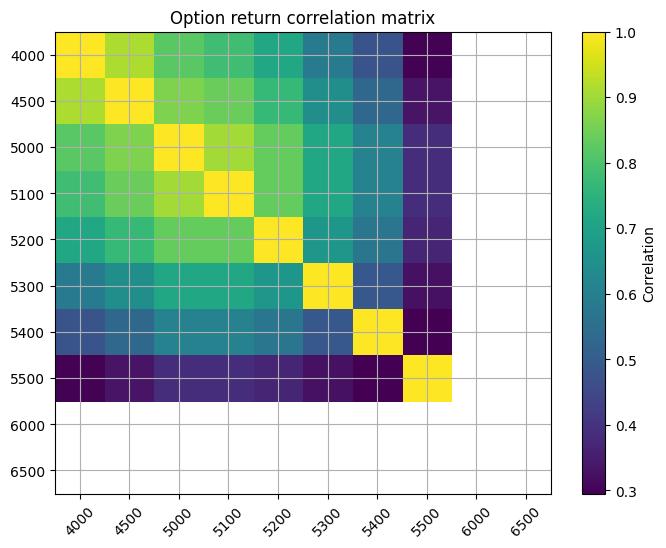

In [72]:
option_returns = option_ladder.groupby(level=0).diff()

option_return_corr = option_returns.corr()

display(option_return_corr)

plt.figure(figsize=(8, 6))
plt.imshow(option_return_corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(option_return_corr.columns)), option_return_corr.columns, rotation=45)
plt.yticks(range(len(option_return_corr.index)), option_return_corr.index)
plt.title("Option return correlation matrix")
plt.show()

In [73]:
option_beta_rows = []

for day in sorted(options["day"].unique()):
    day_options = options[options["day"] == day]

    for product, df in day_options.groupby("product"):
        strike = df["strike"].iloc[0]

        valid = df[["mid", "underlying_mid"]].dropna()

        if valid["mid"].std() == 0:
            corr = np.nan
            beta = 0.0
        else:
            corr = valid["mid"].corr(valid["underlying_mid"])
            beta = np.polyfit(valid["underlying_mid"], valid["mid"], 1)[0]

        option_beta_rows.append({
            "day": day,
            "product": product,
            "strike": strike,
            "corr_with_underlying": corr,
            "beta_to_underlying": beta,
            "mid_std": valid["mid"].std(),
        })

option_beta_by_day = pd.DataFrame(option_beta_rows).sort_values(["day", "strike"])

display(option_beta_by_day)

,day,product,strike,corr_with_underlying,beta_to_underlying,mid_std
0,0,VEV_4000,4000,0.998222,0.999704,13.698111
1,0,VEV_4500,4500,0.998486,0.999132,13.686640
2,0,VEV_5000,5000,0.998789,0.911968,12.488839
3,0,VEV_5100,5100,0.997097,0.798592,10.954784
4,0,VEV_5200,5200,0.992631,0.592602,8.165664
5,0,VEV_5300,5300,0.979439,0.370926,5.179954
6,0,VEV_5400,5400,0.758904,0.154287,2.780724
7,0,VEV_5500,5500,0.961871,0.086983,1.236892
8,0,VEV_6000,6000,NaN,0.000000,0.000000
9,0,VEV_6500,6500,NaN,0.000000,0.000000


In [74]:
dead_option_summary = options.groupby(["product", "strike"]).agg(
    mid_min=("mid", "min"),
    mid_max=("mid", "max"),
    mid_std=("mid", "std"),
    spread_mean=("spread", "mean"),
    frac_mid_constant=("mid", lambda x: x.nunique() == 1),
    num_unique_mid=("mid", "nunique"),
).reset_index().sort_values("strike")

display(dead_option_summary)

,product,strike,mid_min,mid_max,mid_std,spread_mean,frac_mid_constant,num_unique_mid
0,VEV_4000,4000,1198.0,1300.0,15.647243,20.813467,False,196
1,VEV_4500,4500,698.5,799.5,15.639930,15.852667,False,190
2,VEV_5000,5000,206.5,300.5,14.375586,6.043333,False,178
3,VEV_5100,5100,125.0,205.5,12.742624,4.295833,False,156
4,VEV_5200,5200,64.0,122.5,9.664218,2.888133,False,118
5,VEV_5300,5300,26.5,65.5,6.228141,2.106800,False,79
6,VEV_5400,5400,6.5,27.0,3.429182,1.381433,False,42
7,VEV_5500,5500,2.5,12.5,1.738849,1.149767,False,21
8,VEV_6000,6000,0.5,0.5,0.000000,1.000000,True,1
9,VEV_6500,6500,0.5,0.5,0.000000,1.000000,True,1


In [75]:
option_decision_table = (
    option_basic_summary[
        [
            "product", "strike", "mid_mean", "mid_std", "spread_mean",
            "intrinsic_mean", "time_value_mean", "time_value_min", "time_value_max",
            "moneyness_mean"
        ]
    ]
    .merge(
        option_value_sanity[
            ["product", "strike", "frac_intrinsic_positive", "frac_time_value_negative"]
        ],
        on=["product", "strike"],
        how="left"
    )
    .merge(
        dead_option_summary[
            ["product", "strike", "num_unique_mid", "frac_mid_constant"]
        ],
        on=["product", "strike"],
        how="left"
    )
    .sort_values("strike")
)

display(option_decision_table)

,product,strike,mid_mean,mid_std,spread_mean,intrinsic_mean,time_value_mean,time_value_min,time_value_max,moneyness_mean,frac_intrinsic_positive,frac_time_value_negative,num_unique_mid,frac_mid_constant
0,VEV_4000,4000,1250.109800,15.647243,20.813467,1250.098100,0.011700,-7.0,7.0,1.312525,1.000000,0.099533,196,False
1,VEV_4500,4500,750.109567,15.639930,15.852667,750.098100,0.011467,-6.0,5.5,1.166688,1.000000,0.293733,190,False
2,VEV_5000,5000,255.022400,14.375586,6.043333,250.098100,4.924300,-0.5,11.5,1.050020,1.000000,0.000100,178,False
3,VEV_5100,5100,166.805450,12.742624,4.295833,150.098100,16.707350,4.5,29.5,1.029431,1.000000,0.000000,156,False
4,VEV_5200,5200,95.548767,9.664218,2.888133,50.098383,45.450383,21.5,67.5,1.009634,0.999567,0.000000,118,False
5,VEV_5300,5300,46.759933,6.228141,2.106800,0.000000,46.759933,26.5,65.5,0.990585,0.000000,0.000000,79,False
6,VEV_5400,5400,15.951917,3.429182,1.381433,0.000000,15.951917,6.5,27.0,0.972240,0.000000,0.000000,42,False
7,VEV_5500,5500,6.641350,1.738849,1.149767,0.000000,6.641350,2.5,12.5,0.954563,0.000000,0.000000,21,False
8,VEV_6000,6000,0.500000,0.000000,1.000000,0.000000,0.500000,0.5,0.5,0.875016,0.000000,0.000000,1,True
9,VEV_6500,6500,0.500000,0.000000,1.000000,0.000000,0.500000,0.5,0.5,0.807707,0.000000,0.000000,1,True


## Implied volatility analysis

In [76]:
from statistics import NormalDist
import math

_N = NormalDist()

DAYS_PER_YEAR = 365
RISK_FREE_RATE = 0.0

# Historical data TTE:
# day 0 -> 8 days
# day 1 -> 7 days
# day 2 -> 6 days
TTE_BY_DAY = {
    0: 8,
    1: 7,
    2: 6,
}

def norm_cdf(x):
    return _N.cdf(x)

def black_scholes_call(S, K, T, r, sigma):
    if S <= 0 or K <= 0 or T <= 0 or sigma <= 0:
        return np.nan

    d1 = (math.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)

    return S * norm_cdf(d1) - K * math.exp(-r * T) * norm_cdf(d2)

def implied_vol_call(price, S, K, T, r=0.0, low=1e-6, high=5.0, tol=1e-6, max_iter=80):
    """
    Bisection IV solver for call options.
    Returns np.nan if price is outside sensible no-arbitrage bounds.
    """
    if pd.isna(price) or pd.isna(S) or pd.isna(K) or pd.isna(T):
        return np.nan

    if price <= 0 or S <= 0 or K <= 0 or T <= 0:
        return np.nan

    intrinsic = max(S - K * math.exp(-r * T), 0)

    # Mid prices can be slightly below intrinsic because of spreads/discreteness.
    if price < intrinsic - 1e-9:
        return np.nan

    # Upper bound for a call is S.
    if price > S:
        return np.nan

    low_price = black_scholes_call(S, K, T, r, low)
    high_price = black_scholes_call(S, K, T, r, high)

    if pd.isna(low_price) or pd.isna(high_price):
        return np.nan

    if price < low_price - 1e-9 or price > high_price + 1e-9:
        return np.nan

    lo, hi = low, high

    for _ in range(max_iter):
        mid_sigma = (lo + hi) / 2
        mid_price = black_scholes_call(S, K, T, r, mid_sigma)

        if abs(mid_price - price) < tol:
            return mid_sigma

        if mid_price < price:
            lo = mid_sigma
        else:
            hi = mid_sigma

    return (lo + hi) / 2

In [77]:
iv_df = options.copy()

iv_df["tte_days"] = iv_df["day"].map(TTE_BY_DAY)
iv_df["T"] = iv_df["tte_days"] / DAYS_PER_YEAR

# Use mid IV first
iv_df["iv_mid"] = iv_df.apply(
    lambda r: implied_vol_call(
        price=r["mid"],
        S=r["underlying_mid"],
        K=r["strike"],
        T=r["T"],
        r=RISK_FREE_RATE,
    ),
    axis=1,
)

# Also compute bid/ask IV range to measure uncertainty from spreads
iv_df["iv_bid"] = iv_df.apply(
    lambda r: implied_vol_call(
        price=r["best_bid"],
        S=r["underlying_mid"],
        K=r["strike"],
        T=r["T"],
        r=RISK_FREE_RATE,
    ),
    axis=1,
)

iv_df["iv_ask"] = iv_df.apply(
    lambda r: implied_vol_call(
        price=r["best_ask"],
        S=r["underlying_mid"],
        K=r["strike"],
        T=r["T"],
        r=RISK_FREE_RATE,
    ),
    axis=1,
)

iv_df["iv_spread"] = iv_df["iv_ask"] - iv_df["iv_bid"]

display(iv_df[[
    "day", "timestamp", "product", "strike", "underlying_mid",
    "mid", "intrinsic", "time_value", "tte_days", "iv_mid", "iv_bid", "iv_ask", "iv_spread"
]].head())

,day,timestamp,product,strike,underlying_mid,mid,intrinsic,time_value,tte_days,iv_mid,iv_bid,iv_ask,iv_spread
7,0,0,VEV_4000,4000,5250.0,1250.0,1250.0,0.0,8,0.312501,NaN,1.023031,NaN
5,0,0,VEV_4500,4500,5250.0,750.0,750.0,0.0,8,0.156251,NaN,0.611689,NaN
6,0,0,VEV_5000,5000,5250.0,257.0,250.0,7.0,8,0.239329,0.210249,0.262815,0.052566
8,0,0,VEV_5100,5100,5250.0,171.5,150.0,21.5,8,0.240052,0.228448,0.251294,0.022846
3,0,0,VEV_5200,5200,5250.0,101.5,50.0,51.5,8,0.239229,0.234182,0.244267,0.010085


In [78]:
iv_coverage = iv_df.groupby(["product", "strike"]).agg(
    rows=("iv_mid", "size"),
    valid_iv_frac=("iv_mid", lambda x: x.notna().mean()),
    valid_bid_iv_frac=("iv_bid", lambda x: x.notna().mean()),
    valid_ask_iv_frac=("iv_ask", lambda x: x.notna().mean()),
    mean_time_value=("time_value", "mean"),
    min_time_value=("time_value", "min"),
    mean_spread=("spread", "mean"),
    mid_std=("mid", "std"),
).reset_index().sort_values("strike")

display(iv_coverage)

,product,strike,rows,valid_iv_frac,valid_bid_iv_frac,valid_ask_iv_frac,mean_time_value,min_time_value,mean_spread,mid_std
0,VEV_4000,4000,30000,0.900467,0.001067,0.992033,0.011700,-7.0,20.813467,15.647243
1,VEV_4500,4500,30000,0.706267,0.001067,0.992033,0.011467,-6.0,15.852667,15.639930
2,VEV_5000,5000,30000,0.999900,0.815133,1.000000,4.924300,-0.5,6.043333,14.375586
3,VEV_5100,5100,30000,1.000000,1.000000,1.000000,16.707350,4.5,4.295833,12.742624
4,VEV_5200,5200,30000,1.000000,1.000000,1.000000,45.450383,21.5,2.888133,9.664218
5,VEV_5300,5300,30000,1.000000,1.000000,1.000000,46.759933,26.5,2.106800,6.228141
6,VEV_5400,5400,30000,1.000000,1.000000,1.000000,15.951917,6.5,1.381433,3.429182
7,VEV_5500,5500,30000,1.000000,1.000000,1.000000,6.641350,2.5,1.149767,1.738849
8,VEV_6000,6000,30000,1.000000,0.000000,1.000000,0.500000,0.5,1.000000,0.000000
9,VEV_6500,6500,30000,1.000000,0.000000,1.000000,0.500000,0.5,1.000000,0.000000


In [79]:
iv_coverage = iv_df.groupby(["product", "strike"]).agg(
    rows=("iv_mid", "size"),
    valid_iv_frac=("iv_mid", lambda x: x.notna().mean()),
    valid_bid_iv_frac=("iv_bid", lambda x: x.notna().mean()),
    valid_ask_iv_frac=("iv_ask", lambda x: x.notna().mean()),
    mean_time_value=("time_value", "mean"),
    min_time_value=("time_value", "min"),
    mean_spread=("spread", "mean"),
    mid_std=("mid", "std"),
).reset_index().sort_values("strike")

display(iv_coverage)

,product,strike,rows,valid_iv_frac,valid_bid_iv_frac,valid_ask_iv_frac,mean_time_value,min_time_value,mean_spread,mid_std
0,VEV_4000,4000,30000,0.900467,0.001067,0.992033,0.011700,-7.0,20.813467,15.647243
1,VEV_4500,4500,30000,0.706267,0.001067,0.992033,0.011467,-6.0,15.852667,15.639930
2,VEV_5000,5000,30000,0.999900,0.815133,1.000000,4.924300,-0.5,6.043333,14.375586
3,VEV_5100,5100,30000,1.000000,1.000000,1.000000,16.707350,4.5,4.295833,12.742624
4,VEV_5200,5200,30000,1.000000,1.000000,1.000000,45.450383,21.5,2.888133,9.664218
5,VEV_5300,5300,30000,1.000000,1.000000,1.000000,46.759933,26.5,2.106800,6.228141
6,VEV_5400,5400,30000,1.000000,1.000000,1.000000,15.951917,6.5,1.381433,3.429182
7,VEV_5500,5500,30000,1.000000,1.000000,1.000000,6.641350,2.5,1.149767,1.738849
8,VEV_6000,6000,30000,1.000000,0.000000,1.000000,0.500000,0.5,1.000000,0.000000
9,VEV_6500,6500,30000,1.000000,0.000000,1.000000,0.500000,0.5,1.000000,0.000000


In [80]:
iv_by_day = iv_df.groupby(["day", "product", "strike"]).agg(
    iv_mean=("iv_mid", "mean"),
    iv_median=("iv_mid", "median"),
    iv_std=("iv_mid", "std"),
    valid_iv_frac=("iv_mid", lambda x: x.notna().mean()),
    iv_spread_mean=("iv_spread", "mean"),
).reset_index().sort_values(["day", "strike"])

display(iv_by_day)

,day,product,strike,iv_mean,iv_median,iv_std,valid_iv_frac,iv_spread_mean
0,0,VEV_4000,4000,0.358126,0.312501,0.133401,0.9061,0.618336
1,0,VEV_4500,4500,0.269336,0.156251,0.130832,0.6955,0.388091
2,0,VEV_5000,5000,0.233862,0.233803,0.005344,1.0000,0.055464
3,0,VEV_5100,5100,0.236595,0.236624,0.003642,1.0000,0.019783
4,0,VEV_5200,5200,0.232176,0.232747,0.003271,1.0000,0.009852
5,0,VEV_5300,5300,0.232218,0.232137,0.003556,1.0000,0.007260
6,0,VEV_5400,5400,0.222101,0.219106,0.008930,1.0000,0.006700
7,0,VEV_5500,5500,0.238458,0.238256,0.002662,1.0000,0.009147
8,0,VEV_6000,6000,0.354992,0.355898,0.006183,1.0000,NaN
9,0,VEV_6500,6500,0.536975,0.537843,0.005938,1.0000,NaN


In [92]:
# Clean IV universe for meaningful smile analysis

ACTIVE_IV_STRIKES = [5000, 5100, 5200, 5300, 5400, 5500]

iv_clean = iv_df.copy()

iv_clean = iv_clean[
    iv_clean["strike"].isin(ACTIVE_IV_STRIKES)
    & iv_clean["iv_mid"].notna()
    & np.isfinite(iv_clean["iv_mid"])
    & (iv_clean["iv_mid"] > 0)
    & (iv_clean["iv_mid"] < 2.0)
].copy()

# Remove observations with suspicious / near-degenerate option value
iv_clean = iv_clean[
    iv_clean["time_value"] > 0.25
].copy()

display(
    iv_clean.groupby(["product", "strike"]).agg(
        rows=("iv_mid", "size"),
        iv_mean=("iv_mid", "mean"),
        iv_median=("iv_mid", "median"),
        iv_std=("iv_mid", "std"),
        time_value_mean=("time_value", "mean"),
        spread_mean=("spread", "mean"),
    ).reset_index().sort_values("strike")
)

,product,strike,rows,iv_mean,iv_median,iv_std,time_value_mean,spread_mean
0,VEV_5000,5000,29976,0.232992,0.232910,0.008379,4.928293,6.045370
1,VEV_5100,5100,30000,0.230764,0.232246,0.007564,16.707350,4.295833
2,VEV_5200,5200,30000,0.233332,0.233350,0.006217,45.450383,2.888133
3,VEV_5300,5300,30000,0.235847,0.235269,0.005546,46.759933,2.106800
4,VEV_5400,5400,30000,0.221118,0.221337,0.007121,15.951917,1.381433
5,VEV_5500,5500,30000,0.239836,0.239267,0.006247,6.641350,1.149767


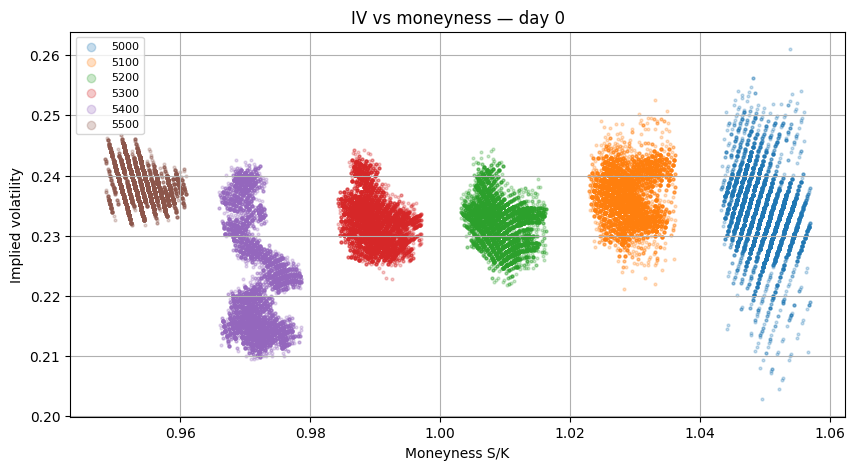

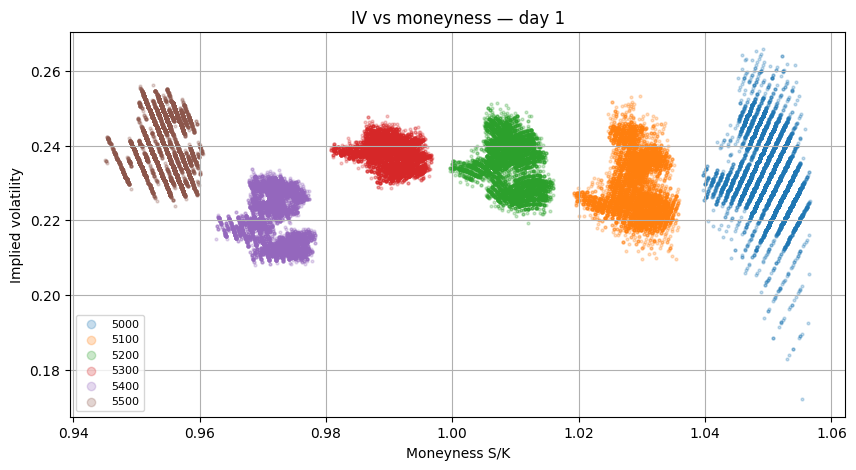

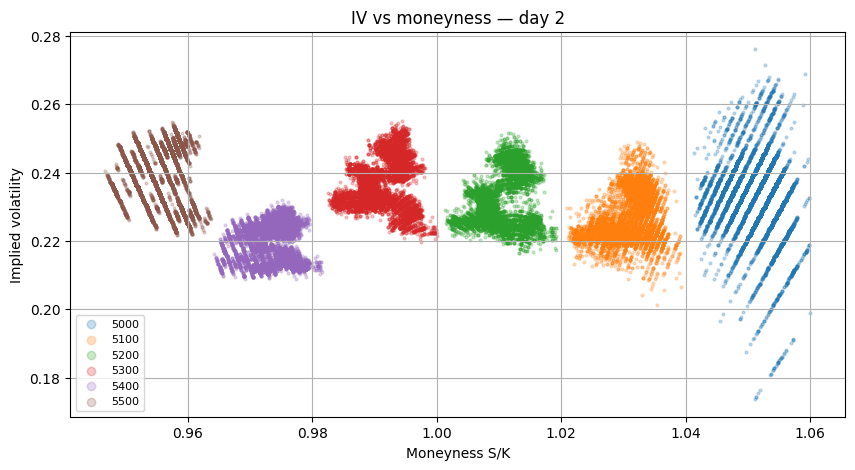

In [93]:
for day in sorted(iv_clean["day"].unique()):
    df = iv_clean[iv_clean["day"] == day]

    plt.figure(figsize=(10, 5))

    for strike in sorted(df["strike"].unique()):
        sdf = df[df["strike"] == strike]
        plt.scatter(
            sdf["moneyness"],
            sdf["iv_mid"],
            s=4,
            alpha=0.25,
            label=strike,
        )

    plt.title(f"IV vs moneyness — day {day}")
    plt.xlabel("Moneyness S/K")
    plt.ylabel("Implied volatility")
    plt.legend(markerscale=3, fontsize=8)
    plt.show()

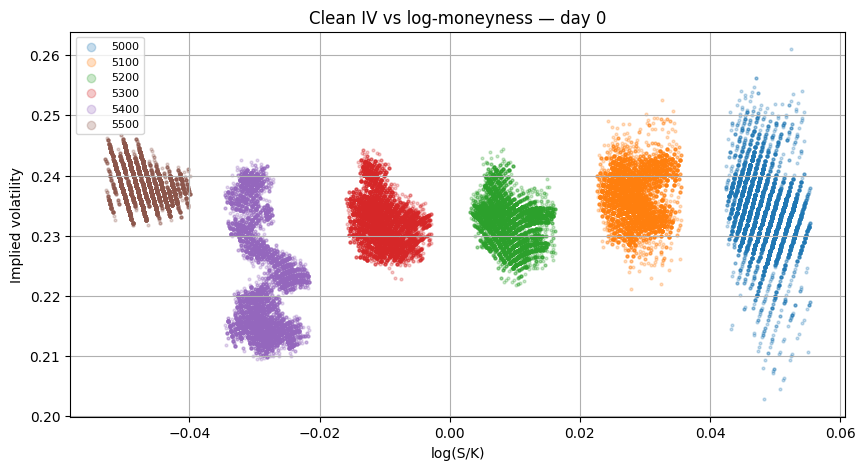

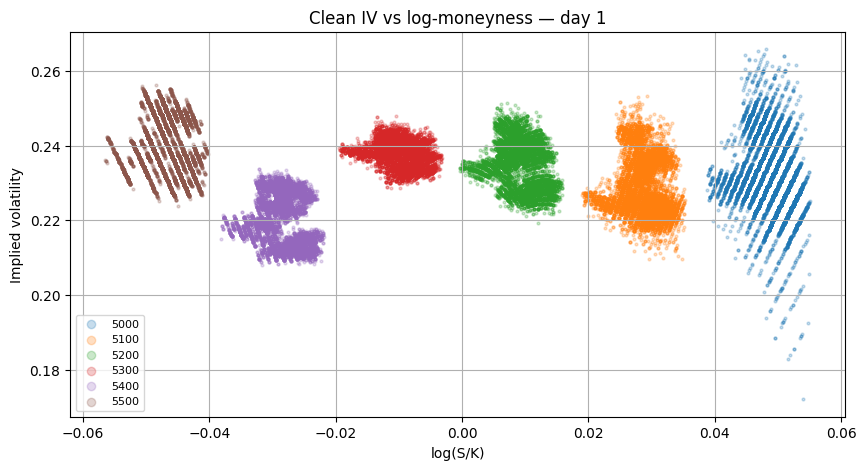

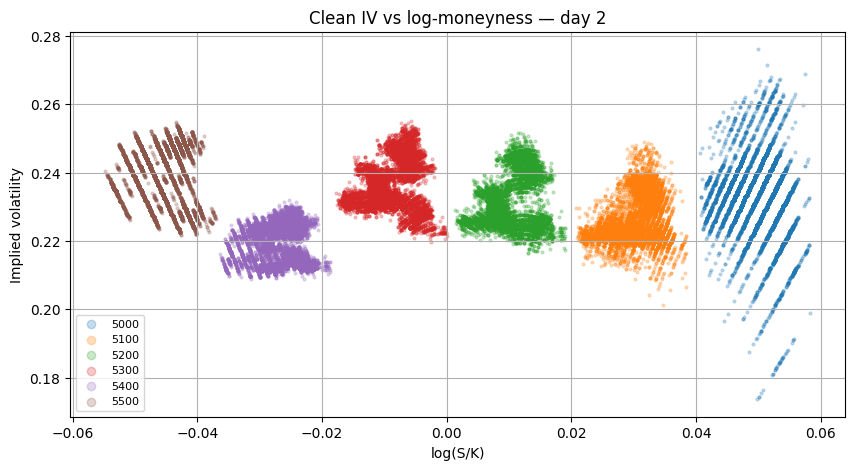

In [94]:
for day in sorted(iv_clean["day"].unique()):
    df = iv_clean[iv_clean["day"] == day]

    plt.figure(figsize=(10, 5))

    for strike in sorted(df["strike"].unique()):
        sdf = df[df["strike"] == strike]
        plt.scatter(
            sdf["log_moneyness"],
            sdf["iv_mid"],
            s=4,
            alpha=0.25,
            label=strike,
        )

    plt.title(f"Clean IV vs log-moneyness — day {day}")
    plt.xlabel("log(S/K)")
    plt.ylabel("Implied volatility")
    plt.legend(markerscale=3, fontsize=8)
    plt.show()

,day,strike,moneyness_mean,log_moneyness_mean,iv_median,iv_mean,iv_std,rows
0,0,5000,1.049302,0.048122,0.233803,0.233862,0.005344,10000
1,0,5100,1.028728,0.028319,0.236624,0.236595,0.003642,10000
2,0,5200,1.008944,0.008901,0.232747,0.232176,0.003271,10000
3,0,5300,0.989908,-0.010147,0.232137,0.232218,0.003556,10000
4,0,5400,0.971576,-0.028839,0.219106,0.222101,0.008930,10000
5,0,5500,0.953911,-0.047188,0.238256,0.238458,0.002662,10000
6,1,5000,1.049678,0.048479,0.230926,0.232162,0.009317,9999
7,1,5100,1.029096,0.028677,0.226943,0.229260,0.007641,10000
8,1,5200,1.009306,0.009259,0.236252,0.235463,0.006112,10000
9,1,5300,0.990263,-0.009789,0.238755,0.238367,0.003125,10000


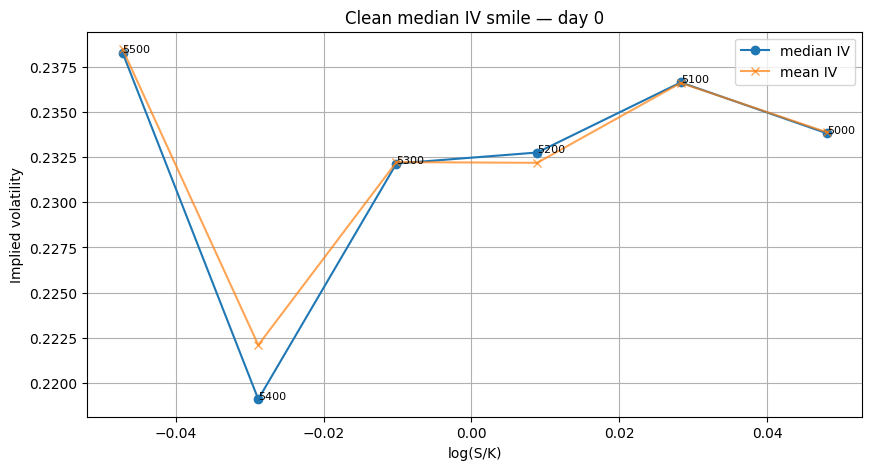

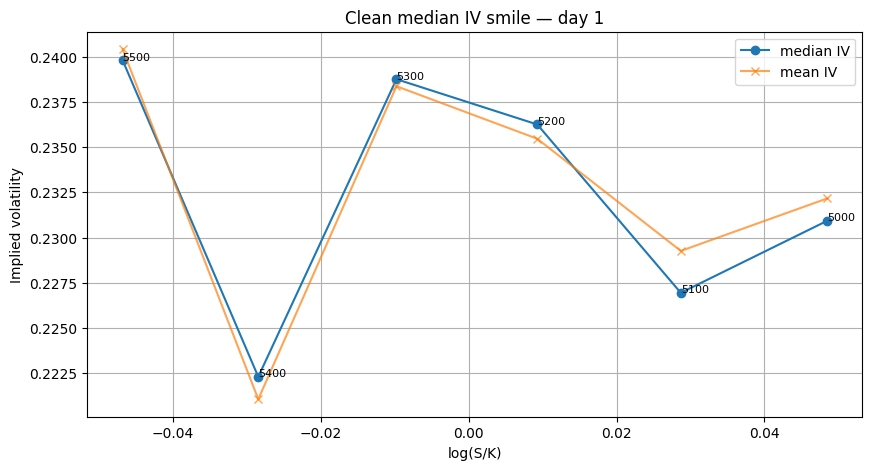

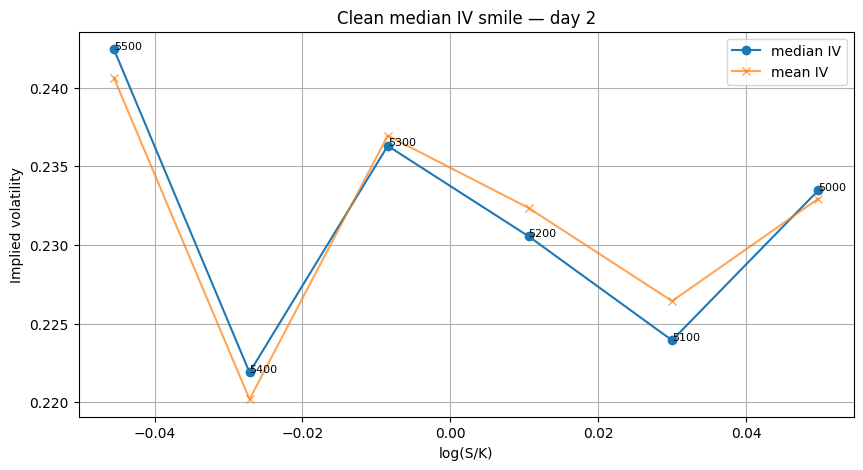

In [95]:
iv_smile_median = iv_clean.groupby(["day", "strike"]).agg(
    moneyness_mean=("moneyness", "mean"),
    log_moneyness_mean=("log_moneyness", "mean"),
    iv_median=("iv_mid", "median"),
    iv_mean=("iv_mid", "mean"),
    iv_std=("iv_mid", "std"),
    rows=("iv_mid", "size"),
).reset_index().sort_values(["day", "strike"])

display(iv_smile_median)

for day in sorted(iv_smile_median["day"].unique()):
    df = iv_smile_median[iv_smile_median["day"] == day]

    plt.figure(figsize=(10, 5))
    plt.plot(df["log_moneyness_mean"], df["iv_median"], marker="o", label="median IV")
    plt.plot(df["log_moneyness_mean"], df["iv_mean"], marker="x", label="mean IV", alpha=0.7)

    for _, row in df.iterrows():
        plt.text(row["log_moneyness_mean"], row["iv_median"], str(int(row["strike"])), fontsize=8)

    plt.title(f"Clean median IV smile — day {day}")
    plt.xlabel("log(S/K)")
    plt.ylabel("Implied volatility")
    plt.legend()
    plt.show()

In [96]:
smile_fit_rows = []
iv_clean["iv_fitted_day"] = np.nan
iv_clean["iv_residual_day"] = np.nan

for day in sorted(iv_clean["day"].unique()):
    df = iv_clean[iv_clean["day"] == day].copy()

    fit_df = df[
        df["strike"].isin(ACTIVE_IV_STRIKES)
        & df["iv_mid"].notna()
        & np.isfinite(df["iv_mid"])
    ].copy()

    x = fit_df["log_moneyness"].values
    y = fit_df["iv_mid"].values

    if len(fit_df) < 100:
        continue

    coeffs = np.polyfit(x, y, deg=2)
    a, b, c = coeffs

    day_mask = iv_clean["day"] == day
    x_all = iv_clean.loc[day_mask, "log_moneyness"].values
    fitted = np.polyval(coeffs, x_all)

    iv_clean.loc[day_mask, "iv_fitted_day"] = fitted
    iv_clean.loc[day_mask, "iv_residual_day"] = (
        iv_clean.loc[day_mask, "iv_mid"] - fitted
    )

    smile_fit_rows.append({
        "day": day,
        "a": a,
        "b": b,
        "c": c,
        "n_fit_obs": len(fit_df),
        "fit_iv_mean": fit_df["iv_mid"].mean(),
        "fit_iv_std": fit_df["iv_mid"].std(),
    })

smile_fit_params = pd.DataFrame(smile_fit_rows)

display(smile_fit_params)

,day,a,b,c,n_fit_obs,fit_iv_mean,fit_iv_std
0,0,2.117057,0.026449,0.230314,60000,0.232568,0.007239
1,1,0.715724,-0.032356,0.232031,59999,0.232788,0.009425
2,2,2.038160,-0.041389,0.229466,59977,0.231588,0.010019


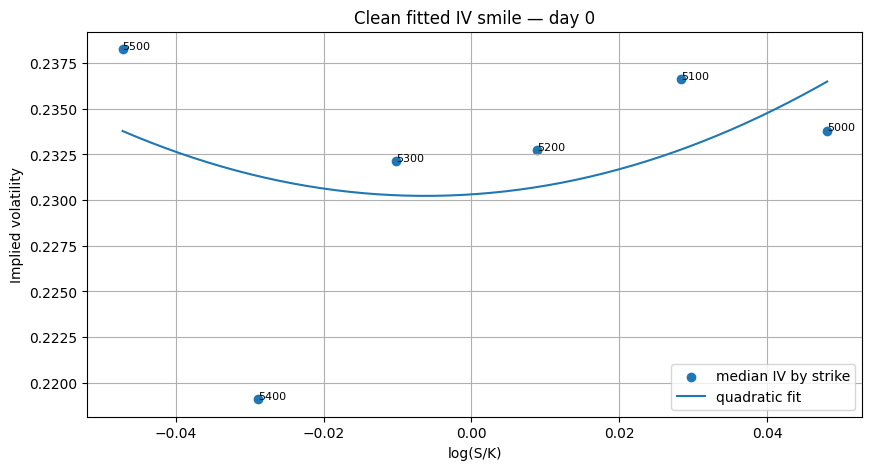

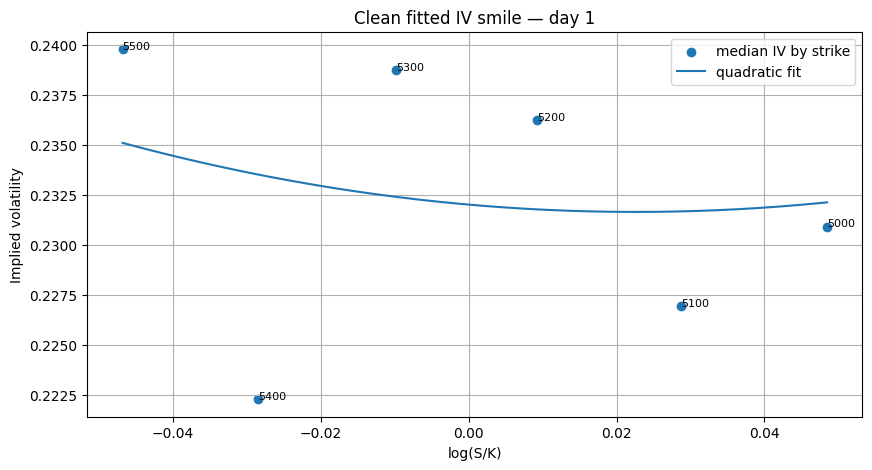

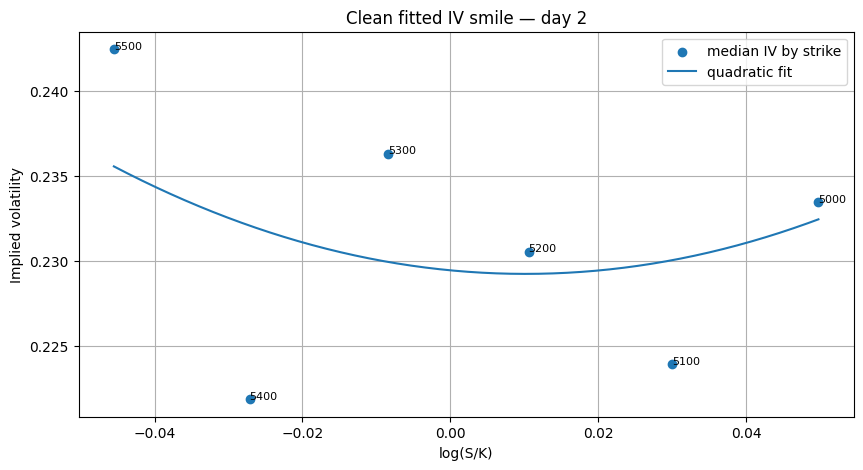

In [97]:
for day in sorted(iv_clean["day"].unique()):
    df = iv_smile_median[iv_smile_median["day"] == day].copy()

    params = smile_fit_params[smile_fit_params["day"] == day]
    if params.empty:
        continue

    a, b, c = params[["a", "b", "c"]].iloc[0].values

    x_grid = np.linspace(df["log_moneyness_mean"].min(), df["log_moneyness_mean"].max(), 200)
    y_grid = np.polyval([a, b, c], x_grid)

    plt.figure(figsize=(10, 5))
    plt.scatter(df["log_moneyness_mean"], df["iv_median"], label="median IV by strike")
    plt.plot(x_grid, y_grid, label="quadratic fit")

    for _, row in df.iterrows():
        plt.text(row["log_moneyness_mean"], row["iv_median"], str(int(row["strike"])), fontsize=8)

    plt.title(f"Clean fitted IV smile — day {day}")
    plt.xlabel("log(S/K)")
    plt.ylabel("Implied volatility")
    plt.legend()
    plt.show()

In [98]:
iv_residual_summary = iv_clean.groupby(["product", "strike"]).agg(
    residual_mean=("iv_residual_day", "mean"),
    residual_median=("iv_residual_day", "median"),
    residual_std=("iv_residual_day", "std"),
    residual_q05=("iv_residual_day", lambda x: x.quantile(0.05)),
    residual_q95=("iv_residual_day", lambda x: x.quantile(0.95)),
    rows=("iv_residual_day", lambda x: x.notna().sum()),
).reset_index().sort_values("strike")

display(iv_residual_summary)

,product,strike,residual_mean,residual_median,residual_std,residual_q05,residual_q95,rows
0,VEV_5000,5000,-0.000721,-0.001318,0.008521,-0.013160,0.013538,29976
1,VEV_5100,5100,-0.000754,0.000197,0.007022,-0.011336,0.009481,30000
2,VEV_5200,5200,0.002730,0.002561,0.006113,-0.006020,0.014051,30000
3,VEV_5300,5300,0.004952,0.004279,0.005355,-0.002629,0.015578,30000
4,VEV_5400,5400,-0.011208,-0.011094,0.007193,-0.021212,0.003177,30000
5,VEV_5500,5500,0.005001,0.004924,0.006169,-0.005996,0.015001,30000


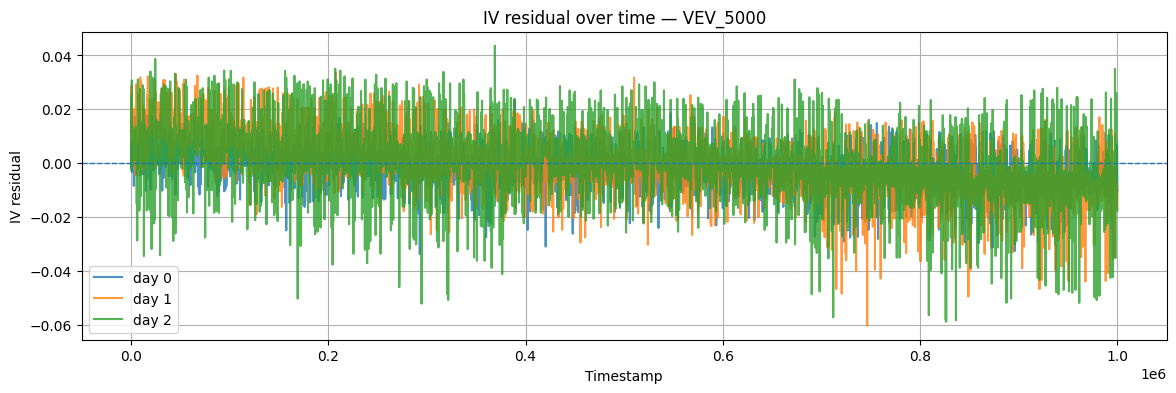

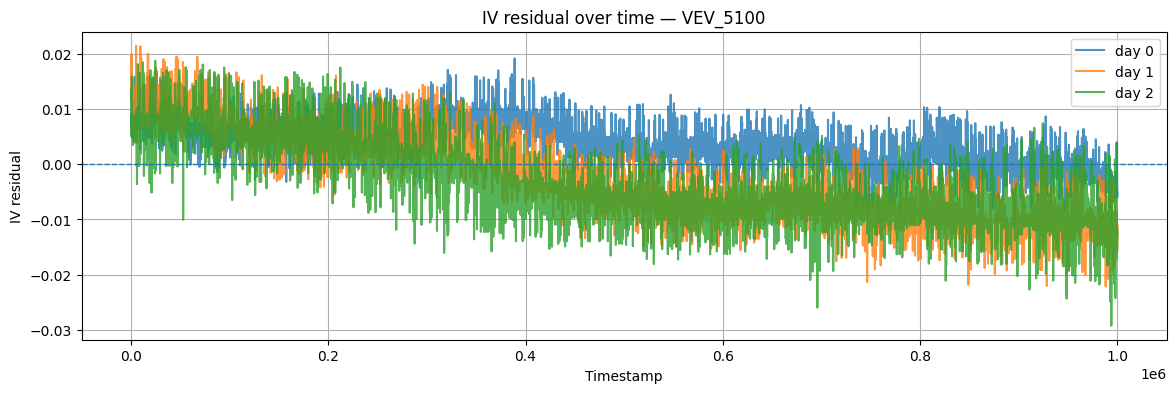

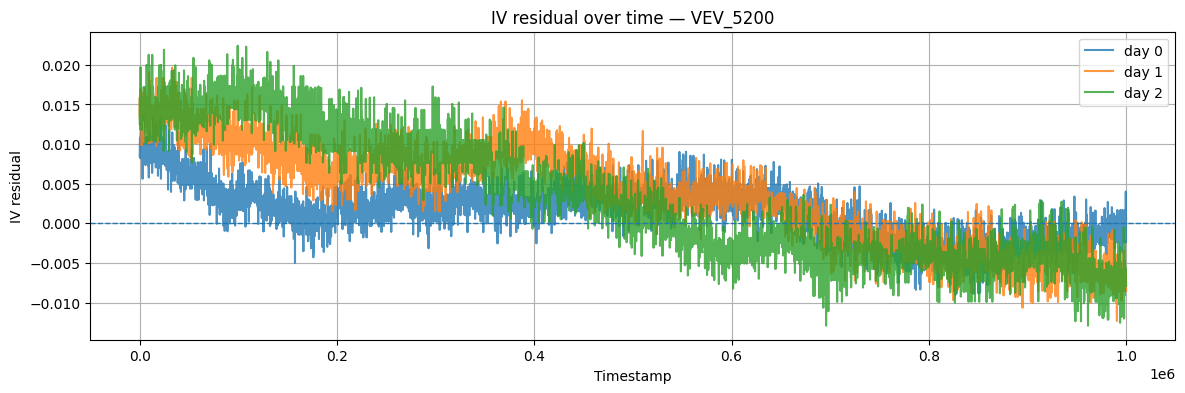

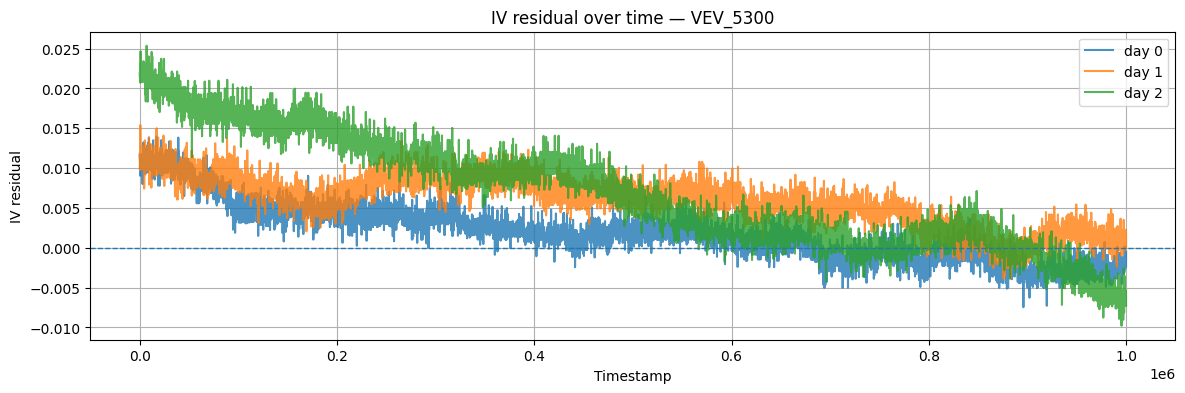

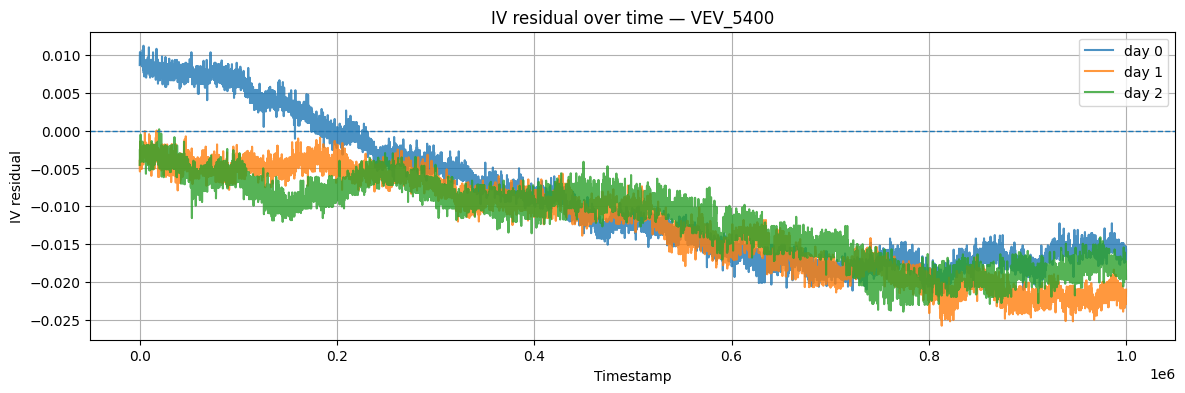

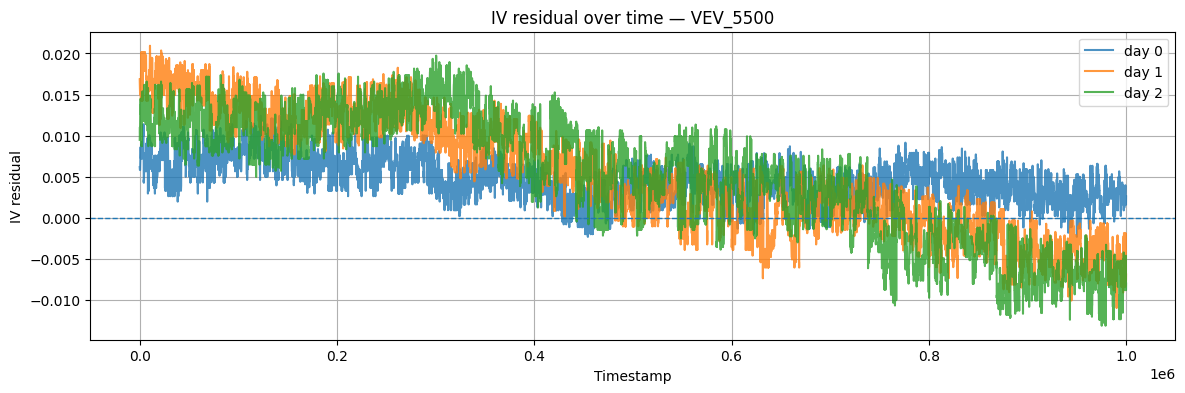

In [99]:
for strike in sorted(iv_clean["strike"].unique()):
    df = iv_clean[iv_clean["strike"] == strike]

    if df["iv_residual_day"].notna().sum() == 0:
        continue

    plt.figure(figsize=(14, 4))

    for day in sorted(df["day"].unique()):
        ddf = df[df["day"] == day]
        plt.plot(ddf["timestamp"], ddf["iv_residual_day"], label=f"day {day}", alpha=0.8)

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"IV residual over time — VEV_{strike}")
    plt.xlabel("Timestamp")
    plt.ylabel("IV residual")
    plt.legend()
    plt.show()

In [100]:
iv_resid_acf_rows = []

for strike in sorted(iv_clean["strike"].unique()):
    for day in sorted(iv_clean["day"].unique()):
        df = iv_clean[(iv_clean["strike"] == strike) & (iv_clean["day"] == day)].copy()
        series = df["iv_residual_day"].dropna()

        if len(series) < 100:
            continue

        for lag in [1, 2, 3, 5, 10]:
            iv_resid_acf_rows.append({
                "strike": strike,
                "day": day,
                "lag": lag,
                "acf": series.autocorr(lag=lag),
            })

iv_resid_acf = pd.DataFrame(iv_resid_acf_rows)

display(
    iv_resid_acf.pivot_table(
        index=["strike", "lag"],
        columns="day",
        values="acf"
    )
)

day                0         1         2
strike lag                              
5000   1    0.369336  0.611723  0.291558
       2    0.367046  0.614860  0.293517
       3    0.361985  0.616934  0.285695
       5    0.373376  0.615610  0.310687
       10   0.372746  0.617973  0.296114
5100   1    0.720623  0.910716  0.803766
       2    0.719564  0.910489  0.800551
       3    0.716383  0.910905  0.797530
       5    0.719524  0.909084  0.804192
       10   0.719046  0.912368  0.801313
5200   1    0.862195  0.950933  0.963500
       2    0.862593  0.951016  0.962756
       3    0.860477  0.951507  0.962471
       5    0.860196  0.950236  0.963005
       10   0.859050  0.951091  0.962300
5300   1    0.926122  0.884517  0.974337
       2    0.923410  0.881578  0.973840
       3    0.923620  0.881264  0.973148
       5    0.921771  0.878514  0.973684
       10   0.921356  0.878229  0.973076
5400   1    0.992183  0.982517  0.966836
       2    0.991737  0.980545  0.961851
       3    0.991600  0.979625  0.957731
       5    0.991308  0.978630  0.954438
       10   0.991071  0.977573  0.951398
5500   1    0.852077  0.976625  0.973985
       2    0.805464  0.968737  0.963043
       3    0.773066  0.962500  0.954408
       5    0.719112  0.952282  0.942205
       10   0.636749  0.936084  0.921321

In [101]:
iv_pred = iv_clean.sort_values(["product", "day", "timestamp"]).copy()

iv_pred["next_residual"] = iv_pred.groupby(["product", "day"])["iv_residual_day"].shift(-1)
iv_pred["residual_change_next"] = iv_pred["next_residual"] - iv_pred["iv_residual_day"]

iv_residual_predictiveness = []

for strike in sorted(iv_pred["strike"].unique()):
    df = iv_pred[iv_pred["strike"] == strike].dropna(
        subset=["iv_residual_day", "residual_change_next"]
    )

    if len(df) == 0:
        continue

    iv_residual_predictiveness.append({
        "strike": strike,
        "corr_residual_next_change": df["iv_residual_day"].corr(df["residual_change_next"]),
        "avg_next_change_when_resid_pos": df.loc[df["iv_residual_day"] > 0, "residual_change_next"].mean(),
        "avg_next_change_when_resid_neg": df.loc[df["iv_residual_day"] < 0, "residual_change_next"].mean(),
        "count_resid_pos": (df["iv_residual_day"] > 0).sum(),
        "count_resid_neg": (df["iv_residual_day"] < 0).sum(),
    })

iv_residual_predictiveness = pd.DataFrame(iv_residual_predictiveness).sort_values("strike")

display(iv_residual_predictiveness)

,strike,corr_residual_next_change,avg_next_change_when_resid_pos,avg_next_change_when_resid_neg,count_resid_pos,count_resid_neg
0,5000,-0.524880,-0.003097,0.002302,12790,17183
1,5100,-0.243843,-0.000455,0.000464,15204,14793
2,5200,-0.157803,-0.000118,0.000203,19140,10857
3,5300,-0.139094,-0.000078,0.000360,24789,5208
4,5400,-0.086270,-0.000075,0.000003,1995,28002
5,5500,-0.125478,-0.000057,0.000225,24079,5918


In [102]:
def bs_price_from_row(row, iv_col):
    sigma = row[iv_col]
    if pd.isna(sigma):
        return np.nan

    return black_scholes_call(
        S=row["underlying_mid"],
        K=row["strike"],
        T=row["T"],
        r=RISK_FREE_RATE,
        sigma=sigma,
    )

iv_clean["fair_price_from_fitted_iv"] = iv_clean.apply(
    lambda r: bs_price_from_row(r, "iv_fitted_day"),
    axis=1,
)

iv_clean["price_residual_from_fitted_iv"] = (
    iv_clean["mid"] - iv_clean["fair_price_from_fitted_iv"]
)

price_residual_summary = iv_clean.groupby(["product", "strike"]).agg(
    price_resid_mean=("price_residual_from_fitted_iv", "mean"),
    price_resid_median=("price_residual_from_fitted_iv", "median"),
    price_resid_std=("price_residual_from_fitted_iv", "std"),
    price_resid_q05=("price_residual_from_fitted_iv", lambda x: x.quantile(0.05)),
    price_resid_q95=("price_residual_from_fitted_iv", lambda x: x.quantile(0.95)),
    spread_mean=("spread", "mean"),
).reset_index().sort_values("strike")

display(price_residual_summary)

,product,strike,price_resid_mean,price_resid_median,price_resid_std,price_resid_q05,price_resid_q95,spread_mean
0,VEV_5000,5000,-0.047357,-0.114149,0.717817,-1.041432,1.310032,6.045370
1,VEV_5100,5100,-0.059802,0.028415,1.299268,-1.962023,1.979994,4.295833
2,VEV_5200,5200,0.739792,0.731626,1.603964,-1.563904,3.571535,2.888133
3,VEV_5300,5300,1.343191,1.203491,1.437207,-0.765782,4.075203,2.106800
4,VEV_5400,5400,-2.171338,-2.092244,1.453749,-4.271783,0.670509,1.381433
5,VEV_5500,5500,0.559043,0.541911,0.658445,-0.592699,1.671032,1.149767


In [103]:
iv_summary = iv_df.groupby(["product", "strike"]).agg(
    iv_mean=("iv_mid", "mean"),
    iv_median=("iv_mid", "median"),
    iv_std=("iv_mid", "std"),
    iv_min=("iv_mid", "min"),
    iv_max=("iv_mid", "max"),
    iv_q05=("iv_mid", lambda x: x.quantile(0.05)),
    iv_q95=("iv_mid", lambda x: x.quantile(0.95)),
    iv_spread_mean=("iv_spread", "mean"),
    iv_spread_median=("iv_spread", "median"),
).reset_index().sort_values("strike")

display(iv_summary)

,product,strike,iv_mean,iv_median,iv_std,iv_min,iv_max,iv_q05,iv_q95,iv_spread_mean,iv_spread_median
0,VEV_4000,4000,0.365658,0.312501,0.153807,0.312501,1.113881,0.312501,0.791264,0.620230,0.716116
1,VEV_4500,4500,0.278465,0.156251,0.147306,0.156251,0.662782,0.156251,0.484147,0.383782,0.451846
2,VEV_5000,5000,0.232881,0.232902,0.009372,0.039063,0.276095,0.219687,0.246322,0.073679,0.063743
3,VEV_5100,5100,0.230764,0.232246,0.007564,0.201245,0.253182,0.219547,0.241974,0.023654,0.022926
4,VEV_5200,5200,0.233332,0.233350,0.006217,0.216350,0.251663,0.224142,0.244078,0.010598,0.010719
5,VEV_5300,5300,0.235847,0.235269,0.005546,0.219795,0.255129,0.227483,0.245482,0.007590,0.007293
6,VEV_5400,5400,0.221118,0.221337,0.007121,0.208039,0.242604,0.211592,0.234682,0.007269,0.006040
7,VEV_5500,5500,0.239836,0.239267,0.006247,0.221814,0.256228,0.229079,0.250229,0.010675,0.009312
8,VEV_6000,6000,0.379621,0.378537,0.021852,0.337838,0.430567,0.347764,0.415134,NaN,NaN
9,VEV_6500,6500,0.575250,0.573121,0.032919,0.520513,0.639904,0.530033,0.625062,NaN,NaN


In [105]:
iv_residual_summary = iv_clean.groupby(["product", "strike"]).agg(
    residual_mean=("iv_residual_day", "mean"),
    residual_median=("iv_residual_day", "median"),
    residual_std=("iv_residual_day", "std"),
    residual_q05=("iv_residual_day", lambda x: x.quantile(0.05)),
    residual_q95=("iv_residual_day", lambda x: x.quantile(0.95)),
    rows=("iv_residual_day", lambda x: x.notna().sum()),
).reset_index().sort_values("strike")

price_residual_summary = iv_clean.groupby(["product", "strike"]).agg(
    price_resid_mean=("price_residual_from_fitted_iv", "mean"),
    price_resid_median=("price_residual_from_fitted_iv", "median"),
    price_resid_std=("price_residual_from_fitted_iv", "std"),
    price_resid_q05=("price_residual_from_fitted_iv", lambda x: x.quantile(0.05)),
    price_resid_q95=("price_residual_from_fitted_iv", lambda x: x.quantile(0.95)),
    spread_mean=("spread", "mean"),
).reset_index().sort_values("strike")

iv_decision_table = (
    iv_summary[
        [
            "product", "strike", "iv_mean", "iv_median", "iv_std",
            "iv_q05", "iv_q95", "iv_spread_mean"
        ]
    ]
    .merge(
        iv_coverage[
            ["product", "strike", "valid_iv_frac", "mean_time_value", "mean_spread", "mid_std"]
        ],
        on=["product", "strike"],
        how="left"
    )
    .merge(
        iv_residual_summary[
            ["product", "strike", "residual_mean", "residual_std", "residual_q05", "residual_q95"]
        ],
        on=["product", "strike"],
        how="left"
    )
    .merge(
        price_residual_summary[
            ["product", "strike", "price_resid_mean", "price_resid_std", "spread_mean"]
        ],
        on=["product", "strike"],
        how="left"
    )
    .sort_values("strike")
)

display(iv_decision_table)

,product,strike,iv_mean,iv_median,iv_std,iv_q05,iv_q95,iv_spread_mean,valid_iv_frac,mean_time_value,mean_spread,mid_std,residual_mean,residual_std,residual_q05,residual_q95,price_resid_mean,price_resid_std,spread_mean
0,VEV_4000,4000,0.365658,0.312501,0.153807,0.312501,0.791264,0.620230,0.900467,0.011700,20.813467,15.647243,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,VEV_4500,4500,0.278465,0.156251,0.147306,0.156251,0.484147,0.383782,0.706267,0.011467,15.852667,15.639930,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,VEV_5000,5000,0.232881,0.232902,0.009372,0.219687,0.246322,0.073679,0.999900,4.924300,6.043333,14.375586,-0.000721,0.008521,-0.013160,0.013538,-0.047357,0.717817,6.045370
3,VEV_5100,5100,0.230764,0.232246,0.007564,0.219547,0.241974,0.023654,1.000000,16.707350,4.295833,12.742624,-0.000754,0.007022,-0.011336,0.009481,-0.059802,1.299268,4.295833
4,VEV_5200,5200,0.233332,0.233350,0.006217,0.224142,0.244078,0.010598,1.000000,45.450383,2.888133,9.664218,0.002730,0.006113,-0.006020,0.014051,0.739792,1.603964,2.888133
5,VEV_5300,5300,0.235847,0.235269,0.005546,0.227483,0.245482,0.007590,1.000000,46.759933,2.106800,6.228141,0.004952,0.005355,-0.002629,0.015578,1.343191,1.437207,2.106800
6,VEV_5400,5400,0.221118,0.221337,0.007121,0.211592,0.234682,0.007269,1.000000,15.951917,1.381433,3.429182,-0.011208,0.007193,-0.021212,0.003177,-2.171338,1.453749,1.381433
7,VEV_5500,5500,0.239836,0.239267,0.006247,0.229079,0.250229,0.010675,1.000000,6.641350,1.149767,1.738849,0.005001,0.006169,-0.005996,0.015001,0.559043,0.658445,1.149767
8,VEV_6000,6000,0.379621,0.378537,0.021852,0.347764,0.415134,NaN,1.000000,0.500000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,VEV_6500,6500,0.575250,0.573121,0.032919,0.530033,0.625062,NaN,1.000000,0.500000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [106]:
excluded_strikes = [4000, 4500, 6000, 6500]

excluded = iv_df[iv_df["strike"].isin(excluded_strikes)].copy()

excluded["intrinsic_residual"] = excluded["mid"] - excluded["intrinsic"]
excluded["next_mid"] = excluded.groupby(["product", "day"])["mid"].shift(-1)
excluded["next_mid_change"] = excluded["next_mid"] - excluded["mid"]

excluded_summary = excluded.groupby(["product", "strike"]).agg(
    mid_mean=("mid", "mean"),
    mid_std=("mid", "std"),
    spread_mean=("spread", "mean"),
    intrinsic_mean=("intrinsic", "mean"),
    intrinsic_residual_mean=("intrinsic_residual", "mean"),
    intrinsic_residual_std=("intrinsic_residual", "std"),
    intrinsic_residual_min=("intrinsic_residual", "min"),
    intrinsic_residual_max=("intrinsic_residual", "max"),
    frac_below_intrinsic=("intrinsic_residual", lambda x: (x < 0).mean()),
    next_mid_change_std=("next_mid_change", "std"),
    num_unique_mid=("mid", "nunique"),
).reset_index().sort_values("strike")

display(excluded_summary)

,product,strike,mid_mean,mid_std,spread_mean,intrinsic_mean,intrinsic_residual_mean,intrinsic_residual_std,intrinsic_residual_min,intrinsic_residual_max,frac_below_intrinsic,next_mid_change_std,num_unique_mid
0,VEV_4000,4000,1250.109800,15.647243,20.813467,1250.0981,0.011700,0.828675,-7.0,7.0,0.099533,1.416751,196
1,VEV_4500,4500,750.109567,15.639930,15.852667,750.0981,0.011467,0.758895,-6.0,5.5,0.293733,1.252041,190
2,VEV_6000,6000,0.500000,0.000000,1.000000,0.0000,0.500000,0.000000,0.5,0.5,0.000000,0.000000,1
3,VEV_6500,6500,0.500000,0.000000,1.000000,0.0000,0.500000,0.000000,0.5,0.5,0.000000,0.000000,1


In [107]:
excluded_predictiveness = []

for strike in excluded_strikes:
    df = excluded[excluded["strike"] == strike].dropna(
        subset=["intrinsic_residual", "next_mid_change"]
    )

    if len(df) == 0 or df["intrinsic_residual"].std() == 0:
        excluded_predictiveness.append({
            "strike": strike,
            "corr_residual_next_mid_change": np.nan,
            "avg_next_change_when_resid_high": np.nan,
            "avg_next_change_when_resid_low": np.nan,
            "count_high": 0,
            "count_low": 0,
        })
        continue

    high = df["intrinsic_residual"] > df["intrinsic_residual"].quantile(0.75)
    low = df["intrinsic_residual"] < df["intrinsic_residual"].quantile(0.25)

    excluded_predictiveness.append({
        "strike": strike,
        "corr_residual_next_mid_change": df["intrinsic_residual"].corr(df["next_mid_change"]),
        "avg_next_change_when_resid_high": df.loc[high, "next_mid_change"].mean(),
        "avg_next_change_when_resid_low": df.loc[low, "next_mid_change"].mean(),
        "count_high": high.sum(),
        "count_low": low.sum(),
    })

excluded_predictiveness = pd.DataFrame(excluded_predictiveness)

display(excluded_predictiveness)

,strike,corr_residual_next_mid_change,avg_next_change_when_resid_high,avg_next_change_when_resid_low,count_high,count_low
0,4000,-0.446949,-0.564635,0.695142,2986,2985
1,4500,-0.376175,-0.698476,1.048699,1378,1191
2,6000,NaN,NaN,NaN,0,0
3,6500,NaN,NaN,NaN,0,0


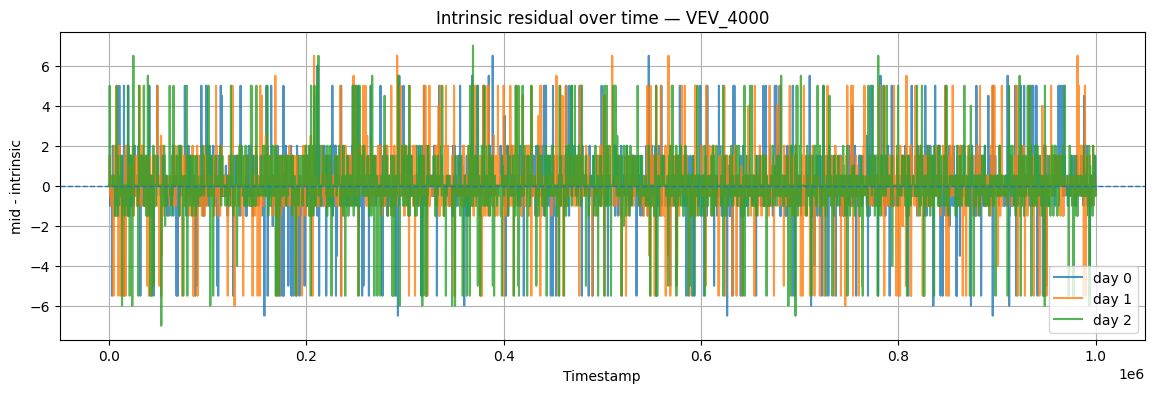

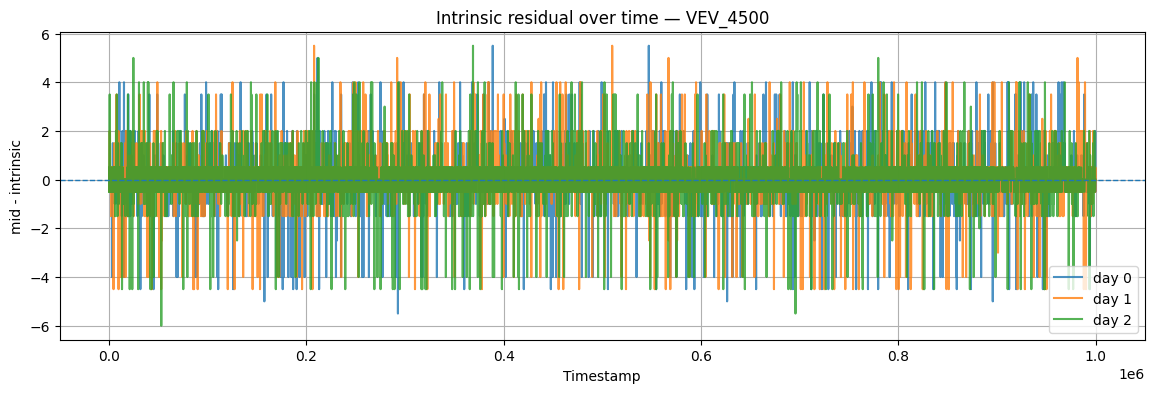

In [108]:
for strike in [4000, 4500]:
    df = excluded[excluded["strike"] == strike]

    plt.figure(figsize=(14, 4))

    for day in sorted(df["day"].unique()):
        ddf = df[df["day"] == day]
        plt.plot(
            ddf["timestamp"],
            ddf["intrinsic_residual"],
            label=f"day {day}",
            alpha=0.8,
        )

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"Intrinsic residual over time — VEV_{strike}")
    plt.xlabel("Timestamp")
    plt.ylabel("mid - intrinsic")
    plt.legend()
    plt.show()

## Vol smile fair-value model

In [109]:
# Core strikes for IV smile modeling
ACTIVE_IV_STRIKES = [5000, 5100, 5200, 5300, 5400, 5500]

fv = iv_df[
    iv_df["strike"].isin(ACTIVE_IV_STRIKES)
    & iv_df["iv_mid"].notna()
    & np.isfinite(iv_df["iv_mid"])
    & (iv_df["iv_mid"] > 0)
    & (iv_df["iv_mid"] < 2.0)
    & (iv_df["time_value"] > 0.25)
].copy()

fv = fv.sort_values(["day", "timestamp", "strike"])

display(fv.head())

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,intrinsic,time_value,moneyness,log_moneyness,tte_days,T,iv_mid,iv_bid,iv_ask,iv_spread
6,0,0,VEV_5000,254,19,NaN,NaN,NaN,NaN,260,...,250.0,7.0,1.050000,0.048790,8,0.021918,0.239329,0.210249,0.262815,0.052566
8,0,0,VEV_5100,169,19,NaN,NaN,NaN,NaN,174,...,150.0,21.5,1.029412,0.028988,8,0.021918,0.240052,0.228448,0.251294,0.022846
3,0,0,VEV_5200,100,19,NaN,NaN,NaN,NaN,103,...,50.0,51.5,1.009615,0.009569,8,0.021918,0.239229,0.234182,0.244267,0.010085
4,0,0,VEV_5300,52,6,51.0,19.0,NaN,NaN,54,...,0.0,53.0,0.990566,-0.009479,8,0.021918,0.241951,0.238625,0.245275,0.006649
0,0,0,VEV_5400,22,25,NaN,NaN,NaN,NaN,24,...,0.0,23.0,0.972222,-0.028171,8,0.021918,0.239881,0.235499,0.244213,0.008714


In [110]:
fv["iv_fitted_ts"] = np.nan
fv["iv_residual_ts"] = np.nan

ts_fit_rows = []

for (day, timestamp), group in fv.groupby(["day", "timestamp"]):
    group = group.sort_values("strike")

    if group["strike"].nunique() < 4:
        continue

    x = group["log_moneyness"].values
    y = group["iv_mid"].values

    try:
        coeffs = np.polyfit(x, y, deg=2)
    except Exception:
        continue

    fitted = np.polyval(coeffs, x)

    idx = group.index
    fv.loc[idx, "iv_fitted_ts"] = fitted
    fv.loc[idx, "iv_residual_ts"] = y - fitted

    ts_fit_rows.append({
        "day": day,
        "timestamp": timestamp,
        "a": coeffs[0],
        "b": coeffs[1],
        "c": coeffs[2],
        "n_strikes": group["strike"].nunique(),
        "fit_iv_mean": np.mean(y),
        "fit_iv_std": np.std(y),
        "fit_rmse": np.sqrt(np.mean((y - fitted) ** 2)),
    })

ts_smile_fits = pd.DataFrame(ts_fit_rows)

display(ts_smile_fits.head())
display(ts_smile_fits.describe())

,day,timestamp,a,b,c,n_strikes,fit_iv_mean,fit_iv_std,fit_rmse
0,0,0,-0.423256,-0.006358,0.240499,6,0.240047,0.000902,0.000781
1,0,100,0.171807,0.028291,0.241180,6,0.241380,0.001335,0.000941
2,0,200,-1.930863,-0.031483,0.242023,6,0.239956,0.002193,0.000603
3,0,300,-0.861737,-0.001090,0.241594,6,0.240680,0.000859,0.000341
4,0,400,-1.930863,-0.031483,0.242023,6,0.239956,0.002193,0.000603


,day,timestamp,a,b,c,n_strikes,fit_iv_mean,fit_iv_std,fit_rmse
count,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,1.00000,499950.000000,1.671695,-0.013517,0.230564,5.999200,0.232313,0.006812,0.005987
std,0.81651,288679.944524,1.997747,0.067705,0.005547,0.028273,0.005591,0.001778,0.001663
min,0.00000,0.000000,-11.518520,-0.510184,0.216451,5.000000,0.211454,0.000401,0.000137
25%,0.00000,249975.000000,0.393916,-0.053967,0.225401,6.000000,0.228320,0.006063,0.005388
50%,1.00000,499950.000000,1.713886,-0.013345,0.230718,6.000000,0.232102,0.007013,0.006318
75%,2.00000,749925.000000,2.967292,0.029702,0.235039,6.000000,0.236578,0.007791,0.007110
max,2.00000,999900.000000,10.812413,0.276132,0.245558,6.000000,0.250445,0.022475,0.010974


In [111]:
ts_fit_quality = ts_smile_fits.groupby("day").agg(
    num_fits=("timestamp", "count"),
    rmse_mean=("fit_rmse", "mean"),
    rmse_median=("fit_rmse", "median"),
    rmse_q95=("fit_rmse", lambda x: x.quantile(0.95)),
    fit_iv_mean=("fit_iv_mean", "mean"),
    fit_iv_std=("fit_iv_std", "mean"),
)

display(ts_fit_quality)

,num_fits,rmse_mean,rmse_median,rmse_q95,fit_iv_mean,fit_iv_std
day,,,,,,
0,10000,0.004963,0.005566,0.007638,0.232568,0.005800
1,10000,0.006487,0.006576,0.007920,0.232788,0.007059
2,10000,0.006512,0.006578,0.008158,0.231584,0.007577


In [112]:
fv["fair_price_ts"] = fv.apply(
    lambda r: black_scholes_call(
        S=r["underlying_mid"],
        K=r["strike"],
        T=r["T"],
        r=RISK_FREE_RATE,
        sigma=r["iv_fitted_ts"],
    ) if pd.notna(r["iv_fitted_ts"]) else np.nan,
    axis=1,
)

fv["price_residual_ts"] = fv["mid"] - fv["fair_price_ts"]

display(
    fv[[
        "day", "timestamp", "product", "strike",
        "mid", "fair_price_ts", "price_residual_ts",
        "iv_mid", "iv_fitted_ts", "iv_residual_ts",
        "spread"
    ]].head()
)

,day,timestamp,product,strike,mid,fair_price_ts,price_residual_ts,iv_mid,iv_fitted_ts,iv_residual_ts,spread
6,0,0,VEV_5000,5000,257.0,256.982659,0.017341,0.239329,0.239181,0.000148,6.0
8,0,0,VEV_5100,5100,171.5,171.479577,0.020423,0.240052,0.239959,0.000093,5.0
3,0,0,VEV_5200,5200,101.5,101.848347,-0.348347,0.239229,0.240399,-0.001171,3.0
4,0,0,VEV_5300,5300,53.0,52.569902,0.430098,0.241951,0.240521,0.001430,2.0
0,0,0,VEV_5400,5400,23.0,23.105859,-0.105859,0.239881,0.240342,-0.000461,2.0


In [113]:
fv_residual_summary = fv.groupby(["product", "strike"]).agg(
    rows=("price_residual_ts", lambda x: x.notna().sum()),
    price_resid_mean=("price_residual_ts", "mean"),
    price_resid_median=("price_residual_ts", "median"),
    price_resid_std=("price_residual_ts", "std"),
    price_resid_q05=("price_residual_ts", lambda x: x.quantile(0.05)),
    price_resid_q95=("price_residual_ts", lambda x: x.quantile(0.95)),
    iv_resid_mean=("iv_residual_ts", "mean"),
    iv_resid_std=("iv_residual_ts", "std"),
    spread_mean=("spread", "mean"),
).reset_index().sort_values("strike")

display(fv_residual_summary)

,product,strike,rows,price_resid_mean,price_resid_median,price_resid_std,price_resid_q05,price_resid_q95,iv_resid_mean,iv_resid_std,spread_mean
0,VEV_5000,5000,29976,-0.095975,-0.046892,0.195819,-0.442050,0.184124,-0.000829,0.001913,6.045370
1,VEV_5100,5100,30000,-0.080495,-0.221752,0.754565,-1.207831,1.206375,-0.000757,0.003908,4.295833
2,VEV_5200,5200,30000,0.748102,0.801573,0.554516,-0.331072,1.570306,0.002775,0.002020,2.888133
3,VEV_5300,5300,30000,1.355479,1.402600,0.758302,0.146349,2.537089,0.005008,0.002897,2.106800
4,VEV_5400,5400,30000,-2.172083,-2.294515,0.747983,-3.128838,-0.441616,-0.011175,0.003653,1.381433
5,VEV_5500,5500,30000,0.548271,0.568014,0.240173,0.127106,0.928696,0.004978,0.001788,1.149767


In [114]:
fv["half_spread"] = fv["spread"] / 2
fv["abs_price_residual"] = fv["price_residual_ts"].abs()

fv["resid_gt_half_spread"] = fv["abs_price_residual"] > fv["half_spread"]
fv["resid_gt_full_spread"] = fv["abs_price_residual"] > fv["spread"]

resid_vs_spread = fv.groupby(["product", "strike"]).agg(
    rows=("abs_price_residual", "count"),
    mean_abs_resid=("abs_price_residual", "mean"),
    median_abs_resid=("abs_price_residual", "median"),
    q95_abs_resid=("abs_price_residual", lambda x: x.quantile(0.95)),
    spread_mean=("spread", "mean"),
    half_spread_mean=("half_spread", "mean"),
    frac_gt_half_spread=("resid_gt_half_spread", "mean"),
    frac_gt_full_spread=("resid_gt_full_spread", "mean"),
).reset_index().sort_values("strike")

display(resid_vs_spread)

,product,strike,rows,mean_abs_resid,median_abs_resid,q95_abs_resid,spread_mean,half_spread_mean,frac_gt_half_spread,frac_gt_full_spread
0,VEV_5000,5000,29976,0.163403,0.111503,0.442318,6.045370,3.022685,0.000000,0.000000
1,VEV_5100,5100,30000,0.646338,0.607509,1.348462,4.295833,2.147917,0.005567,0.000867
2,VEV_5200,5200,30000,0.820444,0.806596,1.570306,2.888133,1.444067,0.112967,0.003567
3,VEV_5300,5300,30000,1.361810,1.402600,2.537089,2.106800,1.053400,0.613100,0.223967
4,VEV_5400,5400,30000,2.175877,2.294515,3.128838,1.381433,0.690717,0.937633,0.840433
5,VEV_5500,5500,30000,0.549774,0.568014,0.928696,1.149767,0.574883,0.511100,0.017200


In [115]:
residual_direction = fv.groupby(["product", "strike"]).agg(
    frac_overpriced=("price_residual_ts", lambda x: (x > 0).mean()),
    frac_underpriced=("price_residual_ts", lambda x: (x < 0).mean()),
    avg_overpricing=("price_residual_ts", lambda x: x[x > 0].mean() if (x > 0).any() else np.nan),
    avg_underpricing=("price_residual_ts", lambda x: x[x < 0].mean() if (x < 0).any() else np.nan),
    max_overpricing=("price_residual_ts", "max"),
    max_underpricing=("price_residual_ts", "min"),
).reset_index().sort_values("strike")

display(residual_direction)

,product,strike,frac_overpriced,frac_underpriced,avg_overpricing,avg_underpricing,max_overpricing,max_underpricing
0,VEV_5000,5000,0.368495,0.631505,0.091491,-0.205364,0.553622,-0.659151
1,VEV_5100,5100,0.397400,0.602600,0.711931,-0.603081,2.154814,-2.133201
2,VEV_5200,5200,0.894567,0.105433,0.876707,-0.343071,2.417570,-1.213066
3,VEV_5300,5300,0.976233,0.023767,1.391721,-0.133192,3.260783,-0.895683
4,VEV_5400,5400,0.013600,0.986400,0.139463,-2.203954,0.526434,-4.110882
5,VEV_5500,5500,0.985367,0.014633,0.557176,-0.051337,1.364523,-0.170638


In [116]:
fv = fv.sort_values(["product", "day", "timestamp"]).copy()

fv["next_resid"] = fv.groupby(["product", "day"])["price_residual_ts"].shift(-1)
fv["next_resid_change"] = fv["next_resid"] - fv["price_residual_ts"]

resid_reversion = []

for strike in sorted(fv["strike"].unique()):
    df = fv[fv["strike"] == strike].dropna(
        subset=["price_residual_ts", "next_resid_change"]
    )

    resid_reversion.append({
        "strike": strike,
        "corr_resid_next_change": df["price_residual_ts"].corr(df["next_resid_change"]),
        "avg_next_change_when_overpriced": df.loc[df["price_residual_ts"] > 0, "next_resid_change"].mean(),
        "avg_next_change_when_underpriced": df.loc[df["price_residual_ts"] < 0, "next_resid_change"].mean(),
        "count_overpriced": (df["price_residual_ts"] > 0).sum(),
        "count_underpriced": (df["price_residual_ts"] < 0).sum(),
    })

resid_reversion = pd.DataFrame(resid_reversion).sort_values("strike")

display(resid_reversion)

,strike,corr_resid_next_change,avg_next_change_when_overpriced,avg_next_change_when_underpriced,count_overpriced,count_underpriced
0,5000,-0.201328,-0.022772,0.013290,11045,18928
1,5100,-0.221745,-0.057631,0.037981,11920,18077
2,5200,-0.241040,-0.007321,0.062461,26834,3163
3,5300,-0.217150,-0.005938,0.244341,29284,713
4,5400,-0.145615,-0.112549,0.001501,408,29589
5,5500,-0.173924,-0.000485,0.033576,29558,439


In [117]:
for horizon in [1, 2, 5, 10]:
    fv[f"future_mid_{horizon}"] = fv.groupby(["product", "day"])["mid"].shift(-horizon)
    fv[f"future_pnl_long_{horizon}"] = fv[f"future_mid_{horizon}"] - fv["mid"]

signal_pnl_rows = []

for strike in sorted(fv["strike"].unique()):
    df = fv[fv["strike"] == strike].copy()

    for horizon in [1, 2, 5, 10]:
        pnl_col = f"future_pnl_long_{horizon}"

        valid = df.dropna(subset=["price_residual_ts", pnl_col]).copy()

        # If residual < 0, option is cheap: long signal.
        # If residual > 0, option is expensive: short signal.
        valid["signal_position"] = np.where(valid["price_residual_ts"] < 0, 1, -1)
        valid["signal_pnl"] = valid["signal_position"] * valid[pnl_col]

        signal_pnl_rows.append({
            "strike": strike,
            "horizon": horizon,
            "avg_signal_pnl": valid["signal_pnl"].mean(),
            "median_signal_pnl": valid["signal_pnl"].median(),
            "win_rate": (valid["signal_pnl"] > 0).mean(),
            "num_obs": len(valid),
        })

signal_pnl = pd.DataFrame(signal_pnl_rows)

display(signal_pnl.pivot(index="strike", columns="horizon", values="avg_signal_pnl"))
display(signal_pnl.pivot(index="strike", columns="horizon", values="win_rate"))

horizon,1,2,5,10
strike,,,,
5000,0.058419,0.060744,0.071893,0.095555
5100,0.011851,0.012102,0.017325,0.022256
5200,0.011768,0.011336,0.012790,0.015282
5300,0.009801,0.009102,0.008538,0.005339
5400,0.002500,0.002334,0.002668,0.003787
5500,0.001050,0.002000,0.002701,0.002753


horizon,1,2,5,10
strike,,,,
5000,0.378040,0.412646,0.443076,0.462967
5100,0.356202,0.394912,0.433717,0.454521
5200,0.292163,0.341602,0.396231,0.424892
5300,0.217355,0.266653,0.332766,0.376543
5400,0.142648,0.191772,0.264132,0.317584
5500,0.061840,0.084083,0.118993,0.152319


In [118]:
threshold_rows = []

threshold_multipliers = [0.25, 0.5, 0.75, 1.0]

for strike in sorted(fv["strike"].unique()):
    df = fv[fv["strike"] == strike].copy()

    for mult in threshold_multipliers:
        for horizon in [1, 2, 5, 10]:
            pnl_col = f"future_pnl_long_{horizon}"

            valid = df.dropna(subset=["price_residual_ts", pnl_col]).copy()
            threshold = mult * valid["spread"]

            valid = valid[valid["price_residual_ts"].abs() > threshold].copy()

            if len(valid) == 0:
                threshold_rows.append({
                    "strike": strike,
                    "threshold_mult_spread": mult,
                    "horizon": horizon,
                    "num_trades": 0,
                    "avg_signal_pnl": np.nan,
                    "win_rate": np.nan,
                })
                continue

            valid["signal_position"] = np.where(valid["price_residual_ts"] < 0, 1, -1)
            valid["signal_pnl"] = valid["signal_position"] * valid[pnl_col]

            threshold_rows.append({
                "strike": strike,
                "threshold_mult_spread": mult,
                "horizon": horizon,
                "num_trades": len(valid),
                "avg_signal_pnl": valid["signal_pnl"].mean(),
                "win_rate": (valid["signal_pnl"] > 0).mean(),
            })

threshold_signal_pnl = pd.DataFrame(threshold_rows)

display(
    threshold_signal_pnl.pivot_table(
        index=["strike", "threshold_mult_spread"],
        columns="horizon",
        values="avg_signal_pnl"
    )
)

display(
    threshold_signal_pnl.pivot_table(
        index=["strike", "threshold_mult_spread"],
        columns="horizon",
        values="num_trades"
    )
)

horizon                             1         2         5         10
strike threshold_mult_spread                                        
5000   0.25                   0.750000  2.000000  2.000000  2.750000
5100   0.25                   0.047755  0.039442 -0.005265 -0.042675
       0.50                  -0.586826 -0.526946 -0.607784 -0.362275
       0.75                  -0.672414 -0.741379 -1.000000 -0.793103
       1.00                  -0.903846 -0.903846 -1.192308 -1.096154
5200   0.25                   0.040644  0.040937  0.043248  0.037881
       0.50                   0.059014  0.056949  0.034671  0.015953
       0.75                  -0.314458 -0.316867 -0.331325 -0.328916
       1.00                  -0.831776 -0.766355 -0.794393 -0.724299
5300   0.25                   0.015300  0.014134  0.014260  0.007920
       0.50                   0.021667  0.020990  0.020451  0.014556
       0.75                   0.022776  0.022816  0.022668  0.018295
       1.00                   0.070557  0.074885  0.067163  0.070119
5400   0.25                   0.001410  0.001270  0.001584  0.002735
       0.50                   0.001102  0.001102  0.001369  0.001121
       0.75                   0.001727  0.001672  0.001912  0.001177
       1.00                   0.003114  0.002222  0.002480  0.002223
5500   0.25                   0.003322  0.004442  0.007393  0.009914
       0.50                   0.006457  0.010209  0.016085  0.023144
       0.75                   0.019477  0.028403  0.048793  0.063223
       1.00                   0.050388  0.067829  0.093992  0.125969

horizon                            1        2        5        10
strike threshold_mult_spread                                    
5000   0.25                       2.0      2.0      2.0      2.0
       0.50                       0.0      0.0      0.0      0.0
       0.75                       0.0      0.0      0.0      0.0
       1.00                       0.0      0.0      0.0      0.0
5100   0.25                    5413.0   5413.0   5413.0   5413.0
       0.50                     167.0    167.0    167.0    167.0
       0.75                      58.0     58.0     58.0     58.0
       1.00                      26.0     26.0     26.0     26.0
5200   0.25                   17186.0  17185.0  17180.0  17172.0
       0.50                    3389.0   3389.0   3389.0   3385.0
       0.75                     415.0    415.0    415.0    415.0
       1.00                     107.0    107.0    107.0    107.0
5300   0.25                   24836.0  24833.0  24824.0  24812.0
       0.50                   18392.0  18390.0  18385.0  18377.0
       0.75                   13018.0  13017.0  13014.0  13009.0
       1.00                    6718.0   6717.0   6715.0   6710.0
5400   0.25                   28733.0  28730.0  28721.0  28706.0
       0.50                   28126.0  28123.0  28114.0  28099.0
       0.75                   27210.0  27207.0  27198.0  27183.0
       1.00                   25211.0  25208.0  25199.0  25186.0
5500   0.25                   25439.0  25437.0  25429.0  25419.0
       0.50                   15332.0  15330.0  15325.0  15317.0
       0.75                    4929.0   4929.0   4929.0   4927.0
       1.00                     516.0    516.0    516.0    516.0

In [119]:
fv_loo = fv.copy()
fv_loo["iv_fitted_loo"] = np.nan
fv_loo["fair_price_loo"] = np.nan
fv_loo["price_residual_loo"] = np.nan

for (day, timestamp), group in fv_loo.groupby(["day", "timestamp"]):
    group = group.sort_values("strike")

    if group["strike"].nunique() < 5:
        continue

    for idx, row in group.iterrows():
        others = group[group.index != idx]

        if others["strike"].nunique() < 4:
            continue

        x = others["log_moneyness"].values
        y = others["iv_mid"].values

        try:
            coeffs = np.polyfit(x, y, deg=2)
        except Exception:
            continue

        fitted_iv = np.polyval(coeffs, row["log_moneyness"])

        fair_price = black_scholes_call(
            S=row["underlying_mid"],
            K=row["strike"],
            T=row["T"],
            r=RISK_FREE_RATE,
            sigma=fitted_iv,
        )

        fv_loo.loc[idx, "iv_fitted_loo"] = fitted_iv
        fv_loo.loc[idx, "fair_price_loo"] = fair_price
        fv_loo.loc[idx, "price_residual_loo"] = row["mid"] - fair_price

display(
    fv_loo[[
        "day", "timestamp", "product", "strike",
        "mid", "fair_price_loo", "price_residual_loo",
        "iv_mid", "iv_fitted_loo"
    ]].head()
)

,day,timestamp,product,strike,mid,fair_price_loo,price_residual_loo,iv_mid,iv_fitted_loo
6,0,0,VEV_5000,5000,257.0,256.897330,0.102670,0.239329,0.238450
11,0,100,VEV_5000,5000,258.0,257.364757,0.635243,0.243876,0.238517
20,0,200,VEV_5000,5000,257.0,257.364757,-0.364757,0.235333,0.238517
30,0,300,VEV_5000,5000,257.5,257.364757,0.135243,0.239677,0.238517
46,0,400,VEV_5000,5000,257.0,257.364757,-0.364757,0.235333,0.238517


In [120]:
loo_residual_summary = fv_loo.groupby(["product", "strike"]).agg(
    rows=("price_residual_loo", lambda x: x.notna().sum()),
    price_resid_mean=("price_residual_loo", "mean"),
    price_resid_median=("price_residual_loo", "median"),
    price_resid_std=("price_residual_loo", "std"),
    price_resid_q05=("price_residual_loo", lambda x: x.quantile(0.05)),
    price_resid_q95=("price_residual_loo", lambda x: x.quantile(0.95)),
    spread_mean=("spread", "mean"),
).reset_index().sort_values("strike")

display(loo_residual_summary)

,product,strike,rows,price_resid_mean,price_resid_median,price_resid_std,price_resid_q05,price_resid_q95,spread_mean
0,VEV_5000,5000,29976,-0.626737,-0.284945,1.217082,-2.843047,1.034802,6.045370
1,VEV_5100,5100,30000,-0.122533,-0.322470,1.099347,-1.765644,1.741088,4.295833
2,VEV_5200,5200,30000,1.201563,1.287671,0.890633,-0.532083,2.519539,2.888133
3,VEV_5300,5300,30000,2.132264,2.206923,1.192424,0.230340,3.990669,2.106800
4,VEV_5400,5400,30000,-3.152573,-3.329431,1.087320,-4.542626,-0.636083,1.381433
5,VEV_5500,5500,30000,2.602569,2.711102,1.109759,0.658997,4.331247,1.149767


In [121]:
fv_loo = fv_loo.sort_values(["product", "day", "timestamp"]).copy()

for horizon in [1, 2, 5, 10]:
    fv_loo[f"future_mid_{horizon}"] = fv_loo.groupby(["product", "day"])["mid"].shift(-horizon)
    fv_loo[f"future_pnl_long_{horizon}"] = fv_loo[f"future_mid_{horizon}"] - fv_loo["mid"]

loo_signal_rows = []

for strike in sorted(fv_loo["strike"].unique()):
    df = fv_loo[fv_loo["strike"] == strike].copy()

    for horizon in [1, 2, 5, 10]:
        pnl_col = f"future_pnl_long_{horizon}"

        valid = df.dropna(subset=["price_residual_loo", pnl_col]).copy()

        valid["signal_position"] = np.where(valid["price_residual_loo"] < 0, 1, -1)
        valid["signal_pnl"] = valid["signal_position"] * valid[pnl_col]

        loo_signal_rows.append({
            "strike": strike,
            "horizon": horizon,
            "avg_signal_pnl": valid["signal_pnl"].mean(),
            "median_signal_pnl": valid["signal_pnl"].median(),
            "win_rate": (valid["signal_pnl"] > 0).mean(),
            "num_obs": len(valid),
        })

loo_signal_pnl = pd.DataFrame(loo_signal_rows)

display(loo_signal_pnl.pivot(index="strike", columns="horizon", values="avg_signal_pnl"))
display(loo_signal_pnl.pivot(index="strike", columns="horizon", values="win_rate"))

horizon,1,2,5,10
strike,,,,
5000,0.058419,0.060744,0.071893,0.095555
5100,0.011851,0.012102,0.017325,0.022256
5200,0.011768,0.011336,0.012790,0.015282
5300,0.009801,0.009102,0.008538,0.005339
5400,0.002500,0.002334,0.002668,0.003787
5500,0.001050,0.002000,0.002701,0.002753


horizon,1,2,5,10
strike,,,,
5000,0.378040,0.412646,0.443076,0.462967
5100,0.356202,0.394912,0.433717,0.454521
5200,0.292163,0.341602,0.396231,0.424892
5300,0.217355,0.266653,0.332766,0.376543
5400,0.142648,0.191772,0.264132,0.317584
5500,0.061840,0.084083,0.118993,0.152319


In [122]:
loo_threshold_rows = []

for strike in sorted(fv_loo["strike"].unique()):
    df = fv_loo[fv_loo["strike"] == strike].copy()

    for mult in threshold_multipliers:
        for horizon in [1, 2, 5, 10]:
            pnl_col = f"future_pnl_long_{horizon}"

            valid = df.dropna(subset=["price_residual_loo", pnl_col]).copy()
            threshold = mult * valid["spread"]

            valid = valid[valid["price_residual_loo"].abs() > threshold].copy()

            if len(valid) == 0:
                loo_threshold_rows.append({
                    "strike": strike,
                    "threshold_mult_spread": mult,
                    "horizon": horizon,
                    "num_trades": 0,
                    "avg_signal_pnl": np.nan,
                    "win_rate": np.nan,
                })
                continue

            valid["signal_position"] = np.where(valid["price_residual_loo"] < 0, 1, -1)
            valid["signal_pnl"] = valid["signal_position"] * valid[pnl_col]

            loo_threshold_rows.append({
                "strike": strike,
                "threshold_mult_spread": mult,
                "horizon": horizon,
                "num_trades": len(valid),
                "avg_signal_pnl": valid["signal_pnl"].mean(),
                "win_rate": (valid["signal_pnl"] > 0).mean(),
            })

loo_threshold_signal_pnl = pd.DataFrame(loo_threshold_rows)

display(
    loo_threshold_signal_pnl.pivot_table(
        index=["strike", "threshold_mult_spread"],
        columns="horizon",
        values="avg_signal_pnl"
    )
)

display(
    loo_threshold_signal_pnl.pivot_table(
        index=["strike", "threshold_mult_spread"],
        columns="horizon",
        values="num_trades"
    )
)

horizon                             1         2         5         10
strike threshold_mult_spread                                        
5000   0.25                   0.070028  0.073257  0.076385  0.091420
       0.50                   0.297447  0.352766  0.578298  0.827660
       0.75                   1.566667  1.550000  1.800000  1.477778
       1.00                   1.581633  1.642857  2.020408  1.510204
5100   0.25                   0.030715  0.019107  0.003220 -0.018727
       0.50                   0.030564  0.032132  0.005486  0.003527
       0.75                  -0.413174 -0.356287 -0.508982 -0.380240
       1.00                  -0.339506 -0.395062 -0.783951 -0.728395
5200   0.25                   0.026784  0.028149  0.026186  0.022385
       0.50                   0.053862  0.059195  0.058856  0.053779
       0.75                   0.070497  0.066112  0.054081  0.027684
       1.00                  -0.073620 -0.083699 -0.111744 -0.166521
5300   0.25                   0.011281  0.011394  0.010541  0.005665
       0.50                   0.017942  0.017250  0.017887  0.014204
       0.75                   0.021117  0.020567  0.020178  0.013397
       1.00                   0.018833  0.019707  0.019550  0.014352
5400   0.25                   0.001967  0.001932  0.001950  0.003177
       0.50                   0.001054  0.001106  0.001388  0.001371
       0.75                   0.001086  0.001050  0.001478  0.001247
       1.00                   0.001432  0.001433  0.001614  0.001525
5500   0.25                   0.000887  0.001468  0.002100  0.002511
       0.50                   0.000941  0.001499  0.001743  0.002285
       0.75                   0.001169  0.001907  0.003059  0.003708
       1.00                   0.002275  0.003301  0.004682  0.006513

horizon                            1        2        5        10
strike threshold_mult_spread                                    
5000   0.25                    8361.0   8361.0   8359.0   8357.0
       0.50                    1175.0   1175.0   1175.0   1175.0
       0.75                      90.0     90.0     90.0     90.0
       1.00                      49.0     49.0     49.0     49.0
5100   0.25                   11802.0  11802.0  11801.0  11801.0
       0.50                    1276.0   1276.0   1276.0   1276.0
       0.75                     167.0    167.0    167.0    167.0
       1.00                      81.0     81.0     81.0     81.0
5200   0.25                   23092.0  23091.0  23085.0  23074.0
       0.50                   12764.0  12763.0  12760.0  12756.0
       0.75                    4447.0   4447.0   4447.0   4443.0
       1.00                    1141.0   1141.0   1141.0   1141.0
5300   0.25                   26860.0  26857.0  26848.0  26833.0
       0.50                   23046.0  23043.0  23034.0  23022.0
       0.75                   19013.0  19011.0  19006.0  18997.0
       1.00                   15478.0  15477.0  15473.0  15468.0
5400   0.25                   28983.0  28980.0  28971.0  28956.0
       0.50                   28473.0  28470.0  28461.0  28446.0
       0.75                   28097.0  28094.0  28085.0  28070.0
       1.00                   27575.0  27572.0  27563.0  27548.0
5500   0.25                   29302.0  29299.0  29290.0  29275.0
       0.50                   28692.0  28689.0  28681.0  28666.0
       0.75                   27800.0  27797.0  27789.0  27775.0
       1.00                   26816.0  26813.0  26805.0  26792.0

In [123]:
fv_decision_table = (
    fv_residual_summary[
        [
            "product", "strike", "price_resid_mean", "price_resid_std",
            "price_resid_q05", "price_resid_q95", "spread_mean"
        ]
    ]
    .merge(
        resid_vs_spread[
            [
                "product", "strike", "mean_abs_resid", "q95_abs_resid",
                "frac_gt_half_spread", "frac_gt_full_spread"
            ]
        ],
        on=["product", "strike"],
        how="left"
    )
    .merge(
        resid_reversion[
            [
                "strike", "corr_resid_next_change",
                "avg_next_change_when_overpriced",
                "avg_next_change_when_underpriced"
            ]
        ],
        on="strike",
        how="left"
    )
    .merge(
        loo_residual_summary[
            [
                "product", "strike", "price_resid_mean", "price_resid_std",
                "price_resid_q05", "price_resid_q95"
            ]
        ].rename(columns={
            "price_resid_mean": "loo_resid_mean",
            "price_resid_std": "loo_resid_std",
            "price_resid_q05": "loo_resid_q05",
            "price_resid_q95": "loo_resid_q95",
        }),
        on=["product", "strike"],
        how="left"
    )
    .sort_values("strike")
)

display(fv_decision_table)

,product,strike,price_resid_mean,price_resid_std,price_resid_q05,price_resid_q95,spread_mean,mean_abs_resid,q95_abs_resid,frac_gt_half_spread,frac_gt_full_spread,corr_resid_next_change,avg_next_change_when_overpriced,avg_next_change_when_underpriced,loo_resid_mean,loo_resid_std,loo_resid_q05,loo_resid_q95
0,VEV_5000,5000,-0.095975,0.195819,-0.442050,0.184124,6.045370,0.163403,0.442318,0.000000,0.000000,-0.201328,-0.022772,0.013290,-0.626737,1.217082,-2.843047,1.034802
1,VEV_5100,5100,-0.080495,0.754565,-1.207831,1.206375,4.295833,0.646338,1.348462,0.005567,0.000867,-0.221745,-0.057631,0.037981,-0.122533,1.099347,-1.765644,1.741088
2,VEV_5200,5200,0.748102,0.554516,-0.331072,1.570306,2.888133,0.820444,1.570306,0.112967,0.003567,-0.241040,-0.007321,0.062461,1.201563,0.890633,-0.532083,2.519539
3,VEV_5300,5300,1.355479,0.758302,0.146349,2.537089,2.106800,1.361810,2.537089,0.613100,0.223967,-0.217150,-0.005938,0.244341,2.132264,1.192424,0.230340,3.990669
4,VEV_5400,5400,-2.172083,0.747983,-3.128838,-0.441616,1.381433,2.175877,3.128838,0.937633,0.840433,-0.145615,-0.112549,0.001501,-3.152573,1.087320,-4.542626,-0.636083
5,VEV_5500,5500,0.548271,0.240173,0.127106,0.928696,1.149767,0.549774,0.928696,0.511100,0.017200,-0.173924,-0.000485,0.033576,2.602569,1.109759,0.658997,4.331247


## Mispricing dynamics

In [124]:
mis = fv_loo.copy()
mis = mis.sort_values(["product", "day", "timestamp"])

# Main signal: leave-one-out residual
mis["residual"] = mis["price_residual_loo"]

# Normalize by spread
mis["resid_over_spread"] = mis["residual"] / mis["spread"]
mis["abs_resid_over_spread"] = mis["resid_over_spread"].abs()

# Direction:
# residual > 0 => option overpriced => short signal
# residual < 0 => option underpriced => long signal
mis["signal_side"] = np.where(mis["residual"] < 0, 1, -1)

display(mis[[
    "day", "timestamp", "product", "strike",
    "mid", "fair_price_loo", "residual",
    "spread", "resid_over_spread"
]].head())

,day,timestamp,product,strike,mid,fair_price_loo,residual,spread,resid_over_spread
6,0,0,VEV_5000,5000,257.0,256.897330,0.102670,6.0,0.017112
11,0,100,VEV_5000,5000,258.0,257.364757,0.635243,6.0,0.105874
20,0,200,VEV_5000,5000,257.0,257.364757,-0.364757,6.0,-0.060793
30,0,300,VEV_5000,5000,257.5,257.364757,0.135243,7.0,0.019320
46,0,400,VEV_5000,5000,257.0,257.364757,-0.364757,6.0,-0.060793


In [125]:
mispricing_distribution = mis.groupby(["product", "strike"]).agg(
    rows=("residual", lambda x: x.notna().sum()),
    resid_mean=("residual", "mean"),
    resid_median=("residual", "median"),
    resid_std=("residual", "std"),
    resid_q01=("residual", lambda x: x.quantile(0.01)),
    resid_q05=("residual", lambda x: x.quantile(0.05)),
    resid_q25=("residual", lambda x: x.quantile(0.25)),
    resid_q75=("residual", lambda x: x.quantile(0.75)),
    resid_q95=("residual", lambda x: x.quantile(0.95)),
    resid_q99=("residual", lambda x: x.quantile(0.99)),
    mean_abs_resid_over_spread=("abs_resid_over_spread", "mean"),
    q95_abs_resid_over_spread=("abs_resid_over_spread", lambda x: x.quantile(0.95)),
).reset_index().sort_values("strike")

display(mispricing_distribution)

,product,strike,rows,resid_mean,resid_median,resid_std,resid_q01,resid_q05,resid_q25,resid_q75,resid_q95,resid_q99,mean_abs_resid_over_spread,q95_abs_resid_over_spread
0,VEV_5000,5000,29976,-0.626737,-0.284945,1.217082,-3.376622,-2.843047,-1.595523,0.237779,1.034802,1.503854,0.171638,0.482612
1,VEV_5100,5100,30000,-0.122533,-0.322470,1.099347,-2.268617,-1.765644,-0.923919,0.816505,1.741088,2.148754,0.227377,0.484912
2,VEV_5200,5200,30000,1.201563,1.287671,0.890633,-1.115731,-0.532083,0.701254,1.817940,2.519539,2.998522,0.473648,0.947860
3,VEV_5300,5300,30000,2.132264,2.206923,1.192424,-0.188428,0.230340,1.144093,3.084175,3.990669,4.468005,1.063329,2.071076
4,VEV_5400,5400,30000,-3.152573,-3.329431,1.087320,-4.948040,-4.542626,-3.925538,-2.621914,-0.636083,0.088378,2.551068,4.395549
5,VEV_5500,5500,30000,2.602569,2.711102,1.109759,-0.137087,0.658997,1.824360,3.372630,4.331247,4.871083,2.405234,4.224948


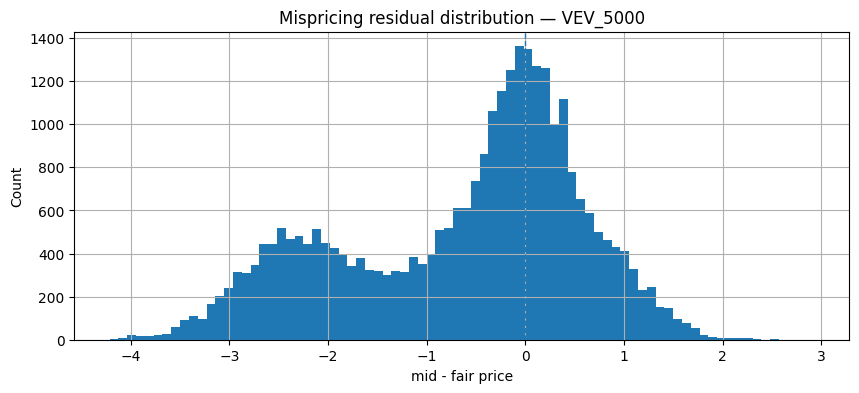

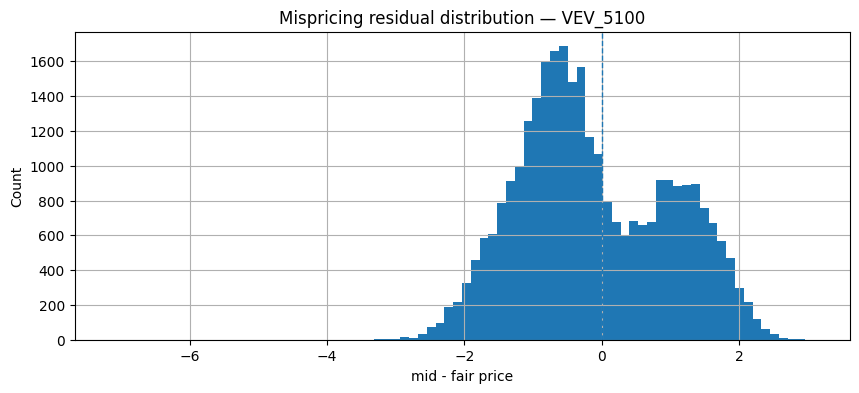

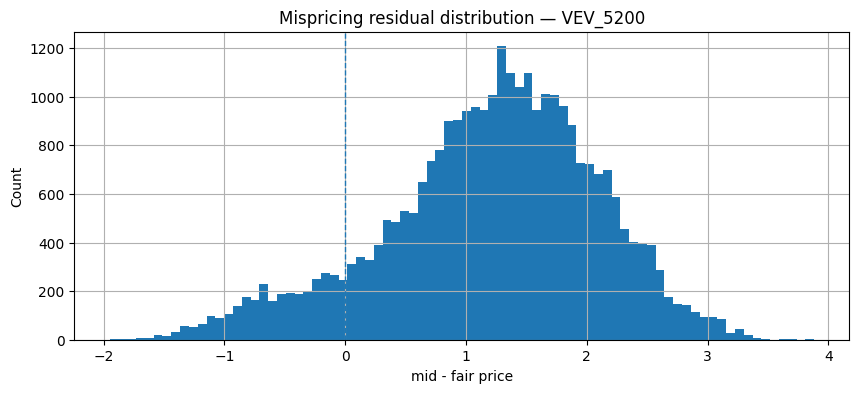

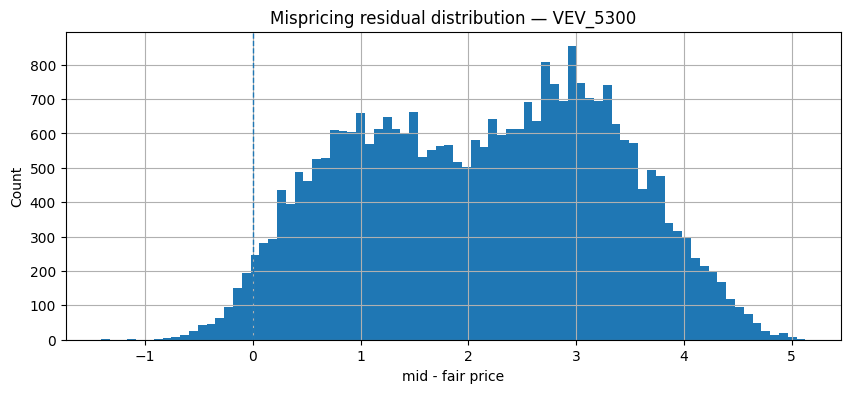

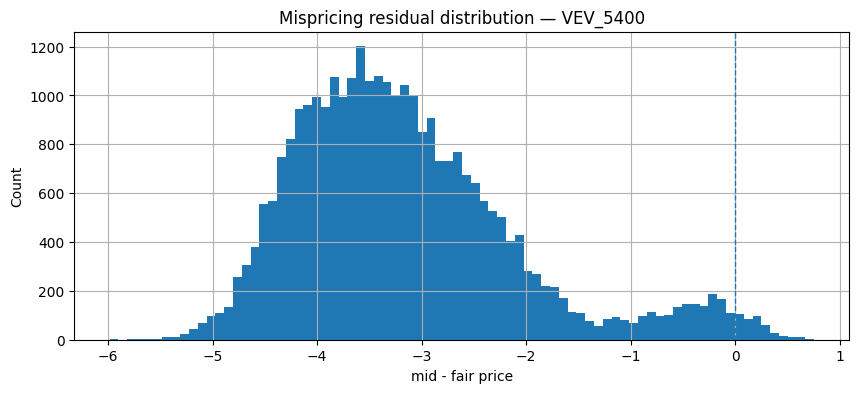

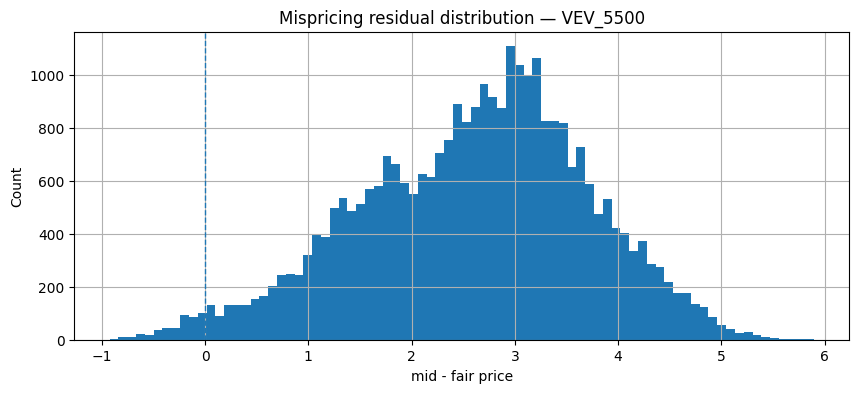

In [126]:
for strike in sorted(mis["strike"].unique()):
    df = mis[mis["strike"] == strike].dropna(subset=["residual"])

    plt.figure(figsize=(10, 4))
    plt.hist(df["residual"], bins=80)
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.title(f"Mispricing residual distribution — VEV_{strike}")
    plt.xlabel("mid - fair price")
    plt.ylabel("Count")
    plt.show()

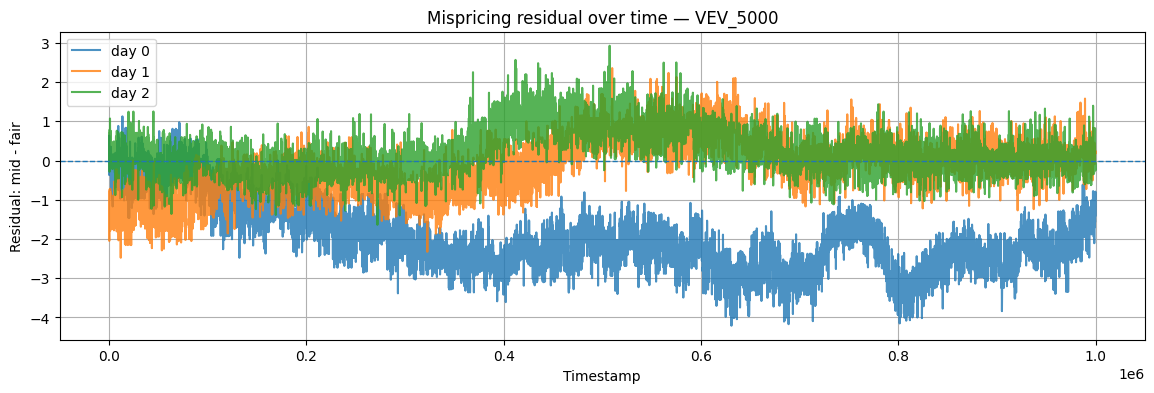

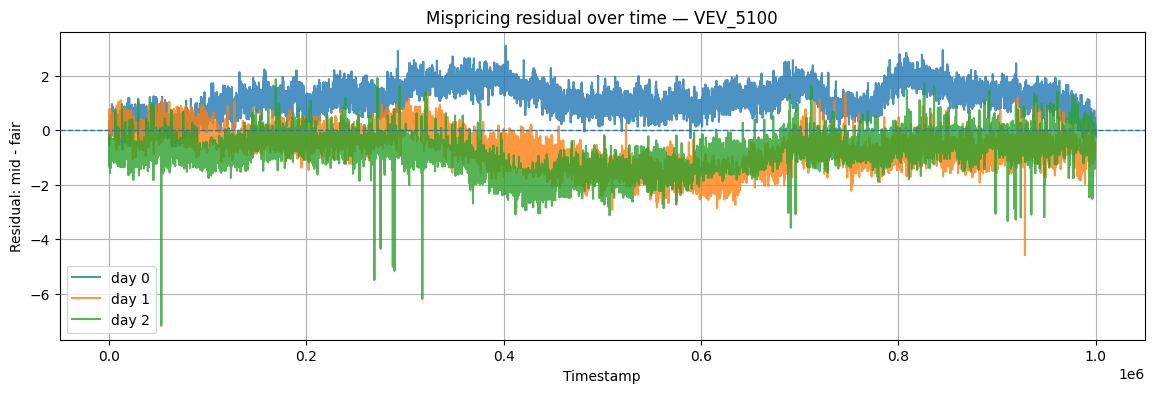

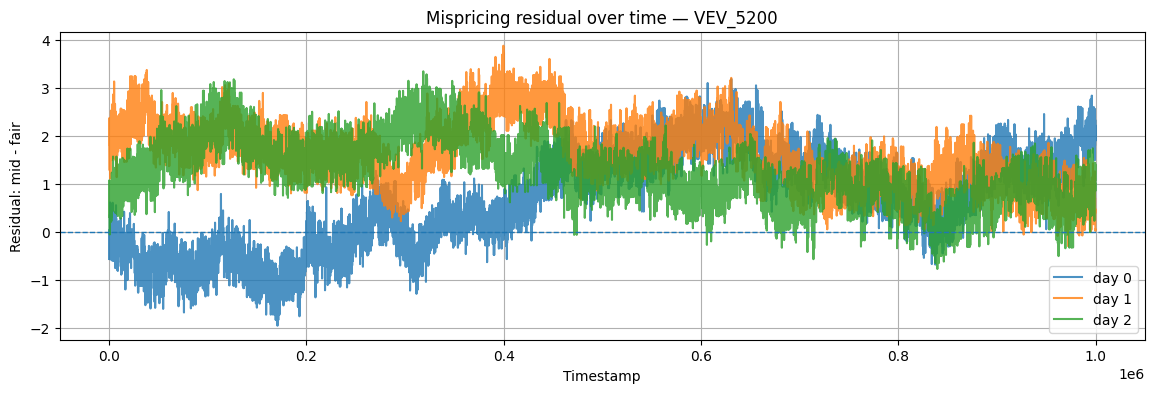

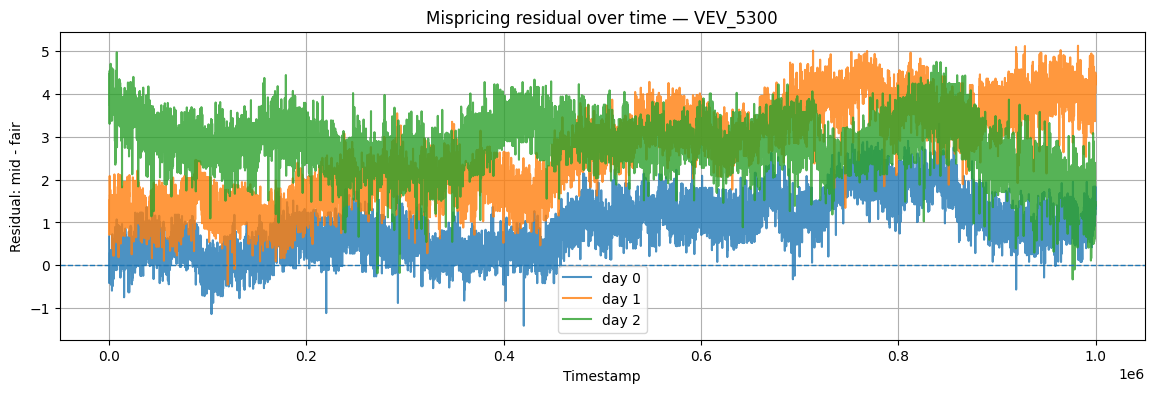

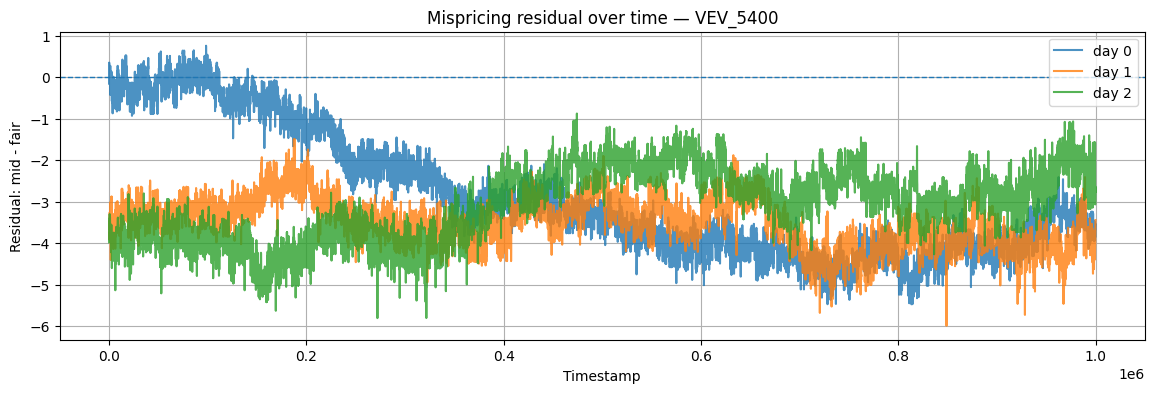

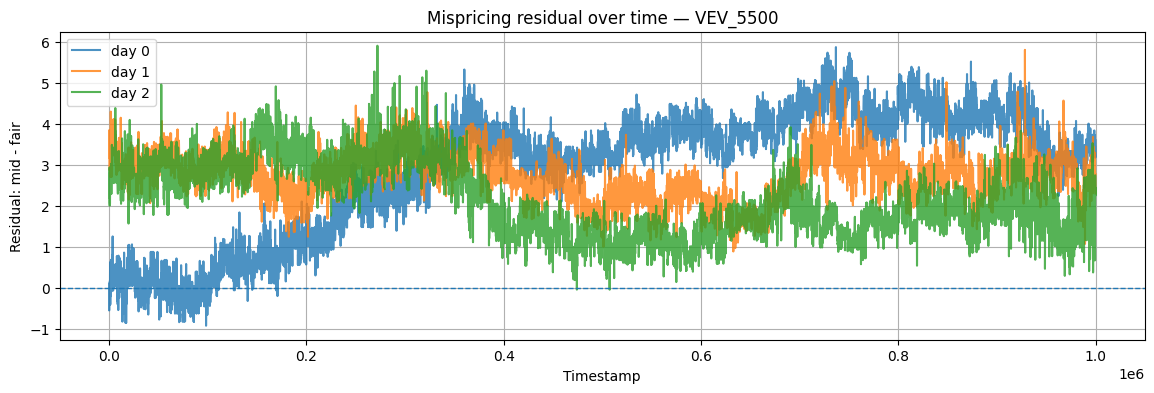

In [127]:
for strike in sorted(mis["strike"].unique()):
    df = mis[mis["strike"] == strike]

    plt.figure(figsize=(14, 4))

    for day in sorted(df["day"].unique()):
        ddf = df[df["day"] == day]
        plt.plot(ddf["timestamp"], ddf["residual"], label=f"day {day}", alpha=0.8)

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"Mispricing residual over time — VEV_{strike}")
    plt.xlabel("Timestamp")
    plt.ylabel("Residual: mid - fair")
    plt.legend()
    plt.show()

In [128]:
mis_acf_rows = []

for strike in sorted(mis["strike"].unique()):
    for day in sorted(mis["day"].unique()):
        df = mis[(mis["strike"] == strike) & (mis["day"] == day)].dropna(subset=["residual"])

        if len(df) < 100:
            continue

        for lag in [1, 2, 3, 5, 10, 20, 50, 100]:
            mis_acf_rows.append({
                "strike": strike,
                "day": day,
                "lag": lag,
                "acf": df["residual"].autocorr(lag=lag),
            })

mis_acf = pd.DataFrame(mis_acf_rows)

display(
    mis_acf.pivot_table(
        index=["strike", "lag"],
        columns="day",
        values="acf"
    )
)

day                0         1         2
strike lag                              
5000   1    0.846898  0.754507  0.637993
       2    0.839167  0.751650  0.639639
       3    0.835731  0.746908  0.630931
       5    0.830850  0.742765  0.633895
       10   0.823528  0.732008  0.620106
       20   0.811801  0.725795  0.613548
       50   0.792208  0.705580  0.598900
       100  0.760894  0.689025  0.584914
5100   1    0.694466  0.730205  0.573572
       2    0.685284  0.730032  0.578708
       3    0.680262  0.728966  0.570701
       5    0.679322  0.728752  0.578028
       10   0.673703  0.721266  0.566888
       20   0.661541  0.717710  0.565685
       50   0.635093  0.700629  0.555910
       100  0.589389  0.687662  0.545364
5200   1    0.910107  0.782996  0.796239
       2    0.906649  0.775111  0.783896
       3    0.905392  0.771498  0.779807
       5    0.902510  0.764345  0.774985
       10   0.899170  0.760035  0.761318
       20   0.892447  0.736779  0.744364
       50   0.881064  0.712553  0.724096
       100  0.861266  0.671688  0.685148
5300   1    0.756828  0.894488  0.548562
       2    0.748253  0.894112  0.538513
       3    0.746256  0.891448  0.530300
       5    0.741201  0.890414  0.536128
       10   0.742396  0.889279  0.523917
       20   0.733123  0.886738  0.515473
       50   0.713322  0.879314  0.486435
       100  0.680542  0.870305  0.443106
5400   1    0.981346  0.852919  0.915170
       2    0.978956  0.831378  0.905221
       3    0.977645  0.818826  0.894689
       5    0.975446  0.802687  0.887097
       10   0.972467  0.775452  0.869455
       20   0.968722  0.745458  0.856690
       50   0.965644  0.707349  0.831238
       100  0.960518  0.651395  0.804222
5500   1    0.974892  0.821897  0.894335
       2    0.971611  0.804303  0.886407
       3    0.969837  0.787756  0.877230
       5    0.966663  0.768169  0.871931
       10   0.962015  0.737984  0.853841
       20   0.956009  0.697726  0.843064
       50   0.950200  0.647976  0.816600
       100  0.941684  0.577893  0.790744

In [129]:
half_life_rows = []

for strike in sorted(mis["strike"].unique()):
    for day in sorted(mis["day"].unique()):
        df = mis[(mis["strike"] == strike) & (mis["day"] == day)].copy()
        df = df.dropna(subset=["residual"])

        df["resid_lag"] = df["residual"].shift(1)
        df["resid_change"] = df["residual"] - df["resid_lag"]

        valid = df.dropna(subset=["residual", "resid_lag", "resid_change"])

        if len(valid) < 100:
            continue

        X = sm.add_constant(valid["resid_lag"])
        y = valid["resid_change"]

        model = sm.OLS(y, X).fit()
        beta = model.params["resid_lag"]

        # For residual_change = beta * residual_lag, mean reversion speed = -beta
        # half-life approx = ln(0.5) / ln(1 + beta), if 0 < 1+beta < 1
        if -1 < beta < 0:
            half_life = np.log(0.5) / np.log(1 + beta)
        else:
            half_life = np.nan

        half_life_rows.append({
            "strike": strike,
            "day": day,
            "beta_change_on_lag": beta,
            "half_life_ticks": half_life,
            "r2": model.rsquared,
        })

half_life_df = pd.DataFrame(half_life_rows)

display(half_life_df)
display(
    half_life_df.groupby("strike").agg(
        beta_mean=("beta_change_on_lag", "mean"),
        half_life_mean=("half_life_ticks", "mean"),
        half_life_median=("half_life_ticks", "median"),
        r2_mean=("r2", "mean"),
    )
)

,strike,day,beta_change_on_lag,half_life_ticks,r2
0,5000,0,-0.153324,4.164616,0.076793
1,5000,1,-0.245676,2.458549,0.122959
2,5000,2,-0.361993,1.542365,0.180985
3,5100,0,-0.305576,1.900736,0.152818
4,5100,1,-0.269922,2.203233,0.135049
5,5100,2,-0.426391,1.247099,0.213163
6,5200,0,-0.089839,7.363461,0.044889
7,5200,1,-0.216777,2.836844,0.108243
8,5200,2,-0.203835,3.040797,0.101964
9,5300,0,-0.243163,2.487899,0.121576


,beta_mean,half_life_mean,half_life_median,r2_mean
strike,,,,
5000,-0.253664,2.721843,2.458549,0.126913
5100,-0.333963,1.783689,1.900736,0.167010
5200,-0.170150,4.413701,3.040797,0.085032
5300,-0.266669,3.286523,2.487899,0.133301
5400,-0.083586,16.236122,7.814851,0.041826
5500,-0.103044,12.266803,6.205671,0.051568


In [130]:
bucket_rows = []

bucket_edges = [-np.inf, -1.0, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1.0, np.inf]

tmp = mis.copy()
tmp["next_residual"] = tmp.groupby(["product", "day"])["residual"].shift(-1)
tmp["next_resid_change"] = tmp["next_residual"] - tmp["residual"]
tmp["resid_spread_bucket"] = pd.cut(tmp["resid_over_spread"], bins=bucket_edges)

bucket_stats = tmp.groupby(["strike", "resid_spread_bucket"]).agg(
    count=("residual", "count"),
    avg_residual=("residual", "mean"),
    avg_next_change=("next_resid_change", "mean"),
    avg_next_residual=("next_residual", "mean"),
).reset_index()

display(bucket_stats)

,strike,resid_spread_bucket,count,avg_residual,avg_next_change,avg_next_residual
0,5000,"(-inf, -1.0]",49,-2.890073,0.585466,-2.304607
1,5000,"(-1.0, -0.75]",40,-2.500934,0.446958,-2.053976
2,5000,"(-0.75, -0.5]",1068,-3.135705,0.261522,-2.874182
3,5000,"(-0.5, -0.25]",6746,-2.228234,0.036521,-2.191713
4,5000,"(-0.25, 0.0]",11027,-0.534865,0.084446,-0.450368
5,5000,"(0.0, 0.25]",10588,0.473768,-0.117240,0.356555
6,5000,"(0.25, 0.5]",440,1.549374,-0.549357,1.000017
7,5000,"(0.5, 0.75]",17,1.935452,-1.045014,0.890437
8,5000,"(0.75, 1.0]",1,2.252526,-2.373780,-0.121254
9,5100,"(-inf, -1.0]",36,-2.941440,1.893055,-1.048385


In [131]:
tmp = mis.copy()
tmp["next_residual"] = tmp.groupby(["product", "day"])["residual"].shift(-1)

# Mean reversion event:
# if residual > 0, next residual is smaller
# if residual < 0, next residual is larger
tmp["mean_reverted_next"] = np.where(
    tmp["residual"] > 0,
    tmp["next_residual"] < tmp["residual"],
    np.where(
        tmp["residual"] < 0,
        tmp["next_residual"] > tmp["residual"],
        np.nan
    )
)

mean_reversion_probability = tmp.groupby("strike").agg(
    mean_revert_prob=("mean_reverted_next", "mean"),
    count=("mean_reverted_next", "count"),
    avg_abs_residual=("residual", lambda x: x.abs().mean()),
    avg_abs_resid_over_spread=("abs_resid_over_spread", "mean"),
).reset_index()

display(mean_reversion_probability)

,strike,mean_revert_prob,count,avg_abs_residual,avg_abs_resid_over_spread
0,5000,0.545403,29976,1.009252,0.171638
1,5100,0.505867,30000,0.940336,0.227377
2,5200,0.479333,30000,1.317832,0.473648
3,5300,0.476500,30000,2.142230,1.063329
4,5400,0.466933,30000,3.158024,2.551068
5,5500,0.467333,30000,2.610610,2.405234


In [132]:
decay_rows = []

for horizon in [1, 2, 5, 10, 20, 50, 100]:
    mis[f"future_residual_{horizon}"] = mis.groupby(["product", "day"])["residual"].shift(-horizon)
    mis[f"resid_change_{horizon}"] = mis[f"future_residual_{horizon}"] - mis["residual"]

for strike in sorted(mis["strike"].unique()):
    df = mis[mis["strike"] == strike]

    for horizon in [1, 2, 5, 10, 20, 50, 100]:
        valid = df.dropna(subset=["residual", f"future_residual_{horizon}", f"resid_change_{horizon}"])

        if len(valid) == 0:
            continue

        decay_rows.append({
            "strike": strike,
            "horizon": horizon,
            "corr_resid_future_change": valid["residual"].corr(valid[f"resid_change_{horizon}"]),
            "avg_change_when_overpriced": valid.loc[valid["residual"] > 0, f"resid_change_{horizon}"].mean(),
            "avg_change_when_underpriced": valid.loc[valid["residual"] < 0, f"resid_change_{horizon}"].mean(),
            "avg_abs_resid_now": valid["residual"].abs().mean(),
            "avg_abs_resid_future": valid[f"future_residual_{horizon}"].abs().mean(),
        })

residual_decay = pd.DataFrame(decay_rows)

display(
    residual_decay.pivot_table(
        index="strike",
        columns="horizon",
        values="corr_resid_future_change"
    )
)

display(
    residual_decay.pivot_table(
        index="strike",
        columns="horizon",
        values="avg_abs_resid_future"
    )
)

horizon,1,2,5,10,20,50,100
strike,,,,,,,
5000,-0.198157,-0.200140,-0.203575,-0.207716,-0.211167,-0.218037,-0.225135
5100,-0.229602,-0.229799,-0.230544,-0.233345,-0.234756,-0.239481,-0.244289
5200,-0.240983,-0.246382,-0.251984,-0.256939,-0.267136,-0.280664,-0.304077
5300,-0.217412,-0.219565,-0.222184,-0.223919,-0.227350,-0.236589,-0.247809
5400,-0.146825,-0.156543,-0.170867,-0.183938,-0.197171,-0.218512,-0.246777
5500,-0.163514,-0.171755,-0.185415,-0.198647,-0.211899,-0.231640,-0.256100


horizon,1,2,5,10,20,50,100
strike,,,,,,,
5000,1.009292,1.009304,1.009421,1.009593,1.009937,1.010983,1.013180
5100,0.940398,0.940434,0.940558,0.940805,0.941237,0.942740,0.945544
5200,1.317873,1.317908,1.318007,1.318245,1.318621,1.319336,1.320460
5300,2.142244,2.142297,2.142380,2.142480,2.142692,2.143735,2.145764
5400,3.158077,3.158138,3.158341,3.158703,3.159316,3.160737,3.163641
5500,2.610659,2.610698,2.610879,2.611200,2.611708,2.612577,2.614698


In [133]:
regime = mis.copy()

for threshold in [0.25, 0.5, 0.75, 1.0]:
    regime[f"signal_{threshold}"] = np.where(
        regime["residual"] > threshold * regime["spread"],
        "overpriced",
        np.where(
            regime["residual"] < -threshold * regime["spread"],
            "underpriced",
            "neutral"
        )
    )

regime_persistence_rows = []

for strike in sorted(regime["strike"].unique()):
    df = regime[regime["strike"] == strike].copy()

    for threshold in [0.25, 0.5, 0.75, 1.0]:
        col = f"signal_{threshold}"
        df[f"next_{col}"] = df.groupby("day")[col].shift(-1)

        active = df[df[col] != "neutral"]

        if len(active) == 0:
            persist = np.nan
            count_active = 0
        else:
            persist = (active[col] == active[f"next_{col}"]).mean()
            count_active = len(active)

        regime_persistence_rows.append({
            "strike": strike,
            "threshold_mult_spread": threshold,
            "active_count": count_active,
            "same_regime_next_frac": persist,
        })

regime_persistence = pd.DataFrame(regime_persistence_rows)

display(
    regime_persistence.pivot_table(
        index=["strike", "threshold_mult_spread"],
        values=["active_count", "same_regime_next_frac"]
    )
)

active_count  same_regime_next_frac
strike threshold_mult_spread                                     
5000   0.25                         8361.0               0.854682
       0.50                         1175.0               0.469787
       0.75                           90.0               0.022222
       1.00                           49.0               0.020408
5100   0.25                        11802.0               0.738265
       0.50                         1276.0               0.263323
       0.75                          167.0               0.005988
       1.00                           81.0               0.012346
5200   0.25                        23094.0               0.905084
       0.50                        12765.0               0.775872
       0.75                         4448.0               0.533723
       1.00                         1141.0               0.268186
5300   0.25                        26863.0               0.958940
       0.50                        23049.0               0.927242
       0.75                        19014.0               0.906227
       1.00                        15479.0               0.884295
5400   0.25                        28986.0               0.991030
       0.50                        28476.0               0.993433
       0.75                        28100.0               0.993701
       1.00                        27578.0               0.987671
5500   0.25                        29305.0               0.989149
       0.50                        28695.0               0.989336
       0.75                        27803.0               0.984066
       1.00                        26819.0               0.976024

In [134]:
entry_exit_rows = []

entry_thresholds = [0.25, 0.5, 0.75, 1.0]
exit_thresholds = [0.0, 0.25, 0.5]
max_holds = [5, 10, 20, 50]

for strike in sorted(mis["strike"].unique()):
    df = mis[mis["strike"] == strike].copy()
    df = df.sort_values(["day", "timestamp"])

    for entry_mult in entry_thresholds:
        for exit_mult in exit_thresholds:
            for max_hold in max_holds:
                trade_pnls = []
                hold_times = []

                for day in sorted(df["day"].unique()):
                    ddf = df[df["day"] == day].reset_index(drop=True)

                    i = 0
                    while i < len(ddf) - 1:
                        row = ddf.iloc[i]

                        if pd.isna(row["residual"]) or pd.isna(row["spread"]):
                            i += 1
                            continue

                        entry_threshold = entry_mult * row["spread"]

                        if abs(row["residual"]) <= entry_threshold:
                            i += 1
                            continue

                        # residual < 0 => long; residual > 0 => short
                        position = 1 if row["residual"] < 0 else -1
                        entry_price = row["mid"]

                        exit_i = None

                        for j in range(i + 1, min(i + max_hold + 1, len(ddf))):
                            future = ddf.iloc[j]

                            if pd.isna(future["residual"]) or pd.isna(future["spread"]):
                                continue

                            # Exit once residual compresses inside exit threshold
                            if abs(future["residual"]) <= exit_mult * future["spread"]:
                                exit_i = j
                                break

                        if exit_i is None:
                            exit_i = min(i + max_hold, len(ddf) - 1)

                        exit_price = ddf.iloc[exit_i]["mid"]
                        pnl = position * (exit_price - entry_price)

                        trade_pnls.append(pnl)
                        hold_times.append(exit_i - i)

                        i = exit_i + 1

                if len(trade_pnls) == 0:
                    entry_exit_rows.append({
                        "strike": strike,
                        "entry_mult": entry_mult,
                        "exit_mult": exit_mult,
                        "max_hold": max_hold,
                        "num_trades": 0,
                        "avg_pnl": np.nan,
                        "median_pnl": np.nan,
                        "win_rate": np.nan,
                        "avg_hold": np.nan,
                    })
                else:
                    entry_exit_rows.append({
                        "strike": strike,
                        "entry_mult": entry_mult,
                        "exit_mult": exit_mult,
                        "max_hold": max_hold,
                        "num_trades": len(trade_pnls),
                        "avg_pnl": np.mean(trade_pnls),
                        "median_pnl": np.median(trade_pnls),
                        "win_rate": np.mean(np.array(trade_pnls) > 0),
                        "avg_hold": np.mean(hold_times),
                    })

entry_exit_test = pd.DataFrame(entry_exit_rows)

display(
    entry_exit_test.sort_values(
        ["avg_pnl", "num_trades"],
        ascending=[False, False]
    ).head(30)
)

,strike,entry_mult,exit_mult,max_hold,num_trades,avg_pnl,median_pnl,win_rate,avg_hold
38,5000,1.00,0.00,20,45,2.777778,2.00,0.711111,20.000000
43,5000,1.00,0.25,50,44,2.715909,2.00,0.772727,26.909091
42,5000,1.00,0.25,20,46,2.695652,2.00,0.847826,12.978261
39,5000,1.00,0.00,50,38,2.657895,3.00,0.657895,50.000000
40,5000,1.00,0.25,5,47,2.117021,2.00,0.893617,4.085106
36,5000,1.00,0.00,5,47,2.021277,1.50,0.872340,5.000000
26,5000,0.75,0.00,20,75,2.000000,1.50,0.693333,20.000000
31,5000,0.75,0.25,50,73,1.945205,2.00,0.726027,24.328767
30,5000,0.75,0.25,20,80,1.875000,2.00,0.812500,12.200000
24,5000,0.75,0.00,5,86,1.813953,1.50,0.790698,5.000000


In [135]:
mispricing_decision_table = (
    mispricing_distribution[
        [
            "product", "strike", "resid_mean", "resid_median", "resid_std",
            "resid_q05", "resid_q95",
            "mean_abs_resid_over_spread", "q95_abs_resid_over_spread"
        ]
    ]
    .merge(
        mean_reversion_probability[
            ["strike", "mean_revert_prob", "avg_abs_residual", "avg_abs_resid_over_spread"]
        ],
        on="strike",
        how="left"
    )
    .merge(
        half_life_df.groupby("strike").agg(
            half_life_mean=("half_life_ticks", "mean"),
            half_life_median=("half_life_ticks", "median"),
            beta_mean=("beta_change_on_lag", "mean"),
            r2_mean=("r2", "mean"),
        ).reset_index(),
        on="strike",
        how="left"
    )
    .merge(
        regime_persistence.groupby("strike").agg(
            max_active_count=("active_count", "max"),
            max_same_regime_next_frac=("same_regime_next_frac", "max"),
        ).reset_index(),
        on="strike",
        how="left"
    )
    .sort_values("strike")
)

display(mispricing_decision_table)

,product,strike,resid_mean,resid_median,resid_std,resid_q05,resid_q95,mean_abs_resid_over_spread,q95_abs_resid_over_spread,mean_revert_prob,avg_abs_residual,avg_abs_resid_over_spread,half_life_mean,half_life_median,beta_mean,r2_mean,max_active_count,max_same_regime_next_frac
0,VEV_5000,5000,-0.626737,-0.284945,1.217082,-2.843047,1.034802,0.171638,0.482612,0.545403,1.009252,0.171638,2.721843,2.458549,-0.253664,0.126913,8361,0.854682
1,VEV_5100,5100,-0.122533,-0.322470,1.099347,-1.765644,1.741088,0.227377,0.484912,0.505867,0.940336,0.227377,1.783689,1.900736,-0.333963,0.167010,11802,0.738265
2,VEV_5200,5200,1.201563,1.287671,0.890633,-0.532083,2.519539,0.473648,0.947860,0.479333,1.317832,0.473648,4.413701,3.040797,-0.170150,0.085032,23094,0.905084
3,VEV_5300,5300,2.132264,2.206923,1.192424,0.230340,3.990669,1.063329,2.071076,0.476500,2.142230,1.063329,3.286523,2.487899,-0.266669,0.133301,26863,0.958940
4,VEV_5400,5400,-3.152573,-3.329431,1.087320,-4.542626,-0.636083,2.551068,4.395549,0.466933,3.158024,2.551068,16.236122,7.814851,-0.083586,0.041826,28986,0.993701
5,VEV_5500,5500,2.602569,2.711102,1.109759,0.658997,4.331247,2.405234,4.224948,0.467333,2.610610,2.405234,12.266803,6.205671,-0.103044,0.051568,29305,0.989336


## Cross-voucher arbitrage

In [136]:
arb = fv_loo.copy()
arb = arb.sort_values(["day", "timestamp", "strike"])

arb["residual"] = arb["price_residual_loo"]

resid_wide = arb.pivot_table(
    index=["day", "timestamp"],
    columns="strike",
    values="residual"
).sort_index()

mid_wide = arb.pivot_table(
    index=["day", "timestamp"],
    columns="strike",
    values="mid"
).sort_index()

spread_wide = arb.pivot_table(
    index=["day", "timestamp"],
    columns="strike",
    values="spread"
).sort_index()

display(resid_wide.head())
display(mid_wide.head())
display(spread_wide.head())

strike             5000      5100      5200      5300      5400      5500
day timestamp                                                            
0   0          0.102670  0.029609 -0.559862  0.676905 -0.152256 -0.028399
    100        0.635243 -0.520454  0.042849  0.166763  0.349139 -0.551670
    200       -0.364757  0.329359  0.010160 -0.410380  0.062987  0.107780
    300        0.135243 -0.101602  0.026781 -0.116886  0.208598 -0.224725
    400       -0.364757  0.329359  0.010160 -0.410380  0.062987  0.107780

strike          5000   5100   5200  5300  5400  5500
day timestamp                                       
0   0          257.0  171.5  101.5  53.0  23.0   8.5
    100        258.0  172.0  102.5  53.0  23.5   8.5
    200        257.0  172.0  102.5  53.0  23.5   8.5
    300        257.5  172.0  102.5  53.0  23.5   8.5
    400        257.0  172.0  102.5  53.0  23.5   8.5

strike         5000  5100  5200  5300  5400  5500
day timestamp                                    
0   0           6.0   5.0   3.0   2.0   2.0   1.0
    100         6.0   4.0   3.0   2.0   1.0   1.0
    200         6.0   4.0   3.0   2.0   1.0   1.0
    300         7.0   4.0   3.0   2.0   1.0   1.0
    400         6.0   4.0   3.0   2.0   1.0   1.0

In [137]:
pairs = [
    (5000, 5100),
    (5100, 5200),
    (5200, 5300),
    (5300, 5400),
    (5400, 5500),
    (5200, 5400),
    (5300, 5500),
]

pair_rows = []

for k1, k2 in pairs:
    pair_df = pd.DataFrame(index=resid_wide.index)

    pair_df["k1"] = k1
    pair_df["k2"] = k2

    # Relative mispricing spread:
    # positive means k1 is richer than k2 relative to smile residuals
    pair_df["pair_resid"] = resid_wide[k1] - resid_wide[k2]

    # Combined transaction cost proxy
    pair_df["combined_spread"] = spread_wide[k1] + spread_wide[k2]
    pair_df["combined_half_spread"] = pair_df["combined_spread"] / 2

    pair_df["mid_k1"] = mid_wide[k1]
    pair_df["mid_k2"] = mid_wide[k2]

    pair_df["spread_k1"] = spread_wide[k1]
    pair_df["spread_k2"] = spread_wide[k2]

    pair_df = pair_df.reset_index()

    pair_rows.append(pair_df)

pair_data = pd.concat(pair_rows, ignore_index=True)

display(pair_data.head())

,day,timestamp,k1,k2,pair_resid,combined_spread,combined_half_spread,mid_k1,mid_k2,spread_k1,spread_k2
0,0,0,5000,5100,0.073061,11.0,5.5,257.0,171.5,6.0,5.0
1,0,100,5000,5100,1.155696,10.0,5.0,258.0,172.0,6.0,4.0
2,0,200,5000,5100,-0.694116,10.0,5.0,257.0,172.0,6.0,4.0
3,0,300,5000,5100,0.236845,11.0,5.5,257.5,172.0,7.0,4.0
4,0,400,5000,5100,-0.694116,10.0,5.0,257.0,172.0,6.0,4.0


In [138]:
pair_distribution = pair_data.groupby(["k1", "k2"]).agg(
    rows=("pair_resid", "count"),
    pair_resid_mean=("pair_resid", "mean"),
    pair_resid_median=("pair_resid", "median"),
    pair_resid_std=("pair_resid", "std"),
    pair_resid_q05=("pair_resid", lambda x: x.quantile(0.05)),
    pair_resid_q95=("pair_resid", lambda x: x.quantile(0.95)),
    mean_abs_pair_resid=("pair_resid", lambda x: x.abs().mean()),
    q95_abs_pair_resid=("pair_resid", lambda x: x.abs().quantile(0.95)),
    combined_spread_mean=("combined_spread", "mean"),
    combined_half_spread_mean=("combined_half_spread", "mean"),
).reset_index()

display(pair_distribution)

,k1,k2,rows,pair_resid_mean,pair_resid_median,pair_resid_std,pair_resid_q05,pair_resid_q95,mean_abs_pair_resid,q95_abs_pair_resid,combined_spread_mean,combined_half_spread_mean
0,5000,5100,29976,-0.506918,0.027714,2.285348,-4.520162,2.778764,1.857523,4.531095,10.342707,5.171354
1,5100,5200,30000,-1.324096,-1.570956,1.659646,-3.728928,1.765861,1.832701,3.728928,7.183967,3.591983
2,5200,5300,30000,-0.930701,-0.935331,1.343336,-3.213575,1.221194,1.323247,3.214946,4.994933,2.497467
3,5200,5400,30000,4.354136,4.752179,1.768174,0.091670,6.491723,4.410129,6.491723,4.269567,2.134783
4,5300,5400,30000,5.284837,5.499598,1.889922,1.118896,8.031263,5.290285,8.031263,3.488233,1.744117
5,5300,5500,30000,-0.470305,-0.354637,1.696056,-3.233944,2.004340,1.473131,3.243713,3.256567,1.628283
6,5400,5500,30000,-5.755142,-6.098060,2.129214,-8.719686,-1.384274,5.768183,8.719686,2.531200,1.265600


In [139]:
pair_data["abs_pair_resid"] = pair_data["pair_resid"].abs()

pair_data["pair_gt_half_spread"] = (
    pair_data["abs_pair_resid"] > pair_data["combined_half_spread"]
)

pair_data["pair_gt_full_spread"] = (
    pair_data["abs_pair_resid"] > pair_data["combined_spread"]
)

pair_cost_check = pair_data.groupby(["k1", "k2"]).agg(
    rows=("pair_resid", "count"),
    mean_abs_pair_resid=("abs_pair_resid", "mean"),
    q95_abs_pair_resid=("abs_pair_resid", lambda x: x.quantile(0.95)),
    combined_spread_mean=("combined_spread", "mean"),
    combined_half_spread_mean=("combined_half_spread", "mean"),
    frac_gt_half_spread=("pair_gt_half_spread", "mean"),
    frac_gt_full_spread=("pair_gt_full_spread", "mean"),
).reset_index()

display(pair_cost_check)

,k1,k2,rows,mean_abs_pair_resid,q95_abs_pair_resid,combined_spread_mean,combined_half_spread_mean,frac_gt_half_spread,frac_gt_full_spread
0,5000,5100,29976,1.857523,4.531095,10.342707,5.171354,0.021600,0.001633
1,5100,5200,30000,1.832701,3.728928,7.183967,3.591983,0.087667,0.002600
2,5200,5300,30000,1.323247,3.214946,4.994933,2.497467,0.148067,0.002233
3,5200,5400,30000,4.410129,6.491723,4.269567,2.134783,0.897200,0.604867
4,5300,5400,30000,5.290285,8.031263,3.488233,1.744117,0.933367,0.833400
5,5300,5500,30000,1.473131,3.243713,3.256567,1.628283,0.409533,0.058200
6,5400,5500,30000,5.768183,8.719686,2.531200,1.265600,0.953900,0.917233


In [140]:
pair_acf_rows = []

for (k1, k2), df in pair_data.groupby(["k1", "k2"]):
    for day in sorted(df["day"].unique()):
        ddf = df[df["day"] == day].copy()
        ddf = ddf.dropna(subset=["pair_resid"])

        if len(ddf) < 100:
            continue

        for lag in [1, 2, 3, 5, 10, 20, 50, 100]:
            pair_acf_rows.append({
                "k1": k1,
                "k2": k2,
                "day": day,
                "lag": lag,
                "acf": ddf["pair_resid"].autocorr(lag=lag),
            })

pair_acf = pd.DataFrame(pair_acf_rows)

display(
    pair_acf.pivot_table(
        index=["k1", "k2", "lag"],
        columns="day",
        values="acf"
    )
)

day                   0         1         2
k1   k2   lag                              
5000 5100 1    0.780067  0.742742  0.623655
          2    0.771274  0.741053  0.626766
          3    0.767105  0.738539  0.619219
          5    0.763394  0.736196  0.625875
          10   0.756382  0.727058  0.613009
          20   0.744003  0.722555  0.609739
          50   0.721060  0.704871  0.597854
          100  0.683108  0.690448  0.585552
5100 5200 1    0.819728  0.737023  0.688432
          2    0.815738  0.732000  0.685645
          3    0.812982  0.735762  0.681879
          5    0.812931  0.734392  0.687069
          10   0.810312  0.730462  0.678450
          20   0.803368  0.719622  0.670893
          50   0.783754  0.700537  0.661996
          100  0.749059  0.671129  0.638703
5200 5300 1    0.702581  0.871941  0.650919
          2    0.692287  0.870990  0.639115
          3    0.691397  0.868152  0.636620
          5    0.682698  0.865364  0.634691
          10   0.680026  0.865270  0.623920
          20   0.663241  0.857029  0.609949
          50   0.635468  0.846258  0.581234
          100  0.584927  0.828282  0.534237
     5400 1    0.971310  0.693306  0.894029
          2    0.968849  0.665062  0.882206
          3    0.967610  0.642316  0.872865
          5    0.965286  0.618745  0.865331
          10   0.962047  0.587485  0.848076
          20   0.957840  0.531926  0.832429
          50   0.953451  0.476941  0.810061
          100  0.946956  0.397798  0.779844
5300 5400 1    0.960511  0.923011  0.838399
          2    0.957815  0.916468  0.823343
          3    0.956364  0.913794  0.811320
          5    0.954249  0.910041  0.804822
          10   0.952878  0.903582  0.789103
          20   0.949682  0.898332  0.772262
          50   0.944945  0.886716  0.744212
          100  0.936600  0.869178  0.703633
     5500 1    0.866537  0.851522  0.713992
          2    0.858968  0.851376  0.708825
          3    0.856778  0.844456  0.701771
          5    0.851073  0.840571  0.704485
          10   0.844467  0.835742  0.689248
          20   0.832302  0.824416  0.685370
          50   0.817782  0.809300  0.661563
          100  0.796494  0.791039  0.639092
5400 5500 1    0.979212  0.821164  0.907538
          2    0.976440  0.798820  0.898729
          3    0.974919  0.782314  0.888886
          5    0.972264  0.761908  0.882357
          10   0.968490  0.729023  0.864438
          20   0.963716  0.689062  0.852612
          50   0.959570  0.639710  0.826641
          100  0.953154  0.568984  0.800314

In [141]:
pair_half_life_rows = []

for (k1, k2), df in pair_data.groupby(["k1", "k2"]):
    for day in sorted(df["day"].unique()):
        ddf = df[df["day"] == day].copy()
        ddf = ddf.dropna(subset=["pair_resid"])

        ddf["pair_resid_lag"] = ddf["pair_resid"].shift(1)
        ddf["pair_resid_change"] = ddf["pair_resid"] - ddf["pair_resid_lag"]

        valid = ddf.dropna(subset=["pair_resid", "pair_resid_lag", "pair_resid_change"])

        if len(valid) < 100:
            continue

        X = sm.add_constant(valid["pair_resid_lag"])
        y = valid["pair_resid_change"]

        model = sm.OLS(y, X).fit()
        beta = model.params["pair_resid_lag"]

        if -1 < beta < 0:
            half_life = np.log(0.5) / np.log(1 + beta)
        else:
            half_life = np.nan

        pair_half_life_rows.append({
            "k1": k1,
            "k2": k2,
            "day": day,
            "beta_change_on_lag": beta,
            "half_life_ticks": half_life,
            "r2": model.rsquared,
        })

pair_half_life = pd.DataFrame(pair_half_life_rows)

display(pair_half_life)

pair_half_life_summary = pair_half_life.groupby(["k1", "k2"]).agg(
    beta_mean=("beta_change_on_lag", "mean"),
    half_life_mean=("half_life_ticks", "mean"),
    half_life_median=("half_life_ticks", "median"),
    r2_mean=("r2", "mean"),
).reset_index()

display(pair_half_life_summary)

,k1,k2,day,beta_change_on_lag,half_life_ticks,r2
0,5000,5100,0,-0.220102,2.788289,0.110160
1,5000,5100,1,-0.257421,2.328922,0.128820
2,5000,5100,2,-0.376318,1.468177,0.188137
3,5100,5200,0,-0.180056,3.491593,0.089896
4,5100,5200,1,-0.262909,2.272290,0.131408
5,5100,5200,2,-0.311594,1.856433,0.155815
6,5200,5300,0,-0.297398,1.963783,0.148684
7,5200,5300,1,-0.127943,5.063158,0.063905
8,5200,5300,2,-0.349166,1.613845,0.174648
9,5200,5400,0,-0.028765,23.748259,0.014421


,k1,k2,beta_mean,half_life_mean,half_life_median,r2_mean
0,5000,5100,-0.284614,2.195129,2.328922,0.142372
1,5100,5200,-0.251519,2.540105,2.272290,0.125706
2,5200,5300,-0.258169,2.880262,1.963783,0.129079
3,5200,5400,-0.147089,10.610055,6.188383,0.073519
4,5300,5400,-0.092721,9.917790,8.653625,0.046376
5,5300,5500,-0.189360,3.733665,4.311651,0.094701
6,5400,5500,-0.097438,14.466346,7.141335,0.048760


In [142]:
pair_pnl_data = pair_data.copy()
pair_pnl_data = pair_pnl_data.sort_values(["k1", "k2", "day", "timestamp"])

for horizon in [1, 2, 5, 10, 20, 50]:
    pair_pnl_data[f"future_mid_k1_{horizon}"] = (
        pair_pnl_data.groupby(["k1", "k2", "day"])["mid_k1"].shift(-horizon)
    )
    pair_pnl_data[f"future_mid_k2_{horizon}"] = (
        pair_pnl_data.groupby(["k1", "k2", "day"])["mid_k2"].shift(-horizon)
    )

pair_signal_rows = []

for (k1, k2), df in pair_pnl_data.groupby(["k1", "k2"]):
    for horizon in [1, 2, 5, 10, 20, 50]:
        valid = df.dropna(
            subset=[
                "pair_resid",
                f"future_mid_k1_{horizon}",
                f"future_mid_k2_{horizon}",
            ]
        ).copy()

        # If pair_resid > 0: short k1 / long k2
        # position_k1 = -sign(pair_resid), position_k2 = +sign(pair_resid)
        side = np.sign(valid["pair_resid"])
        pos_k1 = -side
        pos_k2 = side

        pnl_k1 = pos_k1 * (valid[f"future_mid_k1_{horizon}"] - valid["mid_k1"])
        pnl_k2 = pos_k2 * (valid[f"future_mid_k2_{horizon}"] - valid["mid_k2"])

        valid["pair_signal_pnl"] = pnl_k1 + pnl_k2

        pair_signal_rows.append({
            "k1": k1,
            "k2": k2,
            "horizon": horizon,
            "avg_pair_pnl": valid["pair_signal_pnl"].mean(),
            "median_pair_pnl": valid["pair_signal_pnl"].median(),
            "win_rate": (valid["pair_signal_pnl"] > 0).mean(),
            "num_obs": len(valid),
        })

pair_signal_pnl = pd.DataFrame(pair_signal_rows)

display(
    pair_signal_pnl.pivot_table(
        index=["k1", "k2"],
        columns="horizon",
        values="avg_pair_pnl"
    )
)

display(
    pair_signal_pnl.pivot_table(
        index=["k1", "k2"],
        columns="horizon",
        values="win_rate"
    )
)

horizon          1         2         5         10        20        50
k1   k2                                                              
5000 5100  0.061772  0.061342  0.063398  0.062897  0.063462  0.063968
5100 5200  0.026886  0.027339  0.029015  0.029162  0.031997  0.040067
5200 5300  0.074007  0.078282  0.082324  0.085719  0.097395  0.130737
     5400  0.006067  0.005401  0.003685 -0.001251 -0.015598 -0.044975
5300 5400  0.003200  0.003567  0.002568  0.000651 -0.003941 -0.015444
     5500  0.024219  0.024272  0.027480  0.020304  0.018437 -0.007789
5400 5500  0.003284  0.003901  0.004836  0.006340  0.008484  0.010637

horizon          1         2         5         10        20        50
k1   k2                                                              
5000 5100  0.293966  0.304905  0.322734  0.341020  0.366954  0.403033
5100 5200  0.297196  0.314896  0.342271  0.370437  0.397295  0.431558
5200 5300  0.313231  0.334167  0.367984  0.395162  0.424148  0.451390
     5400  0.295063  0.339201  0.391729  0.418452  0.443320  0.471089
5300 5400  0.230723  0.268454  0.318793  0.357357  0.394422  0.433266
     5500  0.230890  0.275055  0.334801  0.370103  0.404709  0.434606
5400 5500  0.150648  0.187938  0.234250  0.269503  0.309018  0.357186

In [143]:
pair_threshold_rows = []

threshold_multipliers = [0.25, 0.5, 0.75, 1.0]

for (k1, k2), df in pair_pnl_data.groupby(["k1", "k2"]):
    for mult in threshold_multipliers:
        for horizon in [1, 2, 5, 10, 20, 50]:
            valid = df.dropna(
                subset=[
                    "pair_resid",
                    f"future_mid_k1_{horizon}",
                    f"future_mid_k2_{horizon}",
                ]
            ).copy()

            threshold = mult * valid["combined_spread"]
            valid = valid[valid["pair_resid"].abs() > threshold].copy()

            if len(valid) == 0:
                pair_threshold_rows.append({
                    "k1": k1,
                    "k2": k2,
                    "threshold_mult_combined_spread": mult,
                    "horizon": horizon,
                    "num_trades": 0,
                    "avg_pair_pnl": np.nan,
                    "win_rate": np.nan,
                })
                continue

            side = np.sign(valid["pair_resid"])
            pos_k1 = -side
            pos_k2 = side

            pnl_k1 = pos_k1 * (valid[f"future_mid_k1_{horizon}"] - valid["mid_k1"])
            pnl_k2 = pos_k2 * (valid[f"future_mid_k2_{horizon}"] - valid["mid_k2"])

            valid["pair_signal_pnl"] = pnl_k1 + pnl_k2

            pair_threshold_rows.append({
                "k1": k1,
                "k2": k2,
                "threshold_mult_combined_spread": mult,
                "horizon": horizon,
                "num_trades": len(valid),
                "avg_pair_pnl": valid["pair_signal_pnl"].mean(),
                "win_rate": (valid["pair_signal_pnl"] > 0).mean(),
            })

pair_threshold_pnl = pd.DataFrame(pair_threshold_rows)

display(
    pair_threshold_pnl.pivot_table(
        index=["k1", "k2", "threshold_mult_combined_spread"],
        columns="horizon",
        values="avg_pair_pnl"
    )
)

display(
    pair_threshold_pnl.pivot_table(
        index=["k1", "k2", "threshold_mult_combined_spread"],
        columns="horizon",
        values="num_trades"
    )
)

horizon                                         1         2         5   \
k1   k2   threshold_mult_combined_spread                                 
5000 5100 0.25                            0.104630  0.109292  0.109516   
          0.50                            0.317130  0.341821  0.347994   
          0.75                            0.488372  0.482558  0.500000   
          1.00                            0.438776  0.479592  0.561224   
5100 5200 0.25                            0.087830  0.090364  0.089032   
          0.50                            0.169772  0.174715  0.185932   
          0.75                            0.288372  0.286047  0.267442   
          1.00                            0.423077  0.403846  0.339744   
5200 5300 0.25                            0.127203  0.130665  0.135441   
          0.50                            0.181603  0.188739  0.202952   
          0.75                            0.317757  0.322861  0.326640   
          1.00                            0.223881  0.268657  0.216418   
     5400 0.25                            0.002664  0.002218 -0.000072   
          0.50                            0.003716  0.003902  0.002584   
          0.75                            0.012112  0.012133  0.012595   
          1.00                            0.032213  0.035025  0.035122   
5300 5400 0.25                            0.004474  0.004213  0.003169   
          0.50                            0.002607  0.002018  0.001036   
          0.75                            0.005279  0.005691  0.004386   
          1.00                            0.006760  0.007541  0.006683   
     5500 0.25                            0.036750  0.038718  0.041386   
          0.50                            0.056496  0.061223  0.062251   
          0.75                            0.092870  0.101463  0.112909   
          1.00                            0.147766  0.156644  0.182131   
5400 5500 0.25                            0.002386  0.002747  0.003435   
          0.50                            0.001835  0.002184  0.002902   
          0.75                            0.002153  0.002491  0.003542   
          1.00                            0.002653  0.002981  0.004636   

horizon                                         10        20        50  
k1   k2   threshold_mult_combined_spread                                
5000 5100 0.25                            0.115927  0.123847  0.149104  
          0.50                            0.363426  0.429784  0.570216  
          0.75                            0.412791  0.505814  0.453488  
          1.00                            0.438776  0.602041  0.540816  
5100 5200 0.25                            0.093915  0.095187  0.120421  
          0.50                            0.187072  0.194867  0.202091  
          0.75                            0.258140  0.365116  0.423256  
          1.00                            0.365385  0.391026  0.237179  
5200 5300 0.25                            0.145562  0.163315  0.204866  
          0.50                            0.210693  0.241695  0.332917  
          0.75                            0.389262  0.440188  0.676590  
          1.00                            0.298507  0.343284  0.619403  
     5400 0.25                           -0.005101 -0.015893 -0.037102  
          0.50                            0.000707 -0.004021 -0.014625  
          0.75                            0.013308  0.012363  0.013297  
          1.00                            0.031636  0.032851  0.058508  
5300 5400 0.25                            0.000575 -0.003244 -0.012440  
          0.50                           -0.001001 -0.004241 -0.012262  
          0.75                            0.003399 -0.001140 -0.009659  
          1.00                            0.005846  0.001944 -0.005406  
     5500 0.25                            0.036697  0.031763 -0.022115  
          0.50                            0.062072  0.044446 -0.014278  
          0.75             

horizon                                        1        2        5        10  \
k1   k2   threshold_mult_combined_spread                                       
5000 5100 0.25                             9438.0   9438.0   9437.0   9437.0   
          0.50                              648.0    648.0    648.0    648.0   
          0.75                               86.0     86.0     86.0     86.0   
          1.00                               49.0     49.0     49.0     49.0   
5100 5200 0.25                            14437.0  14436.0  14433.0  14428.0   
          0.50                             2630.0   2630.0   2630.0   2630.0   
          0.75                              215.0    215.0    215.0    215.0   
          1.00                               78.0     78.0     78.0     78.0   
5200 5300 0.25                            13903.0  13902.0  13899.0  13891.0   
          0.50                             4441.0   4440.0   4437.0   4433.0   
          0.75                              749.0    748.0    747.0    745.0   
          1.00                               67.0     67.0     67.0     67.0   
     5400 0.25                            27962.0  27959.0  27950.0  27935.0   
          0.50                            26913.0  26910.0  26901.0  26886.0   
          0.75                            24068.0  24066.0  24057.0  24045.0   
          1.00                            18145.0  18144.0  18137.0  18128.0   
5300 5400 0.25                            28724.0  28721.0  28712.0  28697.0   
          0.50                            27998.0  27995.0  27986.0  27971.0   
          0.75                            26802.0  26799.0  26790.0  26775.0   
          1.00                            25000.0  24997.0  24988.0  24975.0   
     5500 0.25                            21129.0  21127.0  21118.0  21105.0   
          0.50                            12284.0  12283.0  12281.0  12276.0   
          0.75                             5470.0   5470.0   5469.0   5467.0   
          1.00                             1746.0   1746.0   1746.0   1746.0   
5400 5500 0.25                            29124.0  29121.0  29112.0  29097.0   
          0.50                            28614.0  28611.0  28602.0  28587.0   
          0.75                            28106.0  28103.0  28095.0  28080.0   
          1.00                            27514.0  27511.0  27503.0  27489.0   

horizon                                        20       50  
k1   k2   threshold_mult_combined_spread                    
5000 5100 0.25                             9435.0   9433.0  
          0.50                              648.0    648.0  
          0.75                               86.0     86.0  
          1.00                               49.0     49.0  
5100 5200 0.25                            14419.0  14387.0  
          0.50                             2630.0   2630.0  
          0.75                              215.0    215.0  
          1.00                               78.0     78.0  
5200 5300 0.25                            13875.0  13831.0  
          0.50                             4425.0   4402.0  
          0.75                              744.0    739.0  
          1.00                               67.0     67.0  
     5400 0.25                            27905.0  27815.0  
          0.50                            26857.0  26769.0  
          0.75                            24023.0  23953.0  
          1.00                            18112.0  18066.0  
5300 5400 0.25                            28667.0  28577.0  
          0.50                            27941.0  27851.0  
          0.75                            26745.0  26658.0  
          1.00                            24952.0  24879.0  
     5500 0.25                            21078.0  21004.0  
          0.50                            12262.0  12222.0  
          0.75                             5461.0   5444.0  
          1.00                             1746.0   1745.0  
5400 5500 0.2

In [144]:
pair_regime = pair_data.copy()

for threshold in [0.25, 0.5, 0.75, 1.0]:
    pair_regime[f"pair_signal_{threshold}"] = np.where(
        pair_regime["pair_resid"] > threshold * pair_regime["combined_spread"],
        "k1_rich",
        np.where(
            pair_regime["pair_resid"] < -threshold * pair_regime["combined_spread"],
            "k1_cheap",
            "neutral"
        )
    )

pair_regime_rows = []

for (k1, k2), df in pair_regime.groupby(["k1", "k2"]):
    df = df.sort_values(["day", "timestamp"]).copy()

    for threshold in [0.25, 0.5, 0.75, 1.0]:
        col = f"pair_signal_{threshold}"
        df[f"next_{col}"] = df.groupby("day")[col].shift(-1)

        active = df[df[col] != "neutral"]

        if len(active) == 0:
            same_frac = np.nan
            count_active = 0
        else:
            same_frac = (active[col] == active[f"next_{col}"]).mean()
            count_active = len(active)

        pair_regime_rows.append({
            "k1": k1,
            "k2": k2,
            "threshold_mult_combined_spread": threshold,
            "active_count": count_active,
            "same_regime_next_frac": same_frac,
        })

pair_regime_persistence = pd.DataFrame(pair_regime_rows)

display(
    pair_regime_persistence.pivot_table(
        index=["k1", "k2", "threshold_mult_combined_spread"],
        values=["active_count", "same_regime_next_frac"]
    )
)

active_count  same_regime_next_frac
k1   k2   threshold_mult_combined_spread                                     
5000 5100 0.25                                  9438.0               0.790951
          0.50                                   648.0               0.263889
          0.75                                    86.0               0.011628
          1.00                                    49.0               0.020408
5100 5200 0.25                                 14438.0               0.791730
          0.50                                  2630.0               0.531179
          0.75                                   215.0               0.088372
          1.00                                    78.0               0.038462
5200 5300 0.25                                 13904.0               0.753236
          0.50                                  4442.0               0.588924
          0.75                                   750.0               0.252000
          1.00                                    67.0               0.014925
     5400 0.25                                 27965.0               0.990488
          0.50                                 26916.0               0.986476
          0.75                                 24069.0               0.952221
          1.00                                 18146.0               0.860079
5300 5400 0.25                                 28727.0               0.990775
          0.50                                 28001.0               0.993465
          0.75                                 26805.0               0.983324
          1.00                                 25002.0               0.968403
     5500 0.25                                 21132.0               0.840384
          0.50                                 12286.0               0.750936
          0.75                                  5471.0               0.595321
          1.00                                  1746.0               0.373998
5400 5500 0.25                                 29127.0               0.990627
          0.50                                 28617.0               0.993570
          0.75                                 28109.0               0.992387
          1.00                                 27517.0               0.988189

In [145]:
pair_entry_exit_rows = []

entry_thresholds = [0.25, 0.5, 0.75, 1.0]
exit_thresholds = [0.0, 0.25, 0.5]
max_holds = [5, 10, 20, 50]

for (k1, k2), df in pair_data.groupby(["k1", "k2"]):
    df = df.sort_values(["day", "timestamp"]).copy()

    for entry_mult in entry_thresholds:
        for exit_mult in exit_thresholds:
            for max_hold in max_holds:
                trade_pnls = []
                hold_times = []

                for day in sorted(df["day"].unique()):
                    ddf = df[df["day"] == day].reset_index(drop=True)

                    i = 0
                    while i < len(ddf) - 1:
                        row = ddf.iloc[i]

                        if pd.isna(row["pair_resid"]):
                            i += 1
                            continue

                        entry_threshold = entry_mult * row["combined_spread"]

                        if abs(row["pair_resid"]) <= entry_threshold:
                            i += 1
                            continue

                        side = np.sign(row["pair_resid"])
                        pos_k1 = -side
                        pos_k2 = side

                        entry_k1 = row["mid_k1"]
                        entry_k2 = row["mid_k2"]

                        exit_i = None

                        for j in range(i + 1, min(i + max_hold + 1, len(ddf))):
                            future = ddf.iloc[j]

                            if abs(future["pair_resid"]) <= exit_mult * future["combined_spread"]:
                                exit_i = j
                                break

                        if exit_i is None:
                            exit_i = min(i + max_hold, len(ddf) - 1)

                        exit_row = ddf.iloc[exit_i]

                        pnl = (
                            pos_k1 * (exit_row["mid_k1"] - entry_k1)
                            + pos_k2 * (exit_row["mid_k2"] - entry_k2)
                        )

                        trade_pnls.append(pnl)
                        hold_times.append(exit_i - i)

                        i = exit_i + 1

                pair_entry_exit_rows.append({
                    "k1": k1,
                    "k2": k2,
                    "entry_mult": entry_mult,
                    "exit_mult": exit_mult,
                    "max_hold": max_hold,
                    "num_trades": len(trade_pnls),
                    "avg_pnl": np.mean(trade_pnls) if trade_pnls else np.nan,
                    "median_pnl": np.median(trade_pnls) if trade_pnls else np.nan,
                    "win_rate": np.mean(np.array(trade_pnls) > 0) if trade_pnls else np.nan,
                    "avg_hold": np.mean(hold_times) if hold_times else np.nan,
                })

pair_entry_exit_test = pd.DataFrame(pair_entry_exit_rows)

display(
    pair_entry_exit_test.sort_values(
        ["avg_pnl", "num_trades"],
        ascending=[False, False]
    ).head(40)
)

,k1,k2,entry_mult,exit_mult,max_hold,num_trades,avg_pnl,median_pnl,win_rate,avg_hold
43,5000,5100,1.00,0.25,50,42,0.809524,1.0,0.880952,20.476190
31,5000,5100,0.75,0.25,50,78,0.794872,1.0,0.871795,14.538462
30,5000,5100,0.75,0.25,20,82,0.731707,0.5,0.865854,8.902439
42,5000,5100,1.00,0.25,20,45,0.700000,0.5,0.844444,11.044444
139,5200,5300,1.00,0.25,50,58,0.655172,0.5,0.603448,25.103448
19,5000,5100,0.50,0.25,50,220,0.654545,0.5,0.786364,13.922727
115,5200,5300,0.50,0.25,50,665,0.633835,0.5,0.738346,11.860150
28,5000,5100,0.75,0.25,5,84,0.625000,0.5,0.821429,3.452381
29,5000,5100,0.75,0.25,10,83,0.614458,0.5,0.771084,5.626506
38,5000,5100,1.00,0.00,20,45,0.611111,0.5,0.666667,20.000000


In [146]:
pair_decision_table = (
    pair_distribution[
        [
            "k1", "k2", "pair_resid_mean", "pair_resid_median",
            "pair_resid_std", "pair_resid_q05", "pair_resid_q95",
            "mean_abs_pair_resid", "q95_abs_pair_resid",
            "combined_spread_mean"
        ]
    ]
    .merge(
        pair_cost_check[
            [
                "k1", "k2",
                "frac_gt_half_spread",
                "frac_gt_full_spread"
            ]
        ],
        on=["k1", "k2"],
        how="left"
    )
    .merge(
        pair_half_life_summary[
            [
                "k1", "k2",
                "half_life_median",
                "beta_mean",
                "r2_mean"
            ]
        ],
        on=["k1", "k2"],
        how="left"
    )
    .merge(
        pair_regime_persistence.groupby(["k1", "k2"]).agg(
            max_active_count=("active_count", "max"),
            max_same_regime_next_frac=("same_regime_next_frac", "max"),
        ).reset_index(),
        on=["k1", "k2"],
        how="left"
    )
    .sort_values(["mean_abs_pair_resid"], ascending=False)
)

display(pair_decision_table)

,k1,k2,pair_resid_mean,pair_resid_median,pair_resid_std,pair_resid_q05,pair_resid_q95,mean_abs_pair_resid,q95_abs_pair_resid,combined_spread_mean,frac_gt_half_spread,frac_gt_full_spread,half_life_median,beta_mean,r2_mean,max_active_count,max_same_regime_next_frac
6,5400,5500,-5.755142,-6.098060,2.129214,-8.719686,-1.384274,5.768183,8.719686,2.531200,0.953900,0.917233,7.141335,-0.097438,0.048760,29127,0.993570
4,5300,5400,5.284837,5.499598,1.889922,1.118896,8.031263,5.290285,8.031263,3.488233,0.933367,0.833400,8.653625,-0.092721,0.046376,28727,0.993465
3,5200,5400,4.354136,4.752179,1.768174,0.091670,6.491723,4.410129,6.491723,4.269567,0.897200,0.604867,6.188383,-0.147089,0.073519,27965,0.990488
0,5000,5100,-0.506918,0.027714,2.285348,-4.520162,2.778764,1.857523,4.531095,10.342707,0.021600,0.001633,2.328922,-0.284614,0.142372,9438,0.790951
1,5100,5200,-1.324096,-1.570956,1.659646,-3.728928,1.765861,1.832701,3.728928,7.183967,0.087667,0.002600,2.272290,-0.251519,0.125706,14438,0.791730
5,5300,5500,-0.470305,-0.354637,1.696056,-3.233944,2.004340,1.473131,3.243713,3.256567,0.409533,0.058200,4.311651,-0.189360,0.094701,21132,0.840384
2,5200,5300,-0.930701,-0.935331,1.343336,-3.213575,1.221194,1.323247,3.214946,4.994933,0.148067,0.002233,1.963783,-0.258169,0.129079,13904,0.753236


## Execution + strategy translation

In [147]:
CORE_STRIKES = [5000, 5100, 5200, 5300, 5400, 5500]

# Single-leg candidates from the smile fair-value model
single = fv_loo.copy()
single = single[single["strike"].isin(CORE_STRIKES)].copy()
single = single.sort_values(["product", "day", "timestamp"])

single["residual"] = single["price_residual_loo"]
single["abs_residual"] = single["residual"].abs()
single["resid_over_spread"] = single["residual"] / single["spread"]
single["abs_resid_over_spread"] = single["resid_over_spread"].abs()

# Direction convention:
# residual < 0 => option cheap => buy
# residual > 0 => option rich => sell
single["signal_direction"] = np.where(single["residual"] < 0, 1, -1)

display(single[[
    "day", "timestamp", "product", "strike", "mid",
    "fair_price_loo", "residual", "spread", "resid_over_spread"
]].head())

,day,timestamp,product,strike,mid,fair_price_loo,residual,spread,resid_over_spread
6,0,0,VEV_5000,5000,257.0,256.897330,0.102670,6.0,0.017112
11,0,100,VEV_5000,5000,258.0,257.364757,0.635243,6.0,0.105874
20,0,200,VEV_5000,5000,257.0,257.364757,-0.364757,6.0,-0.060793
30,0,300,VEV_5000,5000,257.5,257.364757,0.135243,7.0,0.019320
46,0,400,VEV_5000,5000,257.0,257.364757,-0.364757,6.0,-0.060793


In [148]:
execution_rows = []

horizons = [1, 2, 5, 10, 20, 50]
thresholds = [0.25, 0.5, 0.75, 1.0, 1.25]

for horizon in horizons:
    single[f"future_mid_{horizon}"] = (
        single.groupby(["product", "day"])["mid"].shift(-horizon)
    )

for strike in CORE_STRIKES:
    df = single[single["strike"] == strike].copy()

    for threshold_mult in thresholds:
        for horizon in horizons:
            valid = df.dropna(subset=["residual", "spread", f"future_mid_{horizon}"]).copy()

            threshold = threshold_mult * valid["spread"]
            valid = valid[valid["abs_residual"] > threshold].copy()

            if len(valid) == 0:
                execution_rows.append({
                    "strike": strike,
                    "threshold_mult": threshold_mult,
                    "horizon": horizon,
                    "num_signals": 0,
                    "avg_mid_pnl": np.nan,
                    "avg_cost_adjusted_pnl": np.nan,
                    "win_rate_mid": np.nan,
                    "win_rate_cost_adjusted": np.nan,
                })
                continue

            # Mid-price signal PnL
            valid["mid_pnl"] = (
                valid["signal_direction"]
                * (valid[f"future_mid_{horizon}"] - valid["mid"])
            )

            # Conservative cost proxy:
            # assume half-spread cost to enter and half-spread cost to exit
            valid["cost_proxy"] = valid["spread"]
            valid["cost_adjusted_pnl"] = valid["mid_pnl"] - valid["cost_proxy"]

            execution_rows.append({
                "strike": strike,
                "threshold_mult": threshold_mult,
                "horizon": horizon,
                "num_signals": len(valid),
                "avg_mid_pnl": valid["mid_pnl"].mean(),
                "avg_cost_adjusted_pnl": valid["cost_adjusted_pnl"].mean(),
                "win_rate_mid": (valid["mid_pnl"] > 0).mean(),
                "win_rate_cost_adjusted": (valid["cost_adjusted_pnl"] > 0).mean(),
            })

single_execution_test = pd.DataFrame(execution_rows)

display(
    single_execution_test.pivot_table(
        index=["strike", "threshold_mult"],
        columns="horizon",
        values="avg_cost_adjusted_pnl"
    )
)

display(
    single_execution_test.pivot_table(
        index=["strike", "threshold_mult"],
        columns="horizon",
        values="num_signals"
    )
)

horizon                      1         2         5         10        20  \
strike threshold_mult                                                     
5000   0.25           -5.849360 -5.846131 -5.842984 -5.827929 -5.807904   
       0.50           -5.047234 -4.991915 -4.766383 -4.517021 -4.041277   
       0.75           -1.011111 -1.027778 -0.777778 -1.100000 -0.633333   
       1.00           -0.724490 -0.663265 -0.285714 -0.795918  0.428571   
       1.25           -0.326923 -0.326923  0.019231 -0.403846  0.673077   
5100   0.25           -4.095450 -4.107058 -4.122871 -4.144818 -4.188125   
       0.50           -3.452194 -3.450627 -3.477273 -3.479232 -3.518809   
       0.75           -2.185629 -2.128743 -2.281437 -2.152695 -2.059880   
       1.00           -1.870370 -1.925926 -2.314815 -2.259259 -2.314815   
       1.25           -1.696429 -1.750000 -2.098214 -2.151786 -2.196429   
5200   0.25           -2.826239 -2.824867 -2.826749 -2.830437 -2.834880   
       0.50           -2.712277 -2.706926 -2.707210 -2.712292 -2.726110   
       0.75           -2.470992 -2.475377 -2.487407 -2.513617 -2.518026   
       1.00           -2.122699 -2.132778 -2.160824 -2.215600 -2.256792   
       1.25           -1.944928 -1.937681 -1.956522 -1.955072 -2.115942   
5300   0.25           -2.077848 -2.077745 -2.078591 -2.083405 -2.091949   
       0.50           -2.052656 -2.053357 -2.052705 -2.056381 -2.067022   
       0.75           -2.022011 -2.022566 -2.022914 -2.029663 -2.038168   
       1.00           -1.988274 -1.987401 -1.987494 -1.992695 -1.995730   
       1.25           -1.944870 -1.943866 -1.946436 -1.952502 -1.960932   
5400   0.25           -1.371701 -1.371739 -1.371837 -1.370528 -1.369339   
       0.50           -1.369965 -1.369916 -1.369752 -1.369683 -1.368278   
       0.75           -1.369630 -1.369670 -1.369361 -1.369505 -1.368420   
       1.00           -1.362448 -1.362451 -1.362388 -1.362386 -1.361841   
       1.25           -1.341706 -1.341934 -1.341710 -1.342611 -1.343417   
5500   0.25           -1.145314 -1.144715 -1.143991 -1.143416 -1.142913   
       0.50           -1.141712 -1.141134 -1.140825 -1.140114 -1.139797   
       0.75           -1.133255 -1.132496 -1.131275 -1.130477 -1.129978   
       1.00           -1.126156 -1.125107 -1.123652 -1.121697 -1.120007   
       1.25           -1.110391 -1.109092 -1.106113 -1.103022 -1.100564   

horizon                      50  
strike threshold_mult            
5000   0.25           -5.718570  
       0.50           -2.848085  
       0.75           -0.872222  
       1.00            0.326531  
       1.25            0.788462  
5100   0.25           -4.240926  
       0.50           -3.648235  
       0.75           -2.002994  
       1.00           -2.425926  
       1.25           -2.098214  
5200   0.25           -2.842309  
       0.50           -2.746579  
       0.75           -2.599864  
       1.00           -2.486807  
       1.25           -2.263768  
5300   0.25           -2.108620  
       0.50           -2.087196  
       0.75           -2.047838  
       1.00           -2.016083  
       1.25           -1.996192  
5400   0.25           -1.370214  
       0.50           -1.367489  
       0.75           -1.369445  
       1.00           -1.364168  
       1.25           -1.345242  
5500   0.25           -1.140353  
       0.50           -1.137098  
       0.75           -1.126401  
       1.00           -1.113637  
       1.25           -1.092564

horizon                     1        2        5        10       20       50
strike threshold_mult                                                      
5000   0.25             8361.0   8361.0   8359.0   8357.0   8350.0   8336.0
       0.50             1175.0   1175.0   1175.0   1175.0   1175.0   1175.0
       0.75               90.0     90.0     90.0     90.0     90.0     90.0
       1.00               49.0     49.0     49.0     49.0     49.0     49.0
       1.25               26.0     26.0     26.0     26.0     26.0     26.0
5100   0.25            11802.0  11802.0  11801.0  11801.0  11798.0  11792.0
       0.50             1276.0   1276.0   1276.0   1276.0   1276.0   1275.0
       0.75              167.0    167.0    167.0    167.0    167.0    167.0
       1.00               81.0     81.0     81.0     81.0     81.0     81.0
       1.25               56.0     56.0     56.0     56.0     56.0     56.0
5200   0.25            23092.0  23091.0  23085.0  23074.0  23053.0  22988.0
       0.50            12764.0  12763.0  12760.0  12756.0  12746.0  12714.0
       0.75             4447.0   4447.0   4447.0   4443.0   4438.0   4421.0
       1.00             1141.0   1141.0   1141.0   1141.0   1141.0   1137.0
       1.25              345.0    345.0    345.0    345.0    345.0    345.0
5300   0.25            26860.0  26857.0  26848.0  26833.0  26803.0  26717.0
       0.50            23046.0  23043.0  23034.0  23022.0  23000.0  22931.0
       0.75            19013.0  19011.0  19006.0  18997.0  18982.0  18939.0
       1.00            15478.0  15477.0  15473.0  15468.0  15455.0  15420.0
       1.25            11999.0  11998.0  11995.0  11990.0  11979.0  11950.0
5400   0.25            28983.0  28980.0  28971.0  28956.0  28926.0  28836.0
       0.50            28473.0  28470.0  28461.0  28446.0  28416.0  28326.0
       0.75            28097.0  28094.0  28085.0  28070.0  28040.0  27950.0
       1.00            27575.0  27572.0  27563.0  27548.0  27519.0  27431.0
       1.25            26416.0  26413.0  26404.0  26390.0  26363.0  26283.0
5500   0.25            29302.0  29299.0  29290.0  29275.0  29245.0  29155.0
       0.50            28692.0  28689.0  28681.0  28666.0  28638.0  28549.0
       0.75            27800.0  27797.0  27789.0  27775.0  27747.0  27658.0
       1.00            26816.0  26813.0  26805.0  26792.0  26765.0  26677.0
       1.25            25233.0  25231.0  25223.0  25213.0  25188.0  25107.0

In [149]:
single_rank = single_execution_test.copy()

# Focus on settings with enough observations
single_rank = single_rank[single_rank["num_signals"] >= 50].copy()

single_rank["score"] = (
    single_rank["avg_cost_adjusted_pnl"]
    * np.sqrt(single_rank["num_signals"])
)

single_rank = single_rank.sort_values(
    ["score", "avg_cost_adjusted_pnl", "num_signals"],
    ascending=[False, False, False]
)

display(single_rank.head(40))

,strike,threshold_mult,horizon,num_signals,avg_mid_pnl,avg_cost_adjusted_pnl,win_rate_mid,win_rate_cost_adjusted,score
16,5000,0.75,20,90,1.944444,-0.633333,0.677778,0.333333,-6.008328
14,5000,0.75,5,90,1.800000,-0.777778,0.788889,0.322222,-7.378648
17,5000,0.75,50,90,1.705556,-0.872222,0.577778,0.455556,-8.274627
12,5000,0.75,1,90,1.566667,-1.011111,0.877778,0.155556,-9.592242
13,5000,0.75,2,90,1.550000,-1.027778,0.844444,0.166667,-9.750356
15,5000,0.75,10,90,1.477778,-1.100000,0.611111,0.344444,-10.435516
54,5100,1.25,1,56,-0.232143,-1.696429,0.339286,0.142857,-12.694909
55,5100,1.25,2,56,-0.285714,-1.750000,0.428571,0.142857,-13.095801
56,5100,1.25,5,56,-0.633929,-2.098214,0.357143,0.178571,-15.701598
59,5100,1.25,50,56,-0.633929,-2.098214,0.446429,0.339286,-15.701598


In [150]:
pair_exec = pair_data.copy()
pair_exec = pair_exec.sort_values(["k1", "k2", "day", "timestamp"])

for horizon in horizons:
    pair_exec[f"future_mid_k1_{horizon}"] = (
        pair_exec.groupby(["k1", "k2", "day"])["mid_k1"].shift(-horizon)
    )
    pair_exec[f"future_mid_k2_{horizon}"] = (
        pair_exec.groupby(["k1", "k2", "day"])["mid_k2"].shift(-horizon)
    )

pair_execution_rows = []

for (k1, k2), df in pair_exec.groupby(["k1", "k2"]):
    for threshold_mult in thresholds:
        for horizon in horizons:
            valid = df.dropna(
                subset=[
                    "pair_resid",
                    "combined_spread",
                    f"future_mid_k1_{horizon}",
                    f"future_mid_k2_{horizon}",
                ]
            ).copy()

            threshold = threshold_mult * valid["combined_spread"]
            valid = valid[valid["pair_resid"].abs() > threshold].copy()

            if len(valid) == 0:
                pair_execution_rows.append({
                    "k1": k1,
                    "k2": k2,
                    "threshold_mult": threshold_mult,
                    "horizon": horizon,
                    "num_signals": 0,
                    "avg_mid_pair_pnl": np.nan,
                    "avg_cost_adjusted_pair_pnl": np.nan,
                    "win_rate_mid": np.nan,
                    "win_rate_cost_adjusted": np.nan,
                })
                continue

            # pair_resid > 0 => k1 rich, k2 cheap => short k1, long k2
            side = np.sign(valid["pair_resid"])
            pos_k1 = -side
            pos_k2 = side

            pnl_k1 = pos_k1 * (valid[f"future_mid_k1_{horizon}"] - valid["mid_k1"])
            pnl_k2 = pos_k2 * (valid[f"future_mid_k2_{horizon}"] - valid["mid_k2"])

            valid["mid_pair_pnl"] = pnl_k1 + pnl_k2

            # Conservative round-trip pair cost proxy
            valid["cost_proxy"] = valid["combined_spread"]
            valid["cost_adjusted_pair_pnl"] = valid["mid_pair_pnl"] - valid["cost_proxy"]

            pair_execution_rows.append({
                "k1": k1,
                "k2": k2,
                "threshold_mult": threshold_mult,
                "horizon": horizon,
                "num_signals": len(valid),
                "avg_mid_pair_pnl": valid["mid_pair_pnl"].mean(),
                "avg_cost_adjusted_pair_pnl": valid["cost_adjusted_pair_pnl"].mean(),
                "win_rate_mid": (valid["mid_pair_pnl"] > 0).mean(),
                "win_rate_cost_adjusted": (valid["cost_adjusted_pair_pnl"] > 0).mean(),
            })

pair_execution_test = pd.DataFrame(pair_execution_rows)

display(
    pair_execution_test.pivot_table(
        index=["k1", "k2", "threshold_mult"],
        columns="horizon",
        values="avg_cost_adjusted_pair_pnl"
    )
)

display(
    pair_execution_test.pivot_table(
        index=["k1", "k2", "threshold_mult"],
        columns="horizon",
        values="num_signals"
    )
)

horizon                         1         2         5         10        20  \
k1   k2   threshold_mult                                                     
5000 5100 0.25           -9.956400 -9.951738 -9.952050 -9.945640 -9.936990   
          0.50           -8.195216 -8.170525 -8.164352 -8.148920 -8.082562   
          0.75           -3.744186 -3.750000 -3.732558 -3.819767 -3.726744   
          1.00           -3.561224 -3.520408 -3.438776 -3.561224 -3.397959   
          1.25           -3.250000 -3.222222 -3.138889 -3.277778 -3.083333   
5100 5200 0.25           -6.886264 -6.883728 -6.884986 -6.880094 -6.878390   
          0.50           -6.130989 -6.126046 -6.114829 -6.113688 -6.105894   
          0.75           -3.809302 -3.811628 -3.830233 -3.839535 -3.732558   
          1.00           -2.474359 -2.493590 -2.557692 -2.532051 -2.506410   
          1.25           -2.033333 -2.000000 -2.150000 -2.333333 -2.350000   
5200 5300 0.25           -4.702834 -4.699360 -4.694474 -4.684184 -4.665730   
          0.50           -4.488741 -4.481532 -4.466870 -4.458831 -4.426328   
          0.75           -3.914553 -3.908422 -3.903614 -3.838926 -3.786962   
          1.00           -2.746269 -2.701493 -2.753731 -2.671642 -2.626866   
          1.25           -1.857143 -1.928571 -1.928571 -2.142857 -2.607143   
     5400 0.25           -4.263912 -4.264316 -4.266655 -4.271469 -4.282010   
          0.50           -4.255007 -4.254775 -4.256143 -4.257792 -4.262241   
          0.75           -4.209386 -4.209341 -4.208920 -4.208110 -4.209008   
          1.00           -4.093387 -4.090581 -4.090533 -4.093860 -4.092591   
          1.25           -3.813857 -3.806552 -3.802423 -3.804706 -3.821842   
5300 5400 0.25           -3.476379 -3.476655 -3.477814 -3.480277 -3.483797   
          0.50           -3.476141 -3.476746 -3.477846 -3.479747 -3.482678   
          0.75           -3.451925 -3.451528 -3.452949 -3.453782 -3.457973   
          1.00           -3.415400 -3.414630 -3.415599 -3.416296 -3.419986   
          1.25           -3.341392 -3.342408 -3.342163 -3.343025 -3.348884   
     5500 0.25           -3.172867 -3.170919 -3.168103 -3.172495 -3.177033   
          0.50           -3.107701 -3.102988 -3.101987 -3.102151 -3.119964   
          0.75           -2.979525 -2.970932 -2.959499 -2.964514 -2.965666   
          1.00           -2.777778 -2.768900 -2.743414 -2.717927 -2.705899   
          1.25           -2.396648 -2.398045 -2.322626 -2.283520 -2.191341   
5400 5500 0.25           -2.520413 -2.520037 -2.519373 -2.517803 -2.516015   
          0.50           -2.516897 -2.516532 -2.515838 -2.514675 -2.513149   
          0.75           -2.514748 -2.514393 -2.513383 -2.512500 -2.511265   
          1.00           -2.504761 -2.504416 -2.502800 -2.501819 -2.500583   
          1.25           -2.490804 -2.490087 -2.487426 -2.486929 -2.485766   

horizon                         50  
k1   k2   threshold_mult            
5000 5100 0.25           -9.911534  
          0.50           -7.942130  
          0.75           -3.779070  
          1.00           -3.459184  
          1.25           -2.972222  
5100 5200 0.25           -6.852193  
          0.50           -6.098669  
          0.75           -3.674419  
          1.00           -2.660256  
          1.25           -2.533333  
5200 5300 0.25           -4.622768  
          0.50           -4.331100  
          0.75           -3.545332  
          1.00           -2.350746  
          1.25           -2.071429  
     5400 0.25           -4.302391  
          0.50           -4.272050  
          0.75           -4.207678  
          1.00           -4.066921  
          1.25           -3.842336  
5300 5400 0.25           -3.492336  
          0.50           -3.490018  
          0.75           -3.465808  
          1.00           -3.427007  
          1.25           -3.356596  
     5500 0.25           -3.230551  
          0.50           -3.178735  
          0.75           -3.001286  
   

horizon                        1        2        5        10       20       50
k1   k2   threshold_mult                                                      
5000 5100 0.25             9438.0   9438.0   9437.0   9437.0   9435.0   9433.0
          0.50              648.0    648.0    648.0    648.0    648.0    648.0
          0.75               86.0     86.0     86.0     86.0     86.0     86.0
          1.00               49.0     49.0     49.0     49.0     49.0     49.0
          1.25               18.0     18.0     18.0     18.0     18.0     18.0
5100 5200 0.25            14437.0  14436.0  14433.0  14428.0  14419.0  14387.0
          0.50             2630.0   2630.0   2630.0   2630.0   2630.0   2630.0
          0.75              215.0    215.0    215.0    215.0    215.0    215.0
          1.00               78.0     78.0     78.0     78.0     78.0     78.0
          1.25               30.0     30.0     30.0     30.0     30.0     30.0
5200 5300 0.25            13903.0  13902.0  13899.0  13891.0  13875.0  13831.0
          0.50             4441.0   4440.0   4437.0   4433.0   4425.0   4402.0
          0.75              749.0    748.0    747.0    745.0    744.0    739.0
          1.00               67.0     67.0     67.0     67.0     67.0     67.0
          1.25               14.0     14.0     14.0     14.0     14.0     14.0
     5400 0.25            27962.0  27959.0  27950.0  27935.0  27905.0  27815.0
          0.50            26913.0  26910.0  26901.0  26886.0  26857.0  26769.0
          0.75            24068.0  24066.0  24057.0  24045.0  24023.0  23953.0
          1.00            18145.0  18144.0  18137.0  18128.0  18112.0  18066.0
          1.25             9952.0   9951.0   9948.0   9944.0   9935.0   9904.0
5300 5400 0.25            28724.0  28721.0  28712.0  28697.0  28667.0  28577.0
          0.50            27998.0  27995.0  27986.0  27971.0  27941.0  27851.0
          0.75            26802.0  26799.0  26790.0  26775.0  26745.0  26658.0
          1.00            25000.0  24997.0  24988.0  24975.0  24952.0  24879.0
          1.25            22171.0  22168.0  22159.0  22150.0  22132.0  22067.0
     5500 0.25            21129.0  21127.0  21118.0  21105.0  21078.0  21004.0
          0.50            12284.0  12283.0  12281.0  12276.0  12262.0  12222.0
          0.75             5470.0   5470.0   5469.0   5467.0   5461.0   5444.0
          1.00             1746.0   1746.0   1746.0   1746.0   1746.0   1745.0
          1.25              358.0    358.0    358.0    358.0    358.0    358.0
5400 5500 0.25            29124.0  29121.0  29112.0  29097.0  29067.0  28977.0
          0.50            28614.0  28611.0  28602.0  28587.0  28557.0  28467.0
          0.75            28106.0  28103.0  28095.0  28080.0  28051.0  27962.0
          1.00            27514.0  27511.0  27503.0  27489.0  27462.0  27375.0
          1.25            26534.0  26531.0  26523.0  26510.0  26485.0  26401.0

In [151]:
pair_rank = pair_execution_test.copy()
pair_rank = pair_rank[pair_rank["num_signals"] >= 50].copy()

pair_rank["score"] = (
    pair_rank["avg_cost_adjusted_pair_pnl"]
    * np.sqrt(pair_rank["num_signals"])
)

pair_rank = pair_rank.sort_values(
    ["score", "avg_cost_adjusted_pair_pnl", "num_signals"],
    ascending=[False, False, False]
)

display(pair_rank.head(40))

,k1,k2,threshold_mult,horizon,num_signals,avg_mid_pair_pnl,avg_cost_adjusted_pair_pnl,win_rate_mid,win_rate_cost_adjusted,score
83,5200,5300,1.00,50,67,0.619403,-2.350746,0.597015,0.164179,-19.241687
82,5200,5300,1.00,20,67,0.343284,-2.626866,0.507463,0.014925,-21.501822
48,5100,5200,1.00,1,78,0.423077,-2.474359,0.628205,0.000000,-21.852947
81,5200,5300,1.00,10,67,0.298507,-2.671642,0.537313,0.000000,-21.868331
49,5100,5200,1.00,2,78,0.403846,-2.493590,0.602564,0.000000,-22.022788
79,5200,5300,1.00,2,67,0.268657,-2.701493,0.477612,0.000000,-22.112669
52,5100,5200,1.00,20,78,0.391026,-2.506410,0.576923,0.025641,-22.136016
51,5100,5200,1.00,10,78,0.365385,-2.532051,0.538462,0.012821,-22.362471
78,5200,5300,1.00,1,67,0.223881,-2.746269,0.522388,0.000000,-22.479178
80,5200,5300,1.00,5,67,0.216418,-2.753731,0.417910,0.000000,-22.540262


In [152]:
single_cost_summary = single_execution_test.groupby(["strike", "threshold_mult"]).agg(
    total_signals=("num_signals", "sum"),
    avg_mid_pnl=("avg_mid_pnl", "mean"),
    avg_cost_adjusted_pnl=("avg_cost_adjusted_pnl", "mean"),
    avg_win_rate_mid=("win_rate_mid", "mean"),
    avg_win_rate_cost_adjusted=("win_rate_cost_adjusted", "mean"),
).reset_index()

pair_cost_summary = pair_execution_test.groupby(["k1", "k2", "threshold_mult"]).agg(
    total_signals=("num_signals", "sum"),
    avg_mid_pair_pnl=("avg_mid_pair_pnl", "mean"),
    avg_cost_adjusted_pair_pnl=("avg_cost_adjusted_pair_pnl", "mean"),
    avg_win_rate_mid=("win_rate_mid", "mean"),
    avg_win_rate_cost_adjusted=("win_rate_cost_adjusted", "mean"),
).reset_index()

display(single_cost_summary.sort_values("avg_cost_adjusted_pnl", ascending=False).head(30))
display(pair_cost_summary.sort_values("avg_cost_adjusted_pair_pnl", ascending=False).head(30))

,strike,threshold_mult,total_signals,avg_mid_pnl,avg_cost_adjusted_pnl,avg_win_rate_mid,avg_win_rate_cost_adjusted
4,5000,1.25,156,2.147436,0.070513,0.762821,0.391026
3,5000,1.00,294,2.020408,-0.285714,0.765306,0.333333
2,5000,0.75,540,1.674074,-0.903704,0.729630,0.296296
29,5500,1.25,151195,0.010262,-1.103624,0.144469,0.001746
28,5500,1.00,160668,0.006542,-1.121710,0.143560,0.001674
27,5500,0.75,166566,0.003594,-1.130647,0.143135,0.001657
26,5500,0.50,171915,0.002358,-1.140113,0.144679,0.001646
25,5500,0.25,175566,0.002540,-1.143450,0.145855,0.001618
24,5400,1.25,158269,0.000867,-1.342770,0.275469,0.025726
23,5400,1.00,165208,0.001255,-1.362614,0.277128,0.024963


,k1,k2,threshold_mult,total_signals,avg_mid_pair_pnl,avg_cost_adjusted_pair_pnl,avg_win_rate_mid,avg_win_rate_cost_adjusted
14,5200,5300,1.25,84,0.125000,-2.089286,0.464286,0.035714
9,5100,5200,1.25,180,0.400000,-2.233333,0.605556,0.005556
29,5300,5500,1.25,2148,0.381518,-2.330773,0.516760,0.043762
34,5400,5500,1.25,158984,0.007067,-2.487561,0.251232,0.000265
33,5400,5500,1.00,164854,0.004703,-2.502509,0.249921,0.000256
32,5400,5500,0.75,168397,0.003975,-2.512708,0.249205,0.000250
31,5400,5500,0.50,171438,0.003733,-2.514769,0.249010,0.000252
30,5400,5500,0.25,174498,0.004548,-2.518031,0.249750,0.000247
8,5100,5200,1.00,468,0.360043,-2.537393,0.564103,0.012821
13,5200,5300,1.00,402,0.328358,-2.641791,0.509950,0.029851


In [153]:
# Initial thresholds based on previous analyses.
# These are not final until confirmed by the execution-adjusted tables above.

strategy_config = pd.DataFrame([
    {
        "strategy": "single_leg",
        "instrument": "VEV_5000",
        "direction_bias": "buy_when_underpriced / sell_when_overpriced",
        "entry_threshold_spread_mult": 0.75,
        "exit_threshold_spread_mult": 0.25,
        "max_hold_ticks": 20,
        "priority": "opportunistic",
    },
    {
        "strategy": "single_leg",
        "instrument": "VEV_5300",
        "direction_bias": "mostly_sell_when_overpriced",
        "entry_threshold_spread_mult": 0.75,
        "exit_threshold_spread_mult": 0.25,
        "max_hold_ticks": 20,
        "priority": "core",
    },
    {
        "strategy": "single_leg",
        "instrument": "VEV_5400",
        "direction_bias": "mostly_buy_when_underpriced",
        "entry_threshold_spread_mult": 0.50,
        "exit_threshold_spread_mult": 0.25,
        "max_hold_ticks": 20,
        "priority": "core",
    },
    {
        "strategy": "single_leg",
        "instrument": "VEV_5500",
        "direction_bias": "mostly_sell_when_overpriced",
        "entry_threshold_spread_mult": 0.75,
        "exit_threshold_spread_mult": 0.25,
        "max_hold_ticks": 20,
        "priority": "secondary",
    },
    {
        "strategy": "pair_signal",
        "instrument": "5300_vs_5400",
        "direction_bias": "short_5300_long_5400_when_pair_resid_positive",
        "entry_threshold_spread_mult": 0.75,
        "exit_threshold_spread_mult": 0.25,
        "max_hold_ticks": 20,
        "priority": "diagnostic_or_soft_signal",
    },
    {
        "strategy": "pair_signal",
        "instrument": "5400_vs_5500",
        "direction_bias": "long_5400_short_5500_when_pair_resid_negative",
        "entry_threshold_spread_mult": 0.75,
        "exit_threshold_spread_mult": 0.25,
        "max_hold_ticks": 20,
        "priority": "diagnostic_or_soft_signal",
    },
])

display(strategy_config)

,strategy,instrument,direction_bias,entry_threshold_spread_mult,exit_threshold_spread_mult,max_hold_ticks,priority
0,single_leg,VEV_5000,buy_when_underpriced / sell_when_overpriced,0.75,0.25,20,opportunistic
1,single_leg,VEV_5300,mostly_sell_when_overpriced,0.75,0.25,20,core
2,single_leg,VEV_5400,mostly_buy_when_underpriced,0.50,0.25,20,core
3,single_leg,VEV_5500,mostly_sell_when_overpriced,0.75,0.25,20,secondary
4,pair_signal,5300_vs_5400,short_5300_long_5400_when_pair_resid_positive,0.75,0.25,20,diagnostic_or_soft_signal
5,pair_signal,5400_vs_5500,long_5400_short_5500_when_pair_resid_negative,0.75,0.25,20,diagnostic_or_soft_signal


In [154]:
def signal_to_order_aggressiveness(resid_over_spread_abs):
    """
    Returns an execution style label based on signal strength.
    This is for analysis / config design, not yet final bot code.
    """
    if pd.isna(resid_over_spread_abs):
        return "none"
    if resid_over_spread_abs < 0.25:
        return "none"
    if resid_over_spread_abs < 0.50:
        return "passive_only"
    if resid_over_spread_abs < 0.75:
        return "passive_or_small"
    if resid_over_spread_abs < 1.00:
        return "normal"
    return "aggressive"

single["order_style"] = single["abs_resid_over_spread"].apply(signal_to_order_aggressiveness)

order_style_summary = single.groupby(["strike", "order_style"]).agg(
    count=("order_style", "size"),
    avg_abs_resid_over_spread=("abs_resid_over_spread", "mean"),
    avg_residual=("residual", "mean"),
).reset_index()

display(order_style_summary)

,strike,order_style,count,avg_abs_resid_over_spread,avg_residual
0,5000,aggressive,49,1.276218,-2.890073
1,5000,none,21615,0.084298,-0.040791
2,5000,normal,41,0.863985,-2.384996
3,5000,passive_only,7186,0.363915,-1.996930
4,5000,passive_or_small,1085,0.562074,-3.056249
5,5100,aggressive,81,1.579781,-0.229549
6,5100,none,18198,0.127967,-0.167496
7,5100,normal,86,0.865827,-0.207098
8,5100,passive_only,10526,0.347840,0.046453
9,5100,passive_or_small,1109,0.566982,-0.974247


In [155]:
def residual_to_target_size(residual, spread, base_size=5, max_size=30):
    """
    Signal size based on residual/spread.
    Positive target => buy.
    Negative target => sell.
    """
    if pd.isna(residual) or pd.isna(spread) or spread <= 0:
        return 0

    z = abs(residual) / spread

    if z < 0.25:
        size = 0
    elif z < 0.50:
        size = base_size
    elif z < 0.75:
        size = 2 * base_size
    elif z < 1.00:
        size = 3 * base_size
    else:
        size = max_size

    # residual < 0 => buy; residual > 0 => sell
    direction = 1 if residual < 0 else -1
    return direction * size

single["target_size_raw"] = single.apply(
    lambda r: residual_to_target_size(r["residual"], r["spread"]),
    axis=1
)

target_size_summary = single.groupby(["strike", "target_size_raw"]).agg(
    count=("target_size_raw", "size"),
    avg_residual=("residual", "mean"),
    avg_abs_resid_over_spread=("abs_resid_over_spread", "mean"),
).reset_index().sort_values(["strike", "target_size_raw"])

display(target_size_summary)

,strike,target_size_raw,count,avg_residual,avg_abs_resid_over_spread
0,5000,-15,1,2.252526,0.750842
1,5000,-10,17,1.935452,0.582841
2,5000,-5,440,1.549374,0.297448
3,5000,0,21615,-0.040791,0.084298
4,5000,5,6746,-2.228234,0.368250
5,5000,10,1068,-3.135705,0.561744
6,5000,15,40,-2.500934,0.866814
7,5000,30,49,-2.890073,1.276218
8,5100,-30,45,1.939964,1.483644
9,5100,-15,41,1.585812,0.875932


In [156]:
POSITION_LIMIT_BY_STRIKE = {
    5000: 200,
    5100: 200,
    5200: 200,
    5300: 200,
    5400: 200,
    5500: 200,
}

def apply_inventory_penalty(raw_target, current_position, position_limit, penalty_strength=0.75):
    """
    Reduces desired target size when already carrying inventory in the same direction.
    """
    if position_limit <= 0:
        return 0

    inventory_pressure = current_position / position_limit

    # If already long, reduce buy size / increase sell pressure.
    adjusted = raw_target - penalty_strength * inventory_pressure * abs(raw_target)

    return int(np.round(adjusted))

# Test grid
inventory_test_rows = []

for strike in CORE_STRIKES:
    limit = POSITION_LIMIT_BY_STRIKE[strike]

    for raw_target in [-30, -15, -5, 0, 5, 15, 30]:
        for current_position in [-limit, -limit//2, 0, limit//2, limit]:
            inventory_test_rows.append({
                "strike": strike,
                "raw_target": raw_target,
                "current_position": current_position,
                "adjusted_target": apply_inventory_penalty(
                    raw_target=raw_target,
                    current_position=current_position,
                    position_limit=limit,
                    penalty_strength=0.75,
                )
            })

inventory_penalty_grid = pd.DataFrame(inventory_test_rows)

display(inventory_penalty_grid.head(40))

,strike,raw_target,current_position,adjusted_target
0,5000,-30,-200,-8
1,5000,-30,-100,-19
2,5000,-30,0,-30
3,5000,-30,100,-41
4,5000,-30,200,-52
5,5000,-15,-200,-4
6,5000,-15,-100,-9
7,5000,-15,0,-15
8,5000,-15,100,-21
9,5000,-15,200,-26


In [157]:
execution_policy = pd.DataFrame([
    {
        "condition": "abs(residual) < 0.25 * spread",
        "action": "no directional trade",
        "order_type": "market-making only",
        "size": 0,
    },
    {
        "condition": "0.25 <= abs(residual)/spread < 0.50",
        "action": "weak directional lean",
        "order_type": "passive quote skew",
        "size": 5,
    },
    {
        "condition": "0.50 <= abs(residual)/spread < 0.75",
        "action": "moderate directional lean",
        "order_type": "passive + small taking if favorable",
        "size": 10,
    },
    {
        "condition": "0.75 <= abs(residual)/spread < 1.00",
        "action": "strong directional lean",
        "order_type": "cross best quote if inventory allows",
        "size": 15,
    },
    {
        "condition": "abs(residual)/spread >= 1.00",
        "action": "very strong directional trade",
        "order_type": "aggressive taking + quote skew",
        "size": 30,
    },
])

display(execution_policy)

,condition,action,order_type,size
0,abs(residual) < 0.25 * spread,no directional trade,market-making only,0
1,0.25 <= abs(residual)/spread < 0.50,weak directional lean,passive quote skew,5
2,0.50 <= abs(residual)/spread < 0.75,moderate directional lean,passive + small taking if favorable,10
3,0.75 <= abs(residual)/spread < 1.00,strong directional lean,cross best quote if inventory allows,15
4,abs(residual)/spread >= 1.00,very strong directional trade,aggressive taking + quote skew,30


In [158]:
activation_table = pd.DataFrame([
    {
        "product": "HYDROGEL_PACK",
        "role": "separate delta-1 product",
        "active": True,
        "strategy_component": "market making / separate signal",
    },
    {
        "product": "VELVETFRUIT_EXTRACT",
        "role": "underlying",
        "active": True,
        "strategy_component": "market making + option fair value input",
    },
    {
        "product": "VEV_4000",
        "role": "deep ITM",
        "active": False,
        "strategy_component": "excluded from IV model; optional intrinsic residual only",
    },
    {
        "product": "VEV_4500",
        "role": "deep ITM",
        "active": False,
        "strategy_component": "excluded from IV model; optional intrinsic residual only",
    },
    {
        "product": "VEV_5000",
        "role": "core voucher",
        "active": True,
        "strategy_component": "opportunistic residual trade",
    },
    {
        "product": "VEV_5100",
        "role": "core voucher",
        "active": False,
        "strategy_component": "low priority / weak edge",
    },
    {
        "product": "VEV_5200",
        "role": "core voucher",
        "active": True,
        "strategy_component": "secondary residual trade",
    },
    {
        "product": "VEV_5300",
        "role": "core voucher",
        "active": True,
        "strategy_component": "core short-rich strike",
    },
    {
        "product": "VEV_5400",
        "role": "core voucher",
        "active": True,
        "strategy_component": "core long-cheap strike",
    },
    {
        "product": "VEV_5500",
        "role": "core voucher",
        "active": True,
        "strategy_component": "secondary short-rich strike",
    },
    {
        "product": "VEV_6000",
        "role": "dead OTM",
        "active": False,
        "strategy_component": "ignore",
    },
    {
        "product": "VEV_6500",
        "role": "dead OTM",
        "active": False,
        "strategy_component": "ignore",
    },
])

display(activation_table)

,product,role,active,strategy_component
0,HYDROGEL_PACK,separate delta-1 product,True,market making / separate signal
1,VELVETFRUIT_EXTRACT,underlying,True,market making + option fair value input
2,VEV_4000,deep ITM,False,excluded from IV model; optional intrinsic res...
3,VEV_4500,deep ITM,False,excluded from IV model; optional intrinsic res...
4,VEV_5000,core voucher,True,opportunistic residual trade
5,VEV_5100,core voucher,False,low priority / weak edge
6,VEV_5200,core voucher,True,secondary residual trade
7,VEV_5300,core voucher,True,core short-rich strike
8,VEV_5400,core voucher,True,core long-cheap strike
9,VEV_5500,core voucher,True,secondary short-rich strike


In [159]:
best_single_by_strike = (
    single_rank
    .sort_values(["score"], ascending=False)
    .groupby("strike")
    .head(1)
    [[
        "strike", "threshold_mult", "horizon", "num_signals",
        "avg_mid_pnl", "avg_cost_adjusted_pnl",
        "win_rate_mid", "win_rate_cost_adjusted", "score"
    ]]
    .rename(columns={
        "threshold_mult": "best_threshold",
        "horizon": "best_horizon",
        "num_signals": "best_num_signals",
        "avg_cost_adjusted_pnl": "best_cost_adj_pnl",
    })
)

best_pair_by_pair = (
    pair_rank
    .sort_values(["score"], ascending=False)
    .groupby(["k1", "k2"])
    .head(1)
    [[
        "k1", "k2", "threshold_mult", "horizon", "num_signals",
        "avg_mid_pair_pnl", "avg_cost_adjusted_pair_pnl",
        "win_rate_mid", "win_rate_cost_adjusted", "score"
    ]]
    .rename(columns={
        "threshold_mult": "best_threshold",
        "horizon": "best_horizon",
        "num_signals": "best_num_signals",
        "avg_cost_adjusted_pair_pnl": "best_cost_adj_pair_pnl",
    })
)

display(best_single_by_strike)
display(best_pair_by_pair)

,strike,best_threshold,best_horizon,best_num_signals,avg_mid_pnl,best_cost_adj_pnl,win_rate_mid,win_rate_cost_adjusted,score
16,5000,0.75,20,90,1.944444,-0.633333,0.677778,0.333333,-6.008328
54,5100,1.25,1,56,-0.232143,-1.696429,0.339286,0.142857,-12.694909
85,5200,1.25,2,345,-0.386957,-1.937681,0.269565,0.002899,-35.990830
179,5500,1.25,50,25107,0.021269,-1.092564,0.271916,0.009878,-173.118798
115,5300,1.25,2,11998,0.028963,-1.943866,0.261377,0.001167,-212.922067
146,5400,1.25,5,26404,0.002026,-1.341710,0.259506,0.001326,-218.018519


,k1,k2,best_threshold,best_horizon,best_num_signals,avg_mid_pair_pnl,best_cost_adj_pair_pnl,win_rate_mid,win_rate_cost_adjusted,score
83,5200,5300,1.00,50,67,0.619403,-2.350746,0.597015,0.164179,-19.241687
48,5100,5200,1.00,1,78,0.423077,-2.474359,0.628205,0.000000,-21.852947
16,5000,5100,0.75,20,86,0.505814,-3.726744,0.651163,0.000000,-34.560404
178,5300,5500,1.25,20,358,0.520950,-2.191341,0.533520,0.078212,-41.462113
116,5200,5400,1.25,5,9948,0.072829,-3.802423,0.411238,0.000000,-379.252341
209,5400,5500,1.25,50,26401,0.009943,-2.484357,0.355630,0.001591,-403.667822
146,5300,5400,1.25,5,22159,0.016291,-3.342163,0.324428,0.000000,-497.511089
